# Options Pricer and Portfolio Risk Engine


## 1. Environment and reproducible run configuration

### Central project settings

The next code cell contains the run assumptions that are intended to be
changed between executions. Later notebook cells reference these named values
rather than redefining the same assumptions.

This keeps the data, forecasting, pricing, Monte Carlo, scenario, attribution
and final-ranking stages aligned with one configuration.

In [1]:
from pathlib import Path
import logging
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ============================================================
# CENTRAL PROJECT SETTINGS
# Edit run assumptions here rather than throughout the notebook.
# ============================================================

# ------------------------------------------------------------
# 1. Project location and valuation date
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/Users/sam/Progressive-Projects/"
    "Projects/Option Pricer N Risk Engine/src"
)

# Leave as None to use the current date. Use a fixed ISO date
# when reproducing a previously stored market snapshot.
VALUATION_DATE_OVERRIDE = None

DATABASE_PATH = (
    PROJECT_ROOT
    / "data"
    / "options_risk_engine.db"
)

os.chdir(PROJECT_ROOT)


from options_risk_engine.config import (
    FIGURE_DIR,
    SCHEMA_PATH,
    TABLE_DIR,
    LOG_DIR,
    ProjectConfig,
    ensure_project_directories,
)
from options_risk_engine.logging_config import configure_logging
from options_risk_engine.database import SQLiteStore


# ------------------------------------------------------------
# 2. Underlying universe and historical data
# ------------------------------------------------------------

# Equity underlyings included in the complete workflow.
SYMBOLS = (
    "AAPL",
    "MSFT",
    "META",
    "WMT",
    "GOOGL",
    "AMZN",
    "HCA",
)

# Desired option maturity in calendar days.
TARGET_DTE = 45

# Historical market-data period and sampling frequency.
HISTORY_PERIOD = "5y"
HISTORY_INTERVAL = "1d"

# Common continuously compounded annual risk-free rate.
RISK_FREE_RATE = 0.0375

# Maximum historical observations used by the final volatility
# estimate. Approximately five trading years at daily frequency.
FORECAST_LOOKBACK = 1260


# ------------------------------------------------------------
# 3. Volatility-model evaluation
# ------------------------------------------------------------

# True runs the full forecasting benchmark. False is useful for
# quicker pricing and risk-engine development runs.
RUN_FORECAST_BENCHMARKS = True

# Fraction used by the separate historical-mean holdout check.
FORECAST_TEST_FRACTION = 0.20


# ------------------------------------------------------------
# 4. Initial valuation and contract-screening assumptions
# ------------------------------------------------------------

# Minimum forecast-value advantage over the ask required for
# the initial Buy label. 0.05 means 5%.
INITIAL_BUY_EDGE = 0.05

# Numerical tolerance used by put-call parity checks.
PARITY_TOLERANCE = 1e-6

# Liquidity and moneyness rules used by the highlighted initial
# Buy table. These do not change the broader recommendation
# labels retained for Sections 18–21.
INITIAL_MAX_SPREAD_PCT = 0.15
INITIAL_MIN_ASK = 0.50
INITIAL_MIN_OPEN_INTEREST = 100
INITIAL_MIN_VOLUME = 10
INITIAL_MIN_MONEYNESS = 0.85
INITIAL_MAX_MONEYNESS = 1.15


# ------------------------------------------------------------
# 5. Monte Carlo settings
# ------------------------------------------------------------

RUN_MONTE_CARLO = True

# Simulated terminal stock prices per tested contract.
MONTE_CARLO_SIMULATIONS = 10_000

# Whether to display the individual Monte Carlo distributions.
PLOT_MONTE_CARLO = False


# ------------------------------------------------------------
# 6. Scenario-engine settings
# ------------------------------------------------------------

# Number of random stress scenarios. The unchanged BASE state
# is added separately, producing SCENARIO_COUNT + 1 scenarios.
SCENARIO_COUNT = 1_000

# Maximum calendar time allowed to pass in a random scenario.
MAX_DAYS_FORWARD = 30

# Reproduces the same simulations and shocks when inputs match.
RANDOM_SEED = 42

BASE_SCENARIO_ID = "BASE"


# ------------------------------------------------------------
# 7. Synthetic portfolio loss limits
# ------------------------------------------------------------

# Absolute loss levels used by the breach reports.
MAX_PORTFOLIO_LOSS = 100_000.0
MAX_TICKER_LOSS = 25_000.0


# ------------------------------------------------------------
# 8. Standardised contract analysis
# ------------------------------------------------------------

# Initial labels retained as comparison groups.
CONTRACT_ANALYSIS_ACTIONS = (
    "Buy",
    "Positive Edge",
    "Do Not Buy",
)

# Lower-tail probability used for the fifth percentile and
# expected shortfall. Keep at 0.05 unless the output-column
# names containing "5pct" are also generalised.
CONTRACT_TAIL_PROBABILITY = 0.05


# ------------------------------------------------------------
# 9. Local Greek-attribution subset
# ------------------------------------------------------------

# Maximum absolute shocks used to judge the fixed-Greek
# approximation in a smaller local region.
LOCAL_SPOT_LIMIT = 0.05
LOCAL_VOLATILITY_LIMIT = 0.03
LOCAL_DAYS_LIMIT = 10
LOCAL_RATE_LIMIT = 0.005

# Minimum observations required for a local reliability label.
MINIMUM_LOCAL_SCENARIOS = 20


# ------------------------------------------------------------
# 10. Final liquidity gates
# ------------------------------------------------------------

# Maximum spread relative to the option midpoint.
FINAL_MAX_SPREAD_PCT = 0.15

# Minimum reported daily volume and open interest.
FINAL_MIN_VOLUME = 1
FINAL_MIN_OPEN_INTEREST = 100


# ------------------------------------------------------------
# 11. Final recommendation thresholds
# ------------------------------------------------------------

CANDIDATE_SCORE = 70.0
WATCHLIST_SCORE = 55.0

# Candidate must gain in at least this share of generated
# non-BASE scenarios.
CANDIDATE_PROFIT_FREQUENCY = 0.50

# Candidate and Watchlist rows require positive mean return.
MINIMUM_MEAN_RETURN = 0.0

# Bottom share of liquid contracts considered by the relative
# lower-tail risk gate.
RISK_TAIL_QUANTILE = 0.10

# A contract in that weak tail is rejected when its gain
# frequency is also below this level.
RISK_PROFIT_FREQUENCY = 0.35


# ------------------------------------------------------------
# 12. Final-score weights
# These must sum to exactly 1.0.
# ------------------------------------------------------------

FINAL_SCORE_WEIGHTS = {
    "Forecast_Edge_Score": 0.25,
    "Mean_Return_Score": 0.20,
    "Median_Return_Score": 0.10,
    "Profit_Frequency_Score": 0.15,
    "Tail_Risk_Score": 0.20,
    "Liquidity_Score": 0.10,
}


# ------------------------------------------------------------
# Construct the run configuration
# ------------------------------------------------------------

CONFIG = ProjectConfig(
    symbols=SYMBOLS,
    target_dte=TARGET_DTE,
    history_period=HISTORY_PERIOD,
    history_interval=HISTORY_INTERVAL,
    risk_free_rate=RISK_FREE_RATE,
    forecast_lookback=FORECAST_LOOKBACK,
    buy_edge=INITIAL_BUY_EDGE,
    parity_tolerance=PARITY_TOLERANCE,
    monte_carlo_simulations=MONTE_CARLO_SIMULATIONS,
    scenario_count=SCENARIO_COUNT,
    max_days_forward=MAX_DAYS_FORWARD,
    random_seed=RANDOM_SEED,
    max_portfolio_loss=MAX_PORTFOLIO_LOSS,
    max_ticker_loss=MAX_TICKER_LOSS,
    run_forecast_benchmarks=RUN_FORECAST_BENCHMARKS,
    run_monte_carlo=RUN_MONTE_CARLO,
    plot_monte_carlo=PLOT_MONTE_CARLO,
    database_path=DATABASE_PATH,
)

VALUATION_DATE = (
    pd.Timestamp.today().normalize()
    if VALUATION_DATE_OVERRIDE is None
    else pd.Timestamp(
        VALUATION_DATE_OVERRIDE
    ).normalize()
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

ensure_project_directories()
configure_logging(
    logging.INFO,
    LOG_DIR / "notebook_run.log",
)

if not np.isclose(
    sum(FINAL_SCORE_WEIGHTS.values()),
    1.0,
):
    raise ValueError(
        "FINAL_SCORE_WEIGHTS must sum to 1.0."
    )

print(CONFIG)
print("Valuation date:", VALUATION_DATE.date())
print(
    "Final-score weight total:",
    sum(FINAL_SCORE_WEIGHTS.values()),
)

ProjectConfig(symbols=('AAPL', 'MSFT', 'META', 'WMT', 'GOOGL', 'AMZN', 'HCA'), target_dte=45, history_period='5y', history_interval='1d', risk_free_rate=0.0375, forecast_lookback=1260, buy_edge=0.05, parity_tolerance=1e-06, monte_carlo_simulations=10000, scenario_count=1000, max_days_forward=30, random_seed=42, max_portfolio_loss=100000.0, max_ticker_loss=25000.0, run_forecast_benchmarks=True, run_monte_carlo=True, plot_monte_carlo=False, database_path=PosixPath('/Users/sam/Progressive-Projects/Projects/Option Pricer N Risk Engine/src/data/options_risk_engine.db'))
Valuation date: 2026-08-02
Final-score weight total: 1.0000000000000002


## 2. Data lineage and SQLite snapshot store

A pricing engine should be able to explain which data and assumptions produced
a particular result. Each execution is therefore assigned a unique run ID,
and the major intermediate and final tables are stored with that identifier.

SQLite is appropriate here because the project data is relational, the
individual tables are easily queried by date, ticker or scenario, and the
database can be included directly in the project repository. The run-based
design also prevents a new execution from silently overwriting an older
market snapshot.

In [2]:
store = SQLiteStore(CONFIG.database_path, SCHEMA_PATH)
store.initialise()
run_id = store.start_run(
    valuation_date=str(VALUATION_DATE.date()),
    notes="Notebook pricing and risk-engine run",
)
print("Run ID:", run_id)
display(store.list_tables())

2026-08-02 13:36:35,925 - options_risk_engine.database - INFO - SQLite database initialised at /Users/sam/Progressive-Projects/Projects/Option Pricer N Risk Engine/src/data/options_risk_engine.db


Run ID: c15636bc18ca4e76bbe3785801a01545


,name
0,equity_prices
1,model_evaluations
2,option_chain_snapshots
3,option_chain_snapshots_full
4,option_pricing_results
5,portfolio_positions
6,portfolio_risk
7,project_runs
8,volatility_features


### Database structure

The database was initialised successfully and contains tables for historical
prices, engineered features, option-chain snapshots, pricing results,
portfolio positions, scenario definitions, scenario P&L and Greek attribution.

This provides a complete chain from the raw market inputs to the final risk
outputs. A reviewer can therefore inspect not only the final result but also
the exact data used to obtain it.

The very large position-by-scenario tables are still acceptable for this
project. For a materially larger universe, a columnar format such as Parquet
or a query engine such as DuckDB would be more efficient than placing every
high-dimensional result in SQLite.

## 3. Underlying configuration and forecast horizon

Each `OptionTicker` object stores the market and pricing state associated with
one underlying, including its target maturity, interest rate, dividend yield,
selected expiry, spot price and volatility inputs.

The object is deliberately used as a state container rather than containing
the entire pricing workflow. Separating the stored state from the pricing and
validation functions makes the numerical methods easier to test independently.

In [3]:
from options_risk_engine.domain import OptionTicker

tickers = [
    OptionTicker(
        symbol=symbol,
        target_dte=CONFIG.target_dte,
        risk_free_rate=CONFIG.risk_free_rate,
        forecast_lookback=CONFIG.forecast_lookback,
        buy_edge=CONFIG.buy_edge,
        parity_tolerance=CONFIG.parity_tolerance,
        valuation_date=VALUATION_DATE,
    )
    for symbol in CONFIG.symbols
]

ticker_setup = pd.DataFrame({
    "Ticker": [ticker.symbol for ticker in tickers],
    "Target DTE": [ticker.target_dte for ticker in tickers],
    "Forecast Horizon": [ticker.forecast_horizon for ticker in tickers],
    "Risk-Free Rate": [ticker.risk_free_rate for ticker in tickers],
})
display(ticker_setup)

,Ticker,Target DTE,Forecast Horizon,Risk-Free Rate
0,AAPL,45,32,0.0375
1,MSFT,45,32,0.0375
2,META,45,32,0.0375
3,WMT,45,32,0.0375
4,GOOGL,45,32,0.0375
5,AMZN,45,32,0.0375
6,HCA,45,32,0.0375


### Horizon alignment

All seven underlyings use a target maturity of 45 calendar days. At the
valuation date this corresponds to a 32-trading-day volatility forecast
horizon.

This alignment is important because the volatility supplied to the option
pricer should represent approximately the same period as the selected option.
A forecast over a materially different horizon would make comparisons between
forecast volatility, implied volatility and model price less meaningful.

## 4. Historical adjusted-close data

Historical adjusted closing prices provide the basis for returns, realised
volatility and the forecasting features used later in the project.

Before creating any features, the data is checked for missing observations,
date coverage and implausible gaps. This is necessary because rolling features
and future targets can otherwise contain unexpected missing values or become
misaligned across tickers.

/Users/sam/Progressive-Projects/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
2026-08-02 13:36:36,252 - options_risk_engine.data.market_data - INFO - Downloading historical data for 7 symbols
2026-08-02 13:36:37,150 - options_risk_engine.data.market_data - INFO - Historical data downloaded: 1255 rows


Historical rows: 1255
Missing close observations: 0


Ticker,AAPL,AMZN,GOOGL,HCA,META,MSFT,WMT
Date,,,,,,,
2026-07-27,336.91,231.39,326.56,389.62,593.87,389.10,111.74
2026-07-28,340.08,230.86,333.71,418.19,593.41,393.35,113.10
2026-07-29,338.19,226.65,336.71,408.18,585.61,390.54,114.22
2026-07-30,333.43,235.50,333.66,395.79,539.03,451.10,111.10
2026-07-31,308.91,271.58,356.13,402.59,556.71,464.72,111.20


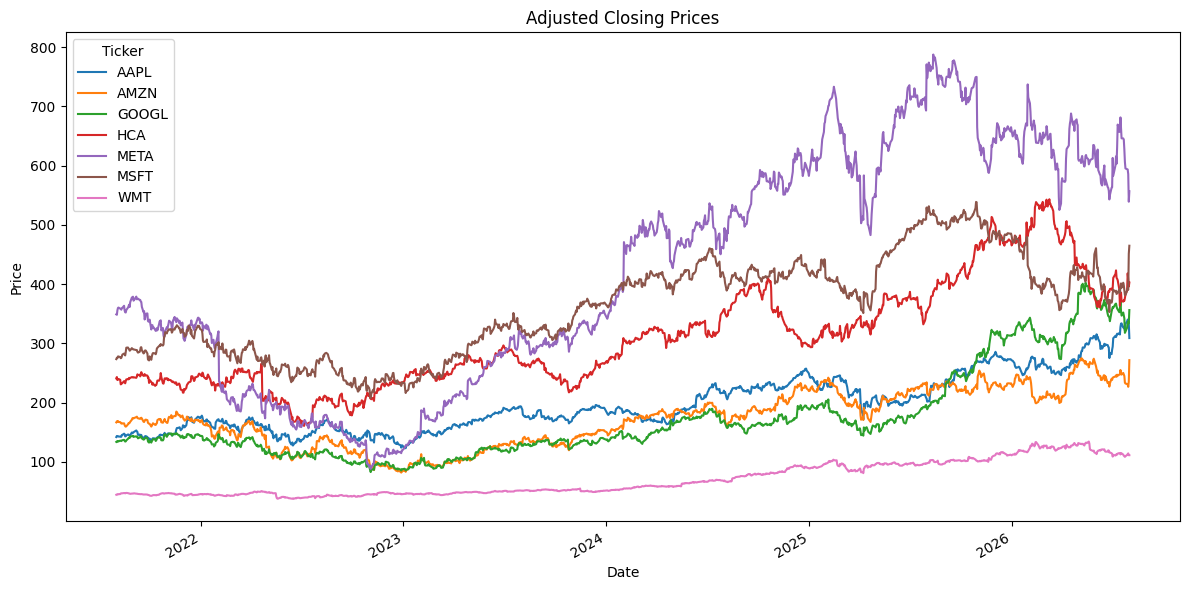

In [4]:
from options_risk_engine.data.market_data import (
    download_historical_market_data,
    equity_prices_to_long,
    fetch_dividend_yields,
)
from options_risk_engine.reporting.plots import plot_price_history

close_data = download_historical_market_data(
    CONFIG.symbols,
    period=CONFIG.history_period,
    interval=CONFIG.history_interval,
)
dividend_yields = fetch_dividend_yields(tickers)

latest_prices = close_data["Close"].tail().round(2)
print("Historical rows:", len(close_data))
print("Missing close observations:", int(close_data.isna().sum().sum()))
display(latest_prices)
plot_price_history(close_data, FIGURE_DIR / "01_price_history.png")
plt.show()

### Historical-data observations

The download produced 1,255 daily observations for each of the seven
underlyings, with no missing adjusted-close values in the aligned dataset.
This provides approximately five years of common history.

The price chart shows substantial differences in both price level and
long-term path between the companies. Raw prices are therefore not used
directly as comparable forecasting features. Percentage returns and
annualised volatility measures are created in the next stage.

The final dates also contain several large one-day movements. These recent
observations will have a stronger effect on short-window realised volatility
than on the longer 252-day measure.

### Persisting the historical price snapshot

The wide market-data table is converted into a long relational format with
one row per date and ticker. This format is easier to query in SQL and avoids
creating a separate database column for every underlying.

In [5]:
equity_prices_long = equity_prices_to_long(close_data)
store.write_frame(equity_prices_long, "equity_prices", run_id=run_id)
display(equity_prices_long.tail(10))

2026-08-02 13:36:38,954 - options_risk_engine.database - INFO - Stored 8785 rows in equity_prices


,date,ticker,close
8775,2026-07-30,META,539.030029
8776,2026-07-30,MSFT,451.100006
8777,2026-07-30,WMT,111.099998
8778,2026-07-31,AAPL,308.910004
8779,2026-07-31,AMZN,271.579987
8780,2026-07-31,GOOGL,356.130005
8781,2026-07-31,HCA,402.589996
8782,2026-07-31,META,556.710022
8783,2026-07-31,MSFT,464.720001
8784,2026-07-31,WMT,111.199997


## 5. Return, realised-volatility and forecasting features

The feature-engineering stage converts adjusted prices into daily returns and
creates rolling measures intended to describe the recent level, persistence
and change in volatility.

The features include realised volatility over short, medium and long windows,
lagged returns and volatility-related transformations. The target is future
annualised realised volatility over the same trading horizon used for the
target option maturity.

Because the target uses future observations, its construction naturally
creates missing values at the end of the dataset. These are expected and must
not be filled using future information.

In [6]:
from options_risk_engine.data.market_data import build_volatility_feature_dataset

feature_data, returns, feature_columns = build_volatility_feature_dataset(
    close_data=close_data,
    tickers=tickers,
)

feature_summary = pd.DataFrame({
    "Rows": [len(feature_data)],
    "Columns": [feature_data.shape[1]],
    "Features per ticker": [len(feature_columns)],
    "Start": [feature_data.index.min()],
    "End": [feature_data.index.max()],
})
display(feature_summary)
display(feature_data.tail(5))

2026-08-02 13:36:38,999 - options_risk_engine.data.market_data - INFO - Feature dataset created: 1255 rows, 21 engineered features per ticker


,Rows,Columns,Features per ticker,Start,End
0,1255,168,21,2021-08-02,2026-07-31


Price            Close                                                                            Return                                                                  RV20  \
Ticker            AAPL        AMZN       GOOGL         HCA        META        MSFT         WMT      AAPL      AMZN     GOOGL       HCA      META      MSFT       WMT      AAPL   
Date                                                                                                                                                                             
2026-07-27  336.910004  231.389999  326.559998  389.619995  593.869995  389.100006  111.739998  0.011681 -0.003102  0.021330  0.019441 -0.002218  0.019387  0.020736  0.290070   
2026-07-28  340.079987  230.860001  333.709991  418.190002  593.409973  393.350006  113.099998  0.009409 -0.002290  0.021895  0.073328 -0.000775  0.010923  0.012171  0.283872   
2026-07-29  338.190002  226.649994  336.709991  408.179993  585.609985  390.540009  114.220001 -0.005557 -0.018236  0.008990 -0.023937 -0.013144 -0.007144  0.009903  0.280877   
2026-07-30  333.429993  235.500000  333.660004  395.790009  539.030029  451.100006  111.099998 -0.014075  0.039047 -0.009058 -0.030354 -0.079541  0.155067 -0.027316  0.288997   
2026-07-31  308.910004  271.579987  356.130005  402.589996  556.710022  464.720001  111.199997 -0.073539  0.153206  0.067344  0.017181  0.032800  0.030193  0.000900  0.367445   

Price                                                                       RV60                                                                 RV252                      \
Ticker          AMZN     GOOGL       HCA      META      MSFT       WMT      AAPL      AMZN     GOOGL       HCA      META      MSFT       WMT      AAPL      AMZN     GOOGL   
Date                                                                                                                                                                         
2026-07-27  0.274746  0.421155  0.432712  0.550608  0.264445  0.261835  0.288103  0.293979  0.396262  0.332552  0.456825  0.339632  0.277361  0.247826  0.314238  0.314066   
2026-07-28  0.247090  0.389314  0.504909  0.546660  0.260708  0.264491  0.288325  0.293291  0.340146  0.366279  0.422005  0.331050  0.270564  0.247935  0.314228  0.314663   
2026-07-29  0.253209  0.388667  0.513361  0.549727  0.261139  0.263505  0.282770  0.293599  0.340793  0.369425  0.422727  0.329489  0.271733  0.248046  0.314715  0.314683   
2026-07-30  0.287871  0.385941  0.525984  0.525059  0.597206  0.242240  0.283324  0.303936  0.340987  0.373492  0.452777  0.458794  0.276182  0.248114  0.317018  0.314575   
2026-07-31  0.619458  0.460980  0.505122  0.516213  0.601601  0.220942  0.320077  0.440170  0.368249  0.375226  0.457960  0.462168  0.275991  0.259057  0.351950  0.321222   

Price                                              AbsReturn                                                             SquaredReturn                                \
Ticker           HCA      META      MSFT       WMT      AAPL      AMZN     GOOGL       HCA      META      MSFT       WMT          AAPL      AMZN     GOOGL       HCA   
Date                                                                                                                                                                   
2026-07-27  0.292797  0.389056  0.276660  0.246076  0.011681  0.003102  0.021330  0.019441  0.002218  0.019387  0.020736      0.000136  0.000010  0.000455  0.000378   
2026-07-28  0.300857  0.389047  0.276838  0.246203  0.009409  0.002290  0.021895  0.073328  0.000775  0.010923  0.012171      0.000089  0.000005  0.000479  0.005377   
2026-07-29  0.301379  0.389184  0.276905  0.246373  0.005557  0.018236  0.008990  0.023937  0.013144  0.007144  0.009903      0.000031  0.000333  0.000081  0.000573   
2026-07-30  0.302803  0.396414  0.317805  0.247878  0.014075  0.039047  0.009058  0.030354  0.079541  0.155067  0.027316      0.000198  0.001525  0.000082  0.000921   
2026-0

### Feature-dataset observations

The resulting dataset contains 1,255 dates and 21 engineered features for each
ticker. The wide matrix contains 168 columns once the price, return, features
and target variables are included across all seven underlyings.

The final `Target_RV` observations are missing because the future
32-trading-day window has not yet occurred. This is a consequence of defining
a forward-looking target and is not a data-quality error.

The forecasting functions later remove rows without complete features and
targets before fitting each model.

### Short- and long-horizon realised volatility

Realised volatility is inspected over 20, 60 and 252 trading days. Comparing
multiple windows helps distinguish short-lived market shocks from persistent
changes in the underlying volatility regime.

The 20-day series reacts fastest to recent returns, whereas the 252-day series
is smoother and represents the longer-run volatility environment.

Price,RV20,RV60,RV252,Target_RV
Date,,,,
2026-07-20,0.3759,0.2812,0.2450,NaN
2026-07-21,0.3747,0.2812,0.2450,NaN
2026-07-22,0.3731,0.2807,0.2451,NaN
2026-07-23,0.3774,0.2807,0.2454,NaN
2026-07-24,0.3009,0.2879,0.2477,NaN
2026-07-27,0.2901,0.2881,0.2478,NaN
2026-07-28,0.2839,0.2883,0.2479,NaN
2026-07-29,0.2809,0.2828,0.2480,NaN
2026-07-30,0.2890,0.2833,0.2481,NaN


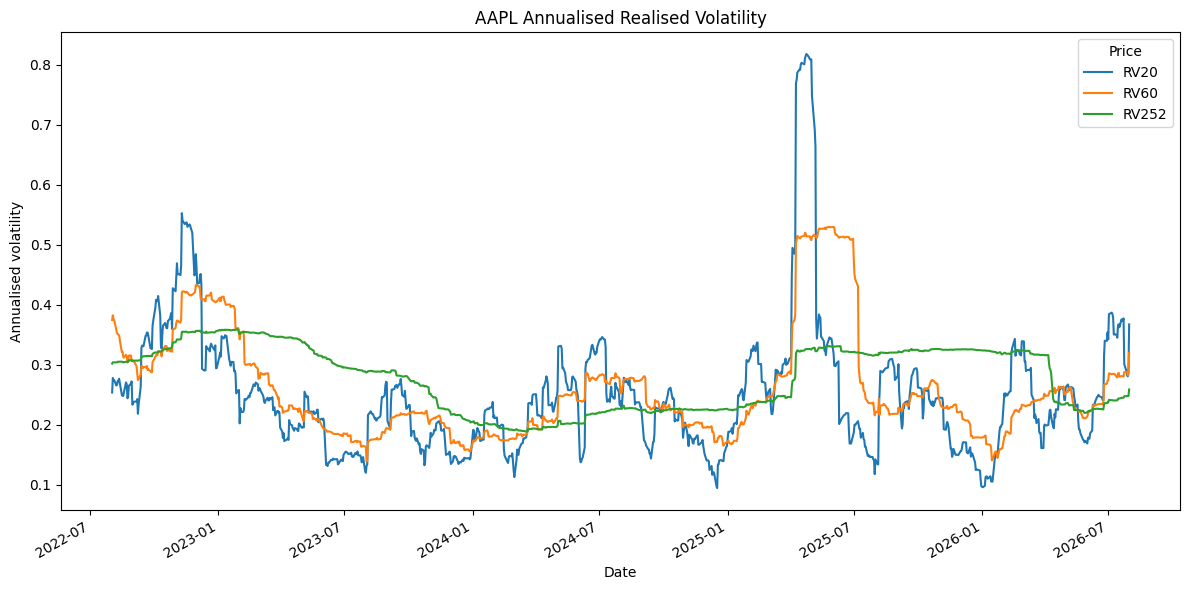

In [7]:
from options_risk_engine.reporting.plots import plot_realised_volatility

example_ticker = CONFIG.symbols[0]
latest_volatility = feature_data.xs(example_ticker, axis=1, level="Ticker")[[
    "RV20", "RV60", "RV252", "Target_RV"
]].tail(10)
display(latest_volatility.round(4))
plot_realised_volatility(
    feature_data, example_ticker, FIGURE_DIR / "02_realised_volatility.png"
)
plt.show()

For AAPL, the final 20-day realised volatility is approximately 36.7%, compared
with 32.0% over 60 days and 25.9% over 252 days. The ordering indicates that
recent price movements were more volatile than the longer-run history.

The graph also shows that short-window volatility can change rapidly and
produce temporary spikes, while long-window volatility adjusts slowly. This
supports testing models that combine several horizons, such as HAR-RV, while
also demonstrating why a single recent volatility number may be unstable.

### Persisting the feature matrix

The complete feature matrix is stored so that the exact forecasting inputs can
be recovered without repeating the market-data download. MultiIndex column
names are flattened before insertion into SQLite.

SQLite is suitable for this project-sized snapshot. Parquet would be a better
choice if the feature universe expanded to hundreds of assets or intraday
observations.

In [8]:
feature_snapshot = feature_data.copy()
feature_snapshot.columns = [f"{a}__{b}" for a, b in feature_snapshot.columns]
feature_snapshot = feature_snapshot.reset_index().rename(columns={"Date": "date", "index": "date"})
store.write_frame(feature_snapshot, "volatility_features", run_id=run_id)
print("Stored feature rows:", len(feature_snapshot))

2026-08-02 13:36:39,511 - options_risk_engine.database - INFO - Stored 1255 rows in volatility_features


Stored feature rows: 1255


## 6. Volatility forecast benchmark

The forecasting experiment asks whether engineered historical features can
predict future realised volatility more accurately than simple benchmark
forecasts.

Thirty-four configurations are tested, including:

- a training-mean forecast;
- the current 20-day realised-volatility baseline;
- ordinary least squares;
- Ridge and Lasso across several regularisation strengths;
- PCA versions of the linear models;
- Random Forest and Gradient Boosting;
- HAR-RV; and
- GARCH(1,1).

Performance is measured using purged walk-forward validation. For every fold,
the model is trained only on observations that occur before the test block,
and a purge equal to the forecast horizon is placed between training and test
data. This prevents the forward realised-volatility target in the training set
from overlapping the test period.

Scaling and PCA are fitted using the training fold only. This avoids allowing
information from the future test block to influence feature transformations.

In [9]:
from options_risk_engine.forecasting.volatility import (
    evaluate_historical_mean_holdout,
    evaluate_symbol_models,
)

comparison_tables = {}
mean_holdout_tables = {}

if CONFIG.run_forecast_benchmarks:
    for ticker in tickers:
        ticker_df = feature_data.xs(ticker.symbol, axis=1, level="Ticker").copy()
        mean_holdout_tables[ticker.symbol] = evaluate_historical_mean_holdout(
            ticker_df=ticker_df,
            ticker=ticker,
            test_fraction=FORECAST_TEST_FRACTION,
        )
        comparison_tables[ticker.symbol] = evaluate_symbol_models(
            ticker_df=ticker_df,
            feature_cols=feature_columns,
            ticker=ticker,
        )

    model_comparison = pd.concat(
        [table.assign(Ticker=ticker) for ticker, table in comparison_tables.items()],
        ignore_index=True,
    )
    store.write_frame(model_comparison, "model_evaluations", run_id=run_id)
    display(model_comparison.groupby("Ticker").head(5))
else:
    print("Forecast benchmarks skipped. Set CONFIG.run_forecast_benchmarks=True for the full run.")

2026-08-02 13:36:41,175 - options_risk_engine.forecasting.volatility - INFO - AAPL starting model evaluation
2026-08-02 13:36:41,177 - options_risk_engine.forecasting.volatility - INFO - AAPL has 971 usable rows and 21 features
2026-08-02 13:36:41,178 - options_risk_engine.forecasting.volatility - INFO - Creating model specifications
2026-08-02 13:36:41,178 - options_risk_engine.forecasting.volatility - INFO - Created 34 model configurations
2026-08-02 13:36:41,179 - options_risk_engine.forecasting.volatility - INFO - AAPL walk-forward starts at row 284 with window=30, step=30, purge=32
2026-08-02 13:36:57,517 - options_risk_engine.forecasting.volatility - INFO - AAPL completed 22 walk-forward folds
2026-08-02 13:36:57,518 - options_risk_engine.forecasting.volatility - INFO - AAPL calculating model comparison metrics
2026-08-02 13:36:57,520 - options_risk_engine.forecasting.volatility - INFO - AAPL Train Mean           alpha=None RMSE=0.10960 NRMSE=1.04761 R2=-0.09748 IC=-0.48458
2026-

,Model,Alpha,RMSE,MAE,R2,NRMSE,IC,N,Ticker
0,Lasso PCA,0.10,0.105615,0.064111,-0.019185,1.009547,0.056935,660,AAPL
1,Train Mean,NaN,0.109597,0.068618,-0.097480,1.047607,-0.484583,660,AAPL
2,Lasso PCA,1.00,0.109597,0.068618,-0.097480,1.047607,-0.484583,660,AAPL
3,Lasso,1.00,0.109597,0.068618,-0.097480,1.047607,-0.484583,660,AAPL
4,Lasso,0.10,0.109597,0.068618,-0.097480,1.047607,-0.484583,660,AAPL
34,GARCH,NaN,0.083249,0.063023,-0.239032,1.113118,0.043152,660,MSFT
35,Ridge,1000.00,0.084167,0.062990,-0.266511,1.125394,-0.033607,660,MSFT
36,Ridge PCA,1000.00,0.084220,0.063059,-0.268093,1.126096,-0.039650,660,MSFT
37,Lasso PCA,0.10,0.086249,0.072394,-0.329943,1.153232,-0.290325,660,MSFT
38,Lasso,0.01,0.086951,0.064767,-0.351695,1.162624,-0.115842,660,MSFT


The model universe includes both simple statistical benchmarks and more
flexible machine-learning or volatility-specific approaches. Testing the
simpler models is important: a complex model should only be selected if it
provides a genuine out-of-sample improvement rather than simply fitting the
historical sample more closely.

## 7. Live option-chain acquisition

For each underlying, the listed expiry closest to the 45-day target is
downloaded. Both calls and puts are retained so that the pricing model can be
evaluated across strikes and validated using put-call parity.

Option-chain data is a live and imperfect market snapshot. Bid, ask, volume,
open interest and last-trade timestamps are therefore retained rather than
using only the implied volatility supplied by the data provider.

In [10]:
from options_risk_engine.pricing.chains import download_option_chains

download_option_chains(tickers)
chain_inventory = pd.DataFrame({
    "Ticker": [ticker.symbol for ticker in tickers],
    "Expiry": [ticker.expiry for ticker in tickers],
    "Calls": [0 if ticker.call_chain is None else len(ticker.call_chain) for ticker in tickers],
    "Puts": [0 if ticker.put_chain is None else len(ticker.put_chain) for ticker in tickers],
})
display(chain_inventory)

2026-08-02 13:38:36,105 - options_risk_engine.pricing.chains - INFO - Downloading option chains for 7 ticker objects
2026-08-02 13:38:36,106 - options_risk_engine.pricing.chains - INFO - Downloading option chain for AAPL nearest to 2026-09-16
2026-08-02 13:38:36,362 - options_risk_engine.pricing.chains - INFO - AAPL chain loaded for 2026-09-18: 93 calls and 74 puts
2026-08-02 13:38:36,362 - options_risk_engine.pricing.chains - INFO - Downloading option chain for MSFT nearest to 2026-09-16
2026-08-02 13:38:36,606 - options_risk_engine.pricing.chains - INFO - MSFT chain loaded for 2026-09-18: 90 calls and 82 puts
2026-08-02 13:38:36,607 - options_risk_engine.pricing.chains - INFO - Downloading option chain for META nearest to 2026-09-16
2026-08-02 13:38:36,821 - options_risk_engine.pricing.chains - INFO - META chain loaded for 2026-09-18: 190 calls and 146 puts
2026-08-02 13:38:36,822 - options_risk_engine.pricing.chains - INFO - Downloading option chain for WMT nearest to 2026-09-16
202

,Ticker,Expiry,Calls,Puts
0,AAPL,2026-09-18,93,74
1,MSFT,2026-09-18,90,82
2,META,2026-09-18,190,146
3,WMT,2026-09-18,34,28
4,GOOGL,2026-09-18,134,98
5,AMZN,2026-09-18,58,52
6,HCA,2026-09-18,73,59


All seven option chains were retrieved successfully, and each selected the
18 September 2026 expiry. The number of available contracts varied
substantially: META provided the deepest chain, while WMT had the smallest
number of strikes.

This difference matters because the quantity and quality of available
contracts affect both the breadth of the pricing comparison and the number of
positions later entering the synthetic portfolio.

### Preserving the original market snapshot

The unmodified option-chain rows are stored before pricing and filtering. This
makes it possible to distinguish values downloaded from the market-data source
from columns created later by the project.

A snapshot timestamp, ticker, option type and expiry are added to each row so
that the source data can be reconstructed independently of the priced table.

In [11]:
raw_chain_frames = []
for ticker in tickers:
    for option_type, chain in (("Calls", ticker.call_chain), ("Puts", ticker.put_chain)):
        if chain is None:
            continue
        snapshot = chain.copy().assign(
            ticker=ticker.symbol,
            option_type=option_type,
            expiry=ticker.expiry,
            snapshot_time=pd.Timestamp.utcnow(),
        )
        raw_chain_frames.append(snapshot)

raw_option_chains = pd.concat(raw_chain_frames, ignore_index=True)
store.write_frame(raw_option_chains, "option_chain_snapshots_full", run_id=run_id)
display(raw_option_chains.head())

2026-08-02 13:38:37,592 - options_risk_engine.database - INFO - Stored 1211 rows in option_chain_snapshots_full


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,ticker,option_type,expiry,snapshot_time
0,AAPL260918C00050000,2026-07-31 13:54:56+00:00,50.0,254.65,257.15,261.00,-27.75,-9.826488,1.0,27.0,1.998047,True,REGULAR,USD,AAPL,Calls,2026-09-18,2026-08-02 12:38:37.566293+00:00
1,AAPL260918C00055000,2026-07-06 15:44:35+00:00,55.0,259.24,252.30,256.10,0.00,0.000000,1.0,40.0,2.027349,True,REGULAR,USD,AAPL,Calls,2026-09-18,2026-08-02 12:38:37.566293+00:00
2,AAPL260918C00060000,2026-07-01 14:26:11+00:00,60.0,232.92,247.35,251.00,0.00,0.000000,2.0,2.0,1.904297,True,REGULAR,USD,AAPL,Calls,2026-09-18,2026-08-02 12:38:37.566293+00:00
3,AAPL260918C00065000,2025-08-25 18:54:43+00:00,65.0,164.78,191.15,193.95,0.00,0.000000,1.0,1.0,NaN,True,REGULAR,USD,AAPL,Calls,2026-09-18,2026-08-02 12:38:37.566293+00:00
4,AAPL260918C00070000,2026-07-07 13:30:27+00:00,70.0,245.00,237.40,241.15,0.00,0.000000,1.0,3.0,1.800782,True,REGULAR,USD,AAPL,Calls,2026-09-18,2026-08-02 12:38:37.566293+00:00


## 8. Option pricing and contract-level validation

Each option is valued using the Black–Scholes model under several volatility
assumptions, including downloaded implied volatility, calculated midpoint
implied volatility, realised-volatility measures and the selected forecast
volatility.

The stage also:

- calculates market midpoint and bid–ask spread;
- checks theoretical option-price bounds;
- solves for bid, midpoint and ask implied volatility;
- calculates analytical Greeks;
- checks put-call parity;
- evaluates quote quality and liquidity; and
- assigns a screening label based on model-implied edge.

The purpose is not merely to generate a theoretical price. It is to establish
whether the market data and numerical implementation are sufficiently reliable
for the later portfolio risk calculations.

In [12]:
from options_risk_engine.pricing.chains import (
    filter_highlighted_options,
    price_option_universe,
)
from options_risk_engine.reporting.tables import combine_option_tables
from options_risk_engine.validation import validate_option_universe

cleaned_options, _, parity_results = price_option_universe(
    tickers=tickers,
    data=feature_data,
)

highlighted_options = {
    key: filter_highlighted_options(
        options=frame,
        buy_edge=INITIAL_BUY_EDGE,
        max_spread_pct=INITIAL_MAX_SPREAD_PCT,
        min_ask=INITIAL_MIN_ASK,
        min_open_interest=INITIAL_MIN_OPEN_INTEREST,
        min_volume=INITIAL_MIN_VOLUME,
        min_moneyness=INITIAL_MIN_MONEYNESS,
        max_moneyness=INITIAL_MAX_MONEYNESS,
    )
    for key, frame in cleaned_options.items()
}

large_table = combine_option_tables(
    cleaned_options
)

universe_validation = validate_option_universe(
    large_table
)

print(universe_validation)
display(large_table.head(10))

2026-08-02 13:38:37,610 - options_risk_engine.pricing.chains - INFO - Starting option pricing for 7 ticker objects
2026-08-02 13:38:37,610 - options_risk_engine.pricing.chains - INFO - AAPL beginning option-chain pricing
2026-08-02 13:38:37,612 - options_risk_engine.pricing.chains - INFO - AAPL volatility inputs - RV20: 0.3674, RV60: 0.3201, RV252: 0.2591, forecast: 0.2623
2026-08-02 13:38:38,281 - options_risk_engine.pricing.chains - INFO - AAPL implied volatility calculations complete
2026-08-02 13:38:38,286 - options_risk_engine.pricing.chains - INFO - AAPL put-call parity check: 74 matched strikes, maximum absolute error 0.0000000000
2026-08-02 13:38:38,316 - options_risk_engine.pricing.chains - INFO - AAPL pricing complete — 93 total calls, 74 total puts, 0 highlighted calls and 7 highlighted puts
2026-08-02 13:38:38,316 - options_risk_engine.pricing.chains - INFO - MSFT beginning option-chain pricing
2026-08-02 13:38:38,320 - options_risk_engine.pricing.chains - INFO - MSFT volat

{'rows': 1211, 'tickers': 7, 'duplicate_contract_symbols': 0, 'invalid_quotes': 417}


,contractSymbol,strike,bid,ask,lastPrice,lastTradeDate,impliedVolatility,volume,openInterest,Current Stock Price,Expiry,MarketMid,IV Used,BS_IV,BS_IV - Mid,BS_IV MidEdge,BS_IV - Ask,BS_IV AskEdge,BS_IV - Bid,BS_IV BidEdge,RV20 Used,BS_RV20,BS_RV20 - Mid,BS_RV20 MidEdge,BS_RV20 - Ask,BS_RV20 AskEdge,BS_RV20 - Bid,BS_RV20 BidEdge,RV60 Used,BS_RV60,BS_RV60 - Mid,BS_RV60 MidEdge,BS_RV60 - Ask,BS_RV60 AskEdge,BS_RV60 - Bid,BS_RV60 BidEdge,RV252 Used,BS_RV252,BS_RV252 - Mid,BS_RV252 MidEdge,BS_RV252 - Ask,BS_RV252 AskEdge,BS_RV252 - Bid,BS_RV252 BidEdge,ForeV Used,BS_ForeV,BS_ForeV - Mid,BS_ForeV MidEdge,BS_ForeV - Ask,BS_ForeV AskEdge,BS_ForeV - Bid,BS_ForeV BidEdge,IV_Bid,IV_Mid,IV_Ask,IV Bid-Ask Spread,IV Mid - Yahoo IV,IV Order Valid,BS_From_IV_Mid,IV_Repricing_Error,IV_Repricing_Valid,Greek Volatility,Greek Volatility Source,Delta,Gamma,Vega,Theta,Rho,Greek Signs Valid,Greek Sign Issue,Parity Error,Absolute Parity Error,Parity Valid,Ticker,Option_Type,Calendar DTE,Trading DTE,Forecast Horizon,Horizon Difference,Horizon Aligned,Time to Expiry,Risk-Free Rate,Dividend Yield,Forward Price,Forward Moneyness,Volatility Spread,Moneyness,SpreadPct,Maximum Buy Price,Ask Below Maximum,Intrinsic Value,Lower Price Bound,Upper Price Bound,Break-Even Price,Time Value,Distance Above Lower Bound,Distance Below Upper Bound,Pricing Bounds Valid,Quote Age Days,Quote Valid,Quote Issue,Recommendation Eligible,Initial Recommended Action,Option_Table
0,AAPL260918C00050000,50.0,257.15,261.00,254.65,2026-07-31 13:54:56+00:00,1.998047,1.0,27.0,308.910004,2026-09-18,259.075,1.998047,245.711468,-13.363532,-0.051582,-15.288532,-0.058577,-11.438532,-0.044482,0.367445,245.537815,-13.537185,-0.052252,-15.462185,-0.059242,-11.612185,-0.045157,0.320077,245.537815,-13.537185,-0.052252,-15.462185,-0.059242,-11.612185,-0.045157,0.259057,245.537815,-13.537185,-0.052252,-15.462185,-0.059242,-11.612185,-0.045157,0.262272,245.537815,-13.537185,-0.052252,-15.462185,-0.059242,-11.612185,-0.045157,4.616063,4.891423,NaN,NaN,2.893376,False,259.074991,-8.781867e-06,True,4.891423,Calculated Mid IV,0.927986,1.174113e-04,7.056901e-02,-0.095167,0.035526,True,,0.0,0.0,True,AAPL,Calls,47,34,32,2,True,0.128767,0.0375,0.35,296.726328,0.168505,-1.735775,0.161859,0.014861,233.845539,False,258.910004,245.537815,295.296959,311.00,0.164996,13.537185,36.221959,True,2,True,,True,Do Not Buy,AAPL Calls
1,AAPL260918C00055000,55.0,252.30,256.10,259.24,2026-07-06 15:44:35+00:00,2.027349,1.0,40.0,308.910004,2026-09-18,254.200,2.027349,240.867299,-13.332701,-0.052450,-15.232701,-0.059480,-11.432701,-0.045314,0.367445,240.561901,-13.638099,-0.053651,-15.538099,-0.060672,-11.738099,-0.046524,0.320077,240.561901,-13.638099,-0.053651,-15.538099,-0.060672,-11.738099,-0.046524,0.259057,240.561901,-13.638099,-0.053651,-15.538099,-0.060672,-11.738099,-0.046524,0.262272,240.561901,-13.638099,-0.053651,-15.538099,-0.060672,-11.738099,-0.046524,4.361920,4.611713,4.856772,0.494853,2.584364,True,254.200000,7.004039e-08,True,4.611713,Calculated Mid IV,0.924911,1.357752e-04,7.693992e-02,-0.106738,0.040580,True,,0.0,0.0,True,AAPL,Calls,47,34,32,2,True,0.128767,0.0375,0.35,296.726328,0.185356,-1.765077,0.178045,0.014949,229.106572,False,253.910004,240.561901,295.296959,311.10,0.289996,13.638099,41.096959,True,27,True,,True,Do Not Buy,AAPL Calls
2,AAPL260918C00060000,60.0,247.35,251.00,232.92,2026-07-01 14:26:11+00:00,1.904297,2.0,2.0,308.910004,2026-09-18,249.175,1.904297,235.868206,-13.306794,-0.053403,-15.131794,-0.060286,-11.481794,-0.046419,0.367445,235.585987,-13.589013,-0.054536,-15.414013,-0.061410,-11.764013,-0.047560,0.320077,235.585987,-13.589013,-0.054536,-15.414013,-0.061410,-11.764013,-0.047560,0.259057,235.585987,-13.589013,-0.054536,-15.414013,-0.061410,-11.764013,-0.047560,0.262272,235.585987,-13.589013,-0.054536,-15.414013,-0.061410,-11.764013,-0.047560,4.125195,4.348040,4.565918,0.440723,2.443743,True,249.175003,3.236614e-06,True,4.348040,Calculated Mid IV,0.921932,1.552880e-04,8.296605e-02,-0.

### Option-universe quality

The final universe contains 1,211 unique contracts across all seven tickers,
with no duplicated contract symbols. The engine flagged 417 rows as having an
invalid quote under its price-bound and bid–ask criteria.

This is approximately one third of the downloaded universe, demonstrating why
a live option chain should not be passed directly into a pricing or trading
workflow without validation.

Quote quality also differed between calls and puts. Several call chains
contained a high proportion of usable quotes, while the HCA and WMT put chains
contained relatively few valid observations. These rows remain useful for
diagnosing data quality but should not be treated as reliable trade candidates.

In [13]:
pricing_summary = (
    large_table.groupby(["Ticker", "Option_Type"], observed=True)
    .agg(
        Contracts=("contractSymbol", "size"),
        Valid_Quotes=("Quote Valid", "sum"),
        Median_Spread=("SpreadPct", "median"),
        Median_IV=("IV_Mid", "median"),
        Median_Forecast_Vol=("ForeV Used", "median"),
        Median_Ask_Edge=("BS_ForeV AskEdge", "median"),
    )
    .reset_index()
)
display(pricing_summary.round(4))

,Ticker,Option_Type,Contracts,Valid_Quotes,Median_Spread,Median_IV,Median_Forecast_Vol,Median_Ask_Edge
0,AAPL,Calls,93,77,0.0530,0.7484,0.2623,-0.4276
1,AAPL,Puts,74,30,0.1111,0.3490,0.2623,-0.8675
2,AMZN,Calls,58,56,0.0391,0.3577,0.3413,-0.0147
3,AMZN,Puts,52,43,0.0723,0.4085,0.3413,-0.3885
4,GOOGL,Calls,134,114,0.0408,0.5928,0.3099,-0.3978
5,GOOGL,Puts,98,38,0.0662,0.3696,0.3099,-0.7827
6,HCA,Calls,73,49,0.0801,0.7478,0.2788,-0.9213
7,HCA,Puts,59,12,0.0904,0.1972,0.2788,0.4429
8,META,Calls,190,157,0.1322,0.5966,0.4131,-0.8204
9,META,Puts,146,58,0.0535,0.3771,0.4131,0.1404


### Put-call parity

Put-call parity provides an internal consistency check for European call and
put prices with the same strike and expiry.

The comparison here uses prices generated by the same forecast-volatility
model. It therefore tests whether the implemented call and put formulas,
discounting and dividend treatment satisfy the required relationship. It is
not intended to identify market arbitrage from executable bid and ask quotes.

In [14]:
parity_summary = pd.DataFrame([
    {
        "Ticker": ticker,
        "Matched Strikes": len(table),
        "Maximum Absolute Error": table["Absolute Parity Error"].max() if not table.empty else np.nan,
        "Failed": (~table["Within Tolerance"]).sum() if not table.empty else 0,
    }
    for ticker, table in parity_results.items()
])
display(parity_summary)

,Ticker,Matched Strikes,Maximum Absolute Error,Failed
0,AAPL,74,5.684342e-14,0
1,MSFT,82,1.136868e-13,0
2,META,130,1.421085e-13,0
3,WMT,28,1.421085e-14,0
4,GOOGL,96,7.105427e-14,0
5,AMZN,52,5.684342e-14,0
6,HCA,56,8.526513e-14,0


All matched strikes passed the parity tolerance. Maximum errors were on the
order of \(10^{-13}\), which is consistent with floating-point rounding rather
than an economically meaningful discrepancy.

This provides strong evidence that the call and put pricing formulas use
consistent spot, strike, rate, dividend and maturity inputs.

### Market price versus forecast-based model price

The scatter plot compares the option-market midpoint with the
Black–Scholes value obtained using forecast realised volatility.

The diagonal line represents exact agreement. Points above the line are valued
more highly by the forecast-volatility model than by the market midpoint,
while points below the line have a lower model value.

Differences can arise from genuine disagreement about future volatility, but
also from the volatility smile, skew, stale quotations, wide spreads and the
fact that one forecast-volatility value is currently used across all strikes
for an underlying.

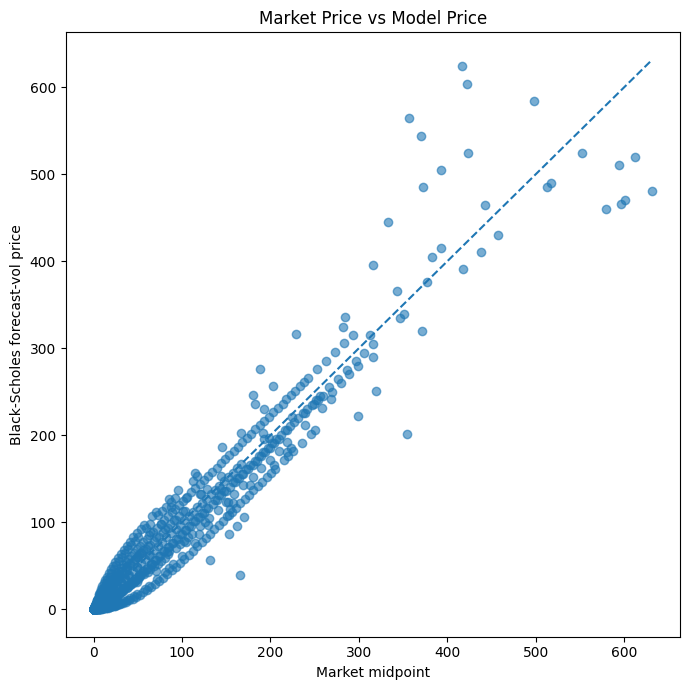

,Ticker,Option_Type,contractSymbol,strike,MarketMid,BS_ForeV,BS_ForeV AskEdge,IV_Mid,Greek Volatility,Initial Recommended Action
0,AAPL,Calls,AAPL260918C00050000,50.0,259.075,245.5378,-0.0592,4.8914,4.8914,Do Not Buy
1,AAPL,Calls,AAPL260918C00055000,55.0,254.200,240.5619,-0.0607,4.6117,4.6117,Do Not Buy
2,AAPL,Calls,AAPL260918C00060000,60.0,249.175,235.5860,-0.0614,4.3480,4.3480,Do Not Buy
3,AAPL,Calls,AAPL260918C00065000,65.0,192.550,230.6101,0.1890,NaN,0.2623,Invalid Quote
4,AAPL,Calls,AAPL260918C00070000,70.0,239.275,225.6342,-0.0643,3.9189,3.9189,Do Not Buy
5,AAPL,Calls,AAPL260918C00075000,75.0,224.050,220.6582,-0.0232,2.5048,2.5048,Do Not Buy
6,AAPL,Calls,AAPL260918C00080000,80.0,NaN,215.6823,NaN,NaN,0.2623,No Data
7,AAPL,Calls,AAPL260918C00085000,85.0,NaN,210.7064,NaN,NaN,0.2623,No Data
8,AAPL,Calls,AAPL260918C00090000,90.0,219.275,205.7305,-0.0693,3.2474,3.2474,Do Not Buy
9,AAPL,Calls,AAPL260918C00095000,95.0,NaN,200.7546,NaN,NaN,0.2623,No Data


In [15]:
from options_risk_engine.reporting.plots import plot_market_vs_model

plot_market_vs_model(large_table, FIGURE_DIR / "03_market_vs_model.png")
plt.show()

display(large_table[[
    "Ticker", "Option_Type", "contractSymbol", "strike", "MarketMid",
    "BS_ForeV", "BS_ForeV AskEdge", "IV_Mid", "Greek Volatility",
    "Initial Recommended Action",
]].head(20).round(4))

The model and market values have a clear positive relationship, confirming
that strike, spot and maturity are being reflected sensibly. However, the
dispersion increases for some high-value contracts and several observations
sit well away from the equality line.

This is expected because the market does not price all strikes using one
constant volatility. The difference between forecast and market price should
therefore be interpreted as a screening signal that requires liquidity and
quote-quality checks, rather than proof that the market is incorrectly priced.

### Analytical Greeks versus finite differences

The analytical Delta, Gamma, Vega, Theta and Rho calculations are checked
against numerical finite-difference approximations.

This is an important implementation test because a pricing formula can appear
reasonable while one or more derivative formulas contain a sign, scale or
unit error. The numerical values are calculated from small changes in the
relevant Black–Scholes input and compared using Greek-specific tolerances.

In [16]:
from options_risk_engine.pricing.greeks import add_numerical_greek_validation

sample_validations = []
for ticker in tickers:
    for option_type, key in (("call", ticker.table_key("Calls")), ("put", ticker.table_key("Puts"))):
        sample = cleaned_options[key].dropna(subset=["Greek Volatility"]).head(5)
        if not sample.empty:
            checked = add_numerical_greek_validation(sample, ticker, option_type)
            sample_validations.append(checked.assign(Ticker=ticker.symbol, Option_Type=option_type))

greek_validation_sample = pd.concat(sample_validations, ignore_index=True)
validation_columns = [column for column in greek_validation_sample.columns if "Validation" in column or column in ["Ticker", "Option_Type", "contractSymbol"]]
display(greek_validation_sample[validation_columns])

,contractSymbol,Ticker,Option_Type,Delta Validation Passed,Gamma Validation Passed,Vega Validation Passed,Theta Validation Passed,Rho Validation Passed
0,AAPL260918C00050000,AAPL,call,True,True,True,True,True
1,AAPL260918C00055000,AAPL,call,True,True,True,True,True
2,AAPL260918C00060000,AAPL,call,True,True,True,True,True
3,AAPL260918C00065000,AAPL,call,True,True,True,True,True
4,AAPL260918C00070000,AAPL,call,True,True,True,True,True
...,...,...,...,...,...,...,...,...
65,HCA260918P00200000,HCA,put,True,True,True,True,True
66,HCA260918P00220000,HCA,put,True,True,True,True,True
67,HCA260918P00250000,HCA,put,True,True,True,True,True
68,HCA260918P00260000,HCA,put,True,True,True,True,True


The representative sample contains calls and puts from every ticker. The
displayed validation flags pass for the tested Greeks across all 70 sample
contracts.

This supports the accuracy of both the analytical formulas and their unit
conventions, including Vega and Rho per percentage-point change and Theta per
calendar day.

### Persist the priced option universe

In [17]:
store.write_frame(large_table, "option_pricing_results", run_id=run_id)
large_table.to_csv(TABLE_DIR / "option_pricing_results.csv", index=False)
print("Stored priced contracts:", len(large_table))

2026-08-02 13:38:43,444 - options_risk_engine.database - INFO - Stored 1211 rows in option_pricing_results


Stored priced contracts: 1211


## 9. Monte Carlo pricing cross-check

Monte Carlo simulation provides a numerical cross-check of the analytical
Black–Scholes values. Under the same geometric-Brownian-motion assumptions,
the discounted average terminal payoff should converge towards the analytical
price as the number of paths increases.

Ten thousand paths are generated for each underlying using the same spot,
forecast volatility, rate, dividend yield and maturity as the analytical
model. Antithetic random draws are used to reduce simulation noise.

The simulated terminal distribution is also used to estimate contract-level
profit probability and expected payoff relative to the option premium.

In [18]:
from options_risk_engine.pricing.monte_carlo import run_monte_carlo_analysis

if CONFIG.run_monte_carlo:
    monte_carlo_results = run_monte_carlo_analysis(
        tickers=tickers,
        cleaned_options=cleaned_options,
        simulations=CONFIG.monte_carlo_simulations,
        plot_results=CONFIG.plot_monte_carlo,
        random_seed=CONFIG.random_seed,
    )
    large_table = combine_option_tables(cleaned_options)
    mc_summary = large_table.groupby(["Ticker", "Option_Type"], observed=True).agg(
        Median_MC_SE=("MC_SE", "median"),
        Median_MC_minus_BS=("MC - BS ForeV", "median"),
        Median_Probability_Profit=("Probability of Profit", "median"),
        Median_Expected_Return=("Expected Profit Return", "median"),
    ).reset_index()
    display(mc_summary.round(4))
else:
    monte_carlo_results = {}
    print("Monte Carlo skipped")

2026-08-02 13:38:43,562 - options_risk_engine.pricing.monte_carlo - INFO - Running 10000 Monte Carlo simulations for AAPL
2026-08-02 13:38:43,563 - options_risk_engine.pricing.monte_carlo - INFO - AAPL starting Monte Carlo simulation
2026-08-02 13:38:43,564 - options_risk_engine.pricing.monte_carlo - INFO - AAPL Monte Carlo inputs - S0: 308.91, sigma: 0.2623, T: 0.1288, steps: 34, simulations: 10000
2026-08-02 13:38:43,584 - options_risk_engine.pricing.monte_carlo - INFO - AAPL Monte Carlo simulation complete
2026-08-02 13:38:43,640 - options_risk_engine.pricing.monte_carlo - INFO - AAPL Monte Carlo profit analysis complete
2026-08-02 13:38:43,640 - options_risk_engine.pricing.monte_carlo - INFO - Running 10000 Monte Carlo simulations for MSFT
2026-08-02 13:38:43,641 - options_risk_engine.pricing.monte_carlo - INFO - MSFT starting Monte Carlo simulation
2026-08-02 13:38:43,642 - options_risk_engine.pricing.monte_carlo - INFO - MSFT Monte Carlo inputs - S0: 464.72, sigma: 0.2609, T: 0.1

,Ticker,Option_Type,Median_MC_SE,Median_MC_minus_BS,Median_Probability_Profit,Median_Expected_Return
0,AAPL,Calls,0.2251,0.0306,0.2499,-0.3844
1,AAPL,Puts,0.0066,-0.0000,0.0059,-0.8960
2,AMZN,Calls,0.2860,0.0477,0.4272,-0.0133
3,AMZN,Puts,0.0546,0.0040,0.1000,-0.2999
4,GOOGL,Calls,0.2059,0.0499,0.2060,-0.3792
5,GOOGL,Puts,0.0074,-0.0000,0.0048,-0.9389
6,HCA,Calls,0.0422,0.0371,0.0165,-0.9399
7,HCA,Puts,0.3215,-0.0000,0.5202,0.3516
8,META,Calls,0.0401,0.0085,0.0066,-0.8058
9,META,Puts,0.5537,-0.0000,0.5289,0.1287


### Monte Carlo observations

Median Monte Carlo prices are very close to the analytical forecast-volatility
prices. The median differences are generally only a few cents, supporting the
consistency of the simulation and closed-form implementations.

Monte Carlo standard errors vary across option groups because payoff
dispersion depends on strike, volatility and option value. A larger standard
error should be interpreted as greater simulation uncertainty rather than a
difference in the underlying theoretical model.

Because both methods use the same lognormal assumptions, this comparison is a
numerical validation rather than an independent market-pricing model.
Likewise, the calculated probability of profit is conditional on the chosen
volatility process and premium; it is not a guaranteed real-world probability.

## 10. Contract screening and model-implied opportunities

The priced universe is grouped by ticker, option type and screening label.
Contracts are only labelled as potential buys when the forecast-based value
exceeds the ask by the required margin and the quote, spread, volume, open
interest and moneyness filters are satisfied.

These labels are intended to demonstrate how the pricing engine can be turned
into a systematic research screen. They are not trading recommendations and
have not been validated using historical execution or realised trade returns.

In [19]:
from options_risk_engine.reporting.tables import create_findings_table

findings_table = create_findings_table(large_table)
display(findings_table.round(4))

highlighted = large_table.loc[large_table["Initial Recommended Action"].eq("Buy")]
highlight_columns = [
    "Ticker", "Option_Type", "contractSymbol", "strike", "Expiry", "ask",
    "BS_ForeV", "BS_ForeV AskEdge", "SpreadPct", "volume", "openInterest",
    "Probability of Profit", "Expected Profit Return",
]
display(highlighted[highlight_columns].sort_values("BS_ForeV AskEdge", ascending=False).head(20).round(4))

2026-08-02 13:38:44,124 - options_risk_engine.reporting.tables - INFO - Created findings table with 52 groups


,Initial Recommended Action,Option_Table,Option_Count,Median_Lower_Profit,Median_Central_Profit,Median_Upper_Profit,Median_Expected_Profit,Median_Lower_Return,Median_Central_Return,Median_Upper_Return,Median_Expected_Return,Median_Probability_Profit,Median_BS_ForeV,Median_Ask_Edge
0,Buy,AAPL Puts,8,-4.3459,-3.1337,30.5406,2.7503,-1.0000,-1.0000,7.0766,0.6196,0.3244,6.9722,0.6027
1,Buy,AMZN Calls,14,-2.6478,-2.6478,21.9034,0.6050,-1.0000,-1.0000,5.7123,0.1957,0.1395,3.1019,0.1373
2,Buy,AMZN Puts,2,-7.3102,-7.3102,31.7524,0.5089,-1.0000,-1.0000,4.4901,0.0701,0.2850,7.6765,0.0545
3,Buy,GOOGL Puts,12,-10.4755,-5.3172,45.7831,3.0205,-1.0000,-0.9728,4.3884,0.2651,0.3688,13.3170,0.2529
4,Buy,HCA Puts,8,-5.2754,-4.6223,38.3305,3.0896,-1.0000,-1.0000,7.5935,0.5798,0.3097,8.4576,0.5539
5,Buy,META Puts,33,-6.1295,-3.7503,67.1149,6.1608,-1.0000,-1.0000,8.0532,0.7602,0.2579,11.9693,0.7136
6,Buy,MSFT Puts,10,-3.5169,-3.0748,39.1230,4.1173,-1.0000,-1.0000,10.4302,1.1656,0.2860,7.4600,1.1260
7,Buy,WMT Puts,4,-0.6431,-0.5120,7.7638,0.9330,-1.0000,-1.0000,12.0559,1.4194,0.3010,1.5428,1.3766
8,Do Not Buy,AAPL Calls,77,-49.3800,-16.8292,32.5138,-14.9335,-1.0000,-0.3312,0.2041,-0.2871,0.2683,37.4944,-0.2885
9,Do Not Buy,AAPL Puts,21,-0.2814,-0.2814,-0.1809,-0.2475,-1.0000,-1.0000,-1.0000,-0.9947,0.0003,0.0019,-0.9922


,Ticker,Option_Type,contractSymbol,strike,Expiry,ask,BS_ForeV,BS_ForeV AskEdge,SpreadPct,volume,openInterest,Probability of Profit,Expected Profit Return
723,WMT,Puts,WMT260918P00100000,100.0,2026-09-18,1.14,3.1195,1.7364,0.0541,389.0,7801.0,0.4724,1.7568
722,WMT,Puts,WMT260918P00097500,97.5,2026-09-18,0.77,1.9586,1.5436,0.0533,83.0,6931.0,0.3556,1.5739
299,MSFT,Puts,MSFT260918P00425000,425.0,2026-09-18,6.75,17.1002,1.5334,0.0849,462.0,436.0,0.4767,1.5514
297,MSFT,Puts,MSFT260918P00415000,415.0,2026-09-18,4.95,12.1755,1.4597,0.0842,450.0,475.0,0.3922,1.4844
298,MSFT,Puts,MSFT260918P00420000,420.0,2026-09-18,5.90,14.5118,1.4596,0.1166,535.0,5685.0,0.4343,1.4798
296,MSFT,Puts,MSFT260918P00410000,410.0,2026-09-18,4.25,10.0917,1.3745,0.0732,486.0,6307.0,0.3486,1.4031
721,WMT,Puts,WMT260918P00095000,95.0,2026-09-18,0.51,1.1269,1.2096,0.3448,60.0,2765.0,0.2463,1.2648
295,MSFT,Puts,MSFT260918P00405000,405.0,2026-09-18,3.75,8.2568,1.2018,0.0833,211.0,708.0,0.3060,1.2375
1173,HCA,Puts,HCA260918P00370000,370.0,2026-09-18,7.50,16.5061,1.2008,0.3438,4.0,84.0,0.4774,1.2158
1171,HCA,Puts,HCA260918P00360000,360.0,2026-09-18,5.30,11.4797,1.1660,0.2083,6.0,1840.0,0.3904,1.1871


### Screening observations

The engine identified 91 contracts in the `Buy` category. The candidates were
concentrated heavily in puts, including AAPL, GOOGL, HCA, META, MSFT and WMT
puts, with AMZN contributing both calls and puts.

This concentration may indicate that the forecast-volatility model assigns
greater value to downside protection than the current asks. However, it may
also reflect the inability of a single ticker-level volatility forecast to
represent the market's strike-dependent skew.

The output also contains many `Invalid Quote` and `No Data` classifications.
This reinforces that a large theoretical edge is not meaningful unless the
quote is current, executable and sufficiently liquid.

A historical backtest with realistic bid–ask execution, transaction costs and
subsequent realised volatility would be needed before treating the screen as
evidence of a profitable strategy.

## 11. Synthetic portfolio construction

A reproducible synthetic portfolio is constructed to demonstrate the risk
engine across a large mixture of calls, puts and ordinary shares.

For every usable option row, side, quantity and entry price are assigned using
a fixed random seed. Seven share positions are then added so that the engine
can handle linear equity exposure alongside nonlinear options exposure.

This is deliberately an engineering test portfolio. In a production
environment, positions would be imported from a portfolio-management system,
broker feed or user-supplied file rather than randomly generated.

In [20]:
from options_risk_engine.risk.portfolio import risk_engine_data_prep, risk_engine_summary

position_options = risk_engine_data_prep(large_table)
risk_free_rates = {ticker.symbol: ticker.risk_free_rate for ticker in tickers}
position_options["Dividend Yield"] = position_options["Ticker"].map(dividend_yields)
position_options["Risk Free Rate"] = position_options["Ticker"].map(risk_free_rates)
portfolio_risk = risk_engine_summary(position_options)

display(position_options.head(15))
display(portfolio_risk.round(4))

2026-08-02 13:38:44,178 - options_risk_engine.risk.portfolio - INFO - Preparing option universe for the portfolio risk engine: 1211 rows
2026-08-02 13:38:44,182 - options_risk_engine.risk.portfolio - INFO - Risk-engine input cleaned: 959 usable option rows; 252 rows removed
2026-08-02 13:38:44,185 - options_risk_engine.risk.portfolio - INFO - Created reproducible test option positions: 471 long and 488 short
/Users/sam/Progressive-Projects/Projects/Option Pricer N Risk Engine/src/options_risk_engine/risk/portfolio.py:180: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  position_options = pd.concat(
2026-08-02 13:38:44,197 - options_risk_engine.risk.portfolio - INFO - Added 7 share positions; combined portfolio now contains 966 rows
2026-08-02

,contractSymbol,Ticker,Option_Type,strike,Expiry,Current Stock Price,Time to Expiry,Calendar DTE,bid,ask,MarketMid,Greek Volatility,Greek Volatility Source,Delta,Gamma,Vega,Theta,Rho,SpreadPct,volume,openInterest,Quote Valid,Quote Issue,Side,Quantity,Multiplier,Entry Price,Current Mark,Direction,Position Scale,Position Delta,Position Gamma,Position Vega,Position Theta,Position Rho,Position PnL,Signed Market Value,Entry Cash Flow,Entry Premium Value,Dividend Yield,Risk Free Rate
0,AAPL260918C00050000,AAPL,Calls,50.0,2026-09-18,308.910004,0.128767,47.0,257.15,261.00,259.075,4.891423,Calculated Mid IV,0.927986,1.174113e-04,7.056901e-02,-0.095167,0.035526,0.014861,1.0,27.0,1.0,,long,3,100,261.386908,259.075,1,300,278.395924,3.522339e-02,2.117070e+01,-28.550027,10.657783,-693.572262,77722.5,78416.072262,78416.072262,0.35,0.0375
1,AAPL260918C00055000,AAPL,Calls,55.0,2026-09-18,308.910004,0.128767,47.0,252.30,256.10,254.200,4.611713,Calculated Mid IV,0.924911,1.357752e-04,7.693992e-02,-0.106738,0.040580,0.014949,1.0,40.0,1.0,,short,1,100,256.988677,254.200,-1,-100,-92.491086,-1.357752e-02,-7.693992e+00,10.673844,-4.057995,278.867672,-25420.0,-25698.867672,25698.867672,0.35,0.0375
2,AAPL260918C00060000,AAPL,Calls,60.0,2026-09-18,308.910004,0.128767,47.0,247.35,251.00,249.175,4.348040,Calculated Mid IV,0.921932,1.552880e-04,8.296605e-02,-0.114335,0.045866,0.014648,2.0,2.0,1.0,,short,3,100,244.283427,249.175,-1,-300,-276.579626,-4.658640e-02,-2.488981e+01,34.300485,-13.759684,-1467.471903,-74752.5,-73285.028097,73285.028097,0.35,0.0375
3,AAPL260918C00065000,AAPL,Calls,65.0,2026-09-18,308.910004,0.128767,47.0,191.15,193.95,192.550,0.262272,Forecast RV,0.955932,1.835648e-59,5.915751e-58,0.276516,0.083295,0.014542,1.0,1.0,0.0,Outside pricing bounds,long,5,100,171.278318,192.550,1,500,477.966002,9.178241e-57,2.957876e-55,138.257777,41.647722,10635.841039,96275.0,85639.158961,85639.158961,0.35,0.0375
4,AAPL260918C00070000,AAPL,Calls,70.0,2026-09-18,308.910004,0.128767,47.0,237.40,241.15,239.275,3.918869,Calculated Mid IV,0.915976,1.965155e-04,9.462952e-02,-0.127673,0.056244,0.015672,1.0,3.0,1.0,,long,2,100,212.404216,239.275,1,200,183.195209,3.930311e-02,1.892590e+01,-25.534618,11.248881,5374.156896,47855.0,42480.843104,42480.843104,0.35,0.0375
5,AAPL260918C00075000,AAPL,Calls,75.0,2026-09-18,308.910004,0.128767,47.0,222.20,225.90,224.050,2.504780,Calculated Mid IV,0.933107,1.936033e-04,5.958698e-02,0.111026,0.082664,0.016514,1.0,81.0,1.0,,short,5,100,254.447965,224.050,-1,-500,-466.553675,-9.680167e-02,-2.979349e+01,-55.512973,-41.331798,15198.982325,-112025.0,-127223.982325,127223.982325,0.35,0.0375
6,AAPL260918C00090000,AAPL,Calls,90.0,2026-09-18,308.910004,0.128767,47.0,217.50,221.05,219.275,3.247359,Calculated Mid IV,0.904226,2.915419e-04,1.163323e-01,-0.140210,0.077324,0.016190,1.0,22.0,1.0,,long,3,100,218.092938,219.275,1,300,271.267650,8.746257e-02,3.489968e+01,-42.063027,23.197123,354.618467,65782.5,65427.881533,65427.881533,0.35,0.0375
7,AAPL260918C00100000,AAPL,Calls,100.0,2026-09-18,308.910004,0.128767,47.0,207.55,211.15,209.350,2.985625,Calculated Mid IV,0.898131,3.461650e-04,1.269952e-01,-0.144318,0.087679,0.017196,20.0,138.0,1.0,,short,4,100,237.813573,209.350,-1,-400,-359.252230,-1.384660e-01,-5.079809e+01,57.727088,-35.071796,11385.429197,-83740.0,-95125.429197,95125.429197,0.35,0.0375
8,AAPL260918C00105000,AAPL,Calls,105.0,2026-09-18,308.910004,0.128767,47.0,202.45,206.25,204.350,2.863718,Calculated Mid IV,0.895075,3.757015e-04,1.322032e-01,-0.145036,0.092903,0.018596,18.0,15.0,1.0,,long,2,100,183.725580,204.350,1,200,179.015044,7.514029e-02,2.644065e+01,-29.007200,18.580501,4124.883902,40870.0,36745.116098,36745.116098,0.35,0.0375
9,AAPL260918C00110000,AAPL,Calls,110.0,2026-09-18,308.910004,0.128767,47.0,197.50,201.10,199.300,2.745048,Calculated Mid IV,0.892059,4.069321e-04,1.372590e-01,-0.144427,0.098206,0.018063,1.0,36.0,1.0,,long,5,100,202.553566,199.300,1,500,446.029622,2.034661e-01,6.862950e+01,-72.213324,49.102784,-1

,Ticker,Number_of_Positions,Net_Market_Value,Gross_Market_Value,Position_PnL,Delta,Gamma,Vega,Theta,Rho
0,AAPL,125,-142781.9998,2.162154e+06,-1436.7280,-614.5115,-34.4453,-944.5363,265.5720,-78.0556
1,AMZN,100,77914.8005,1.190960e+06,-20007.7280,771.4189,-12.3233,-516.5074,390.3718,169.2269
2,GOOGL,177,-322374.4498,4.135160e+06,-2247.8557,-1464.8669,-18.1362,-1543.6863,480.3119,-303.3134
3,HCA,81,59862.2499,9.915272e+05,3819.6553,-231.3806,5.4376,721.8006,-956.9455,-205.4559
4,META,284,-353127.4978,6.609912e+06,-46788.6307,1485.2670,-10.2733,-1367.3158,1103.3593,1851.0849
5,MSFT,154,-19684.9000,2.449665e+06,-261.9604,-1350.7881,-0.6086,835.2563,-896.3627,-886.8789
6,WMT,45,4901.4999,2.076795e+05,2069.3618,2997.6729,37.0649,121.8848,515.3033,457.2305
7,PORTFOLIO,966,-695290.2971,1.774706e+07,-64853.8856,1592.8117,-33.2842,-2693.1042,901.6101,1003.8385


### Portfolio construction observations

Of the 1,211 priced contracts, 959 option rows contained all fields required by
the portfolio engine. A further seven share holdings produced a combined
portfolio of 966 positions.

The gross market value is approximately £17.75 million, while the signed net
market value is approximately -£695,000. Current synthetic P&L is around
-£64,900, and aggregate Delta is approximately +1,592.

The large difference between gross and net value shows substantial offsetting
long and short positions. This makes the portfolio useful for testing
aggregation and nonlinear risk, but it is much larger and more complex than a
typical personal portfolio. Its results should be interpreted as a
stress-engine demonstration rather than a proposed allocation.

### Current portfolio risk factors

Position-level Greeks are multiplied by direction, quantity and contract
multiplier before being aggregated by ticker.

The five charts separate:

- Delta: first-order directional exposure;
- Gamma: change in Delta and convexity;
- Vega: sensitivity to a one-percentage-point volatility change;
- Theta: approximate one-day time decay; and
- Rho: sensitivity to a one-percentage-point rate change.

Because these Greeks have different units and scales, they are displayed in
separate panels rather than combined into a single magnitude comparison.

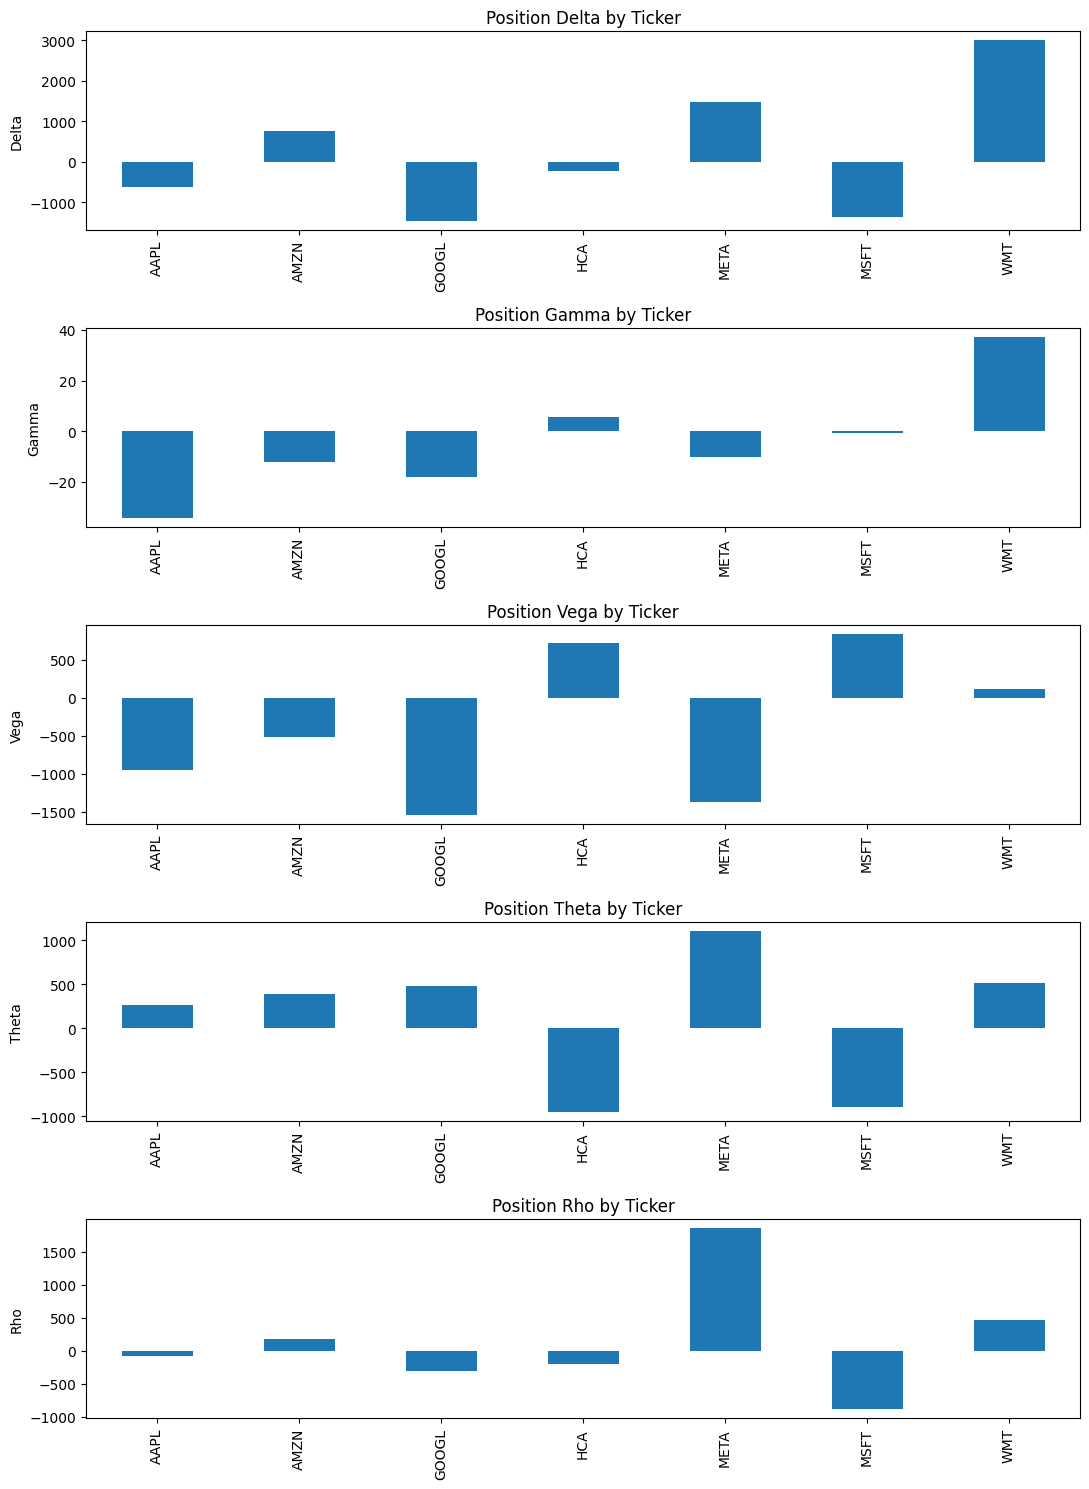

In [21]:
from options_risk_engine.reporting.plots import plot_portfolio_greeks

plot_portfolio_greeks(portfolio_risk, FIGURE_DIR / "04_portfolio_greeks.png")
plt.show()

### Greek-exposure observations

The portfolio is directionally net long, but this exposure is created by
offsetting ticker positions. WMT and META provide the largest positive Delta
contributions, while GOOGL and MSFT provide substantial negative Delta.

The Gamma profile is especially important. Several large ticker books,
including AAPL, GOOGL, AMZN and META, have negative Gamma, while WMT provides
the largest positive Gamma offset. The portfolio is therefore vulnerable to
some large underlying moves even where first-order Delta exposures appear to
offset.

Vega is negative for several major books, particularly GOOGL, META and AAPL,
but positive for HCA and MSFT. The portfolio can therefore lose from a
volatility increase depending on which positions dominate the scenario.

Theta and Rho are also mixed across tickers. These offsets demonstrate why
portfolio-level risk cannot be inferred from position count or market value
alone. They also foreshadow the importance of Gamma in the later stress-test
results.

### Persist positions and current risk

In [22]:
store.write_frame(position_options, "portfolio_positions", run_id=run_id)
store.write_frame(portfolio_risk, "portfolio_risk", run_id=run_id)

2026-08-02 13:38:45,076 - options_risk_engine.database - INFO - Stored 966 rows in portfolio_positions
2026-08-02 13:38:45,081 - options_risk_engine.database - INFO - Stored 8 rows in portfolio_risk


## 12. Transparent multi-factor stress scenarios

The portfolio is tested under 1,000 reproducible market scenarios plus an
unchanged BASE scenario.

Each scenario contains:

- a percentage spot-price shock;
- an absolute volatility shock;
- a number of elapsed calendar days; and
- an absolute interest-rate shock.

The distributions are intentionally broad and transparent. They are designed
for stress testing and engine demonstration rather than being calibrated as a
formal historical or Monte Carlo Value-at-Risk model.

In [23]:
from options_risk_engine.risk.scenarios import generate_random_scenarios

scenario_shocks = generate_random_scenarios(
    number_of_scenarios=CONFIG.scenario_count,
    max_days_forward=CONFIG.max_days_forward,
    seed=CONFIG.random_seed,
)
display(scenario_shocks.head(10))
display(scenario_shocks.drop(columns="Scenario ID").describe().T.round(4))

2026-08-02 13:38:45,088 - options_risk_engine.risk.scenarios - INFO - Generating 1000 random scenarios with up to 30 days forward; seed=42
2026-08-02 13:38:45,092 - options_risk_engine.risk.scenarios - INFO - Scenario generation complete: 1001 total rows including BASE


,Spot Shock,Volatility Shock,Days Forward,Rate Shock,Scenario ID
0,0.000000,0.000000,0,0.000000,BASE
1,0.024377,-0.002964,22,-0.000011,R0001
2,-0.083199,-0.036464,1,0.004077,R0002
3,0.060036,-0.020724,11,-0.003509,R0003
4,0.075245,0.031696,13,0.003830,R0004
5,-0.156083,0.000150,29,-0.003810,R0005
6,-0.104174,0.017010,16,0.005453,R0006
7,0.010227,0.033504,16,0.011053,R0007
8,-0.025299,-0.018742,4,-0.000610,R0008
9,-0.001344,0.037812,24,-0.010963,R0009


,count,mean,std,min,25%,50%,75%,max
Spot Shock,1001.0,-0.0023,0.0791,-0.2919,-0.0557,0.0005,0.0472,0.2543
Volatility Shock,1001.0,-0.0041,0.0507,-0.1524,-0.0365,-0.0022,0.0301,0.1457
Days Forward,1001.0,14.7642,9.0786,0.0000,7.0000,15.0000,23.0000,30.0000
Rate Shock,1001.0,0.0002,0.0050,-0.0143,-0.0032,0.0002,0.0037,0.0154


### Scenario-distribution observations

The generated spot shocks are centred close to zero with a standard deviation
of approximately 7.9%, and range from roughly -29.2% to +25.4%. Volatility
shocks range from approximately -15.2 to +14.6 percentage points, while the
time horizon varies from zero to 30 calendar days.

The broad ranges ensure that the engine is tested under both moderate and
severe movements. The BASE scenario provides a direct accounting check: no
change in spot, volatility, time or rates should produce zero P&L.

One limitation is that the same percentage spot and volatility shock is
currently applied to every ticker. This creates a common systemic stress but
does not represent individual equity correlations or idiosyncratic moves.

## 13. Full-revaluation scenario engine

For every scenario, each option is fully repriced using its shocked spot,
volatility, time to expiry and interest rate. Share positions are repriced
directly using the shocked stock price.

Full revaluation is used as the primary scenario P&L because options are
nonlinear. A local Greek approximation may be accurate for small movements,
but it does not update the Greeks as the option moves through a large shock.

Scenario P&L is measured relative to the model value calculated using the
unshocked scenario inputs. This ensures that the BASE scenario has zero P&L
even where the current market midpoint differs from the selected model value.

In [24]:
from options_risk_engine.risk.scenarios import run_scenario_engine

results, scenario_ticker, scenario_portfolio = run_scenario_engine(
    position_options=position_options,
    scenarios=scenario_shocks,
    dividend_yields=dividend_yields,
)

print("Position-scenario rows:", len(results))
display(results.head())
display(scenario_portfolio.head())

2026-08-02 13:38:45,113 - options_risk_engine.risk.scenarios - INFO - Starting scenario engine: 966 positions across 1001 scenarios
2026-08-02 13:38:45,116 - options_risk_engine.risk.scenarios - INFO - Scenario positions classified: 565 calls, 394 puts and 7 shares
2026-08-02 13:38:45,122 - options_risk_engine.risk.scenarios - INFO - Base model prices calculated for 966 positions
2026-08-02 13:38:45,123 - options_risk_engine.risk.scenarios - INFO - Revaluing scenario 1/1001: BASE
2026-08-02 13:38:45,487 - options_risk_engine.risk.scenarios - INFO - Revaluing scenario 100/1001: R0099
2026-08-02 13:38:45,854 - options_risk_engine.risk.scenarios - INFO - Revaluing scenario 200/1001: R0199
2026-08-02 13:38:46,251 - options_risk_engine.risk.scenarios - INFO - Revaluing scenario 300/1001: R0299
2026-08-02 13:38:46,669 - options_risk_engine.risk.scenarios - INFO - Revaluing scenario 400/1001: R0399
2026-08-02 13:38:47,056 - options_risk_engine.risk.scenarios - INFO - Revaluing scenario 500/10

Position-scenario rows: 966966


,Scenario ID,Contract Symbol,Ticker,Option Type,Current Market Price,Base Model Price,Scenario Price,Market-to-Model PnL,Scenario PnL,Scenario Market Value,Shocked Spot,Shocked Volatility,Shocked Rate,Shocked Time,Spot Shock,Volatility Shock,Rate Shock,Days Forward
0,BASE,AAPL260918C00050000,AAPL,Calls,259.075,259.074991,259.074991,-0.002635,0.0,77722.497365,308.910004,4.891423,0.0375,0.128767,0.0,0.0,0.0,0
1,BASE,AAPL260918C00055000,AAPL,Calls,254.200,254.200000,254.200000,-0.000007,-0.0,-25420.000007,308.910004,4.611713,0.0375,0.128767,0.0,0.0,0.0,0
2,BASE,AAPL260918C00060000,AAPL,Calls,249.175,249.175003,249.175003,-0.000971,-0.0,-74752.500971,308.910004,4.348040,0.0375,0.128767,0.0,0.0,0.0,0
3,BASE,AAPL260918C00065000,AAPL,Calls,192.550,230.610072,230.610072,19030.036191,0.0,115305.036191,308.910004,0.262272,0.0375,0.128767,0.0,0.0,0.0,0
4,BASE,AAPL260918C00070000,AAPL,Calls,239.275,239.275000,239.275000,-0.000040,0.0,47854.999960,308.910004,3.918869,0.0375,0.128767,0.0,0.0,0.0,0


,Scenario ID,Portfolio_PnL,Portfolio_Value
0,BASE,0.000000,-842272.058183
1,R0001,7831.894656,-834440.163527
2,R0002,-11142.751852,-853414.810035
3,R0003,-10400.133826,-852672.192009
4,R0004,-22980.244444,-865252.302628


### Scenario-engine observations

The engine repriced 966 positions across 1,001 scenarios, producing 966,966
position-level rows. The portfolio contained 565 calls, 394 puts and seven
share positions.

The BASE portfolio P&L is exactly zero, confirming that the scenario engine
uses a consistent model-to-model comparison.

The BASE portfolio value differs from the earlier signed market value because
the scenario engine values positions on its model basis. For contracts where
the market midpoint cannot be reproduced reliably and a volatility fallback
is required, the model price may differ from the current market mark. This
difference is intentionally excluded from scenario movement P&L.

The position, ticker and portfolio outputs allow the same scenario to be
analysed at several levels without rerunning the pricing engine.

### Distribution of portfolio stress P&L

The histogram summarises the non-base portfolio P&L outcomes. The zero line
separates profitable and loss-making scenarios, while the fifth-percentile
line identifies the lower tail of the assumed stress distribution.

The result should be described as a scenario loss distribution rather than
formal VaR because the underlying shocks were selected for transparent stress
testing rather than estimated from a calibrated joint market model.

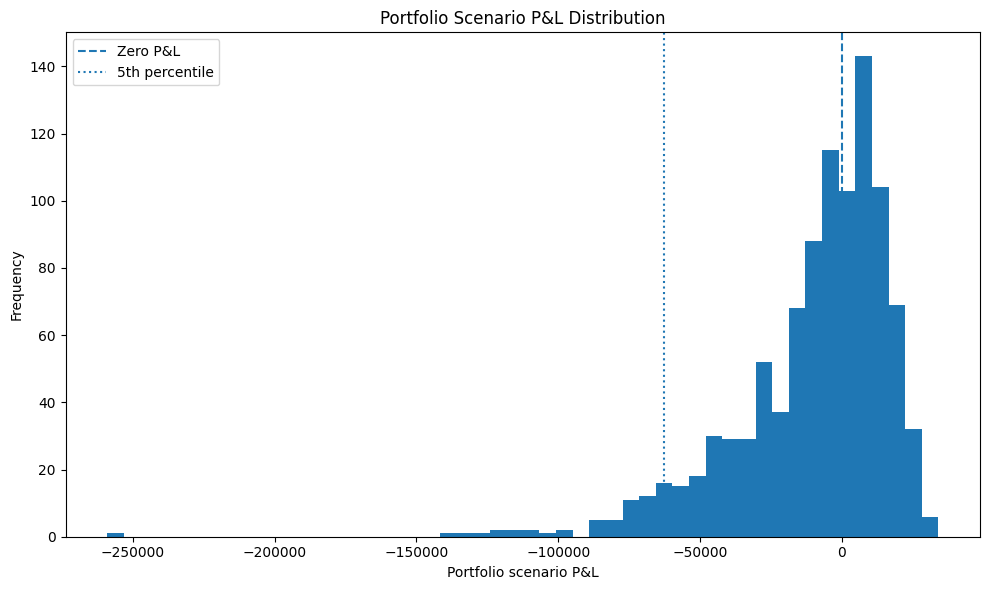

In [25]:
from options_risk_engine.reporting.plots import plot_scenario_pnl_distribution

plot_scenario_pnl_distribution(
    scenario_portfolio, FIGURE_DIR / "05_scenario_pnl_distribution.png"
)
plt.show()

The distribution is visibly left-skewed. Most observations lie relatively
close to zero, but a small number of severe scenarios produce losses that are
much larger than the maximum gains.

This asymmetry is consistent with a portfolio containing significant negative
Gamma and mixed volatility exposure. It indicates that offsetting Delta can
reduce ordinary movement risk without eliminating losses from large nonlinear
shocks.

## 14. Tail-loss and risk-limit analysis

The scenario outputs are summarised into central and tail statistics. The
analysis also compares losses with predefined portfolio and ticker limits.

The aim is to answer:

- how often the generated scenarios produce a loss;
- how severe the lower tail is;
- which scenarios exceed the chosen loss tolerance; and
- which tickers are responsible for the worst portfolio outcome.

In [26]:
from options_risk_engine.risk.scenarios import analyse_scenario_results

scenario_analysis = analyse_scenario_results(
    scenarios=scenario_shocks,
    results=results,
    scenario_ticker=scenario_ticker,
    scenario_portfolio=scenario_portfolio,
    portfolio_risk=portfolio_risk,
    base_scenario_id=BASE_SCENARIO_ID,
    max_portfolio_loss=CONFIG.max_portfolio_loss,
    max_ticker_loss=CONFIG.max_ticker_loss,
    number_to_show=10,
)

display(scenario_analysis["scenario_risk_summary"])
display(scenario_analysis["worst_scenarios"])
display(scenario_analysis["portfolio_breaches"].head(10))

2026-08-02 13:38:49,680 - options_risk_engine.risk.scenarios - INFO - Analysing scenario outputs: 966966 position rows, 7007 ticker rows and 1001 portfolio rows
2026-08-02 13:38:49,805 - options_risk_engine.risk.scenarios - INFO - Base scenario validation passed: portfolio P&L 0.00000000
2026-08-02 13:38:49,809 - options_risk_engine.risk.scenarios - INFO - All scenario positions were repriced successfully
2026-08-02 13:38:49,813 - options_risk_engine.risk.scenarios - INFO - Scenario distribution analysed: worst P&L -258974.50; 5th percentile -62652.47; probability of loss 56.20%
2026-08-02 13:38:49,866 - options_risk_engine.risk.scenarios - WARNING - 11 portfolio scenarios breached the 100000.00 loss limit
2026-08-02 13:38:49,866 - options_risk_engine.risk.scenarios - WARNING - 1473 ticker-scenario rows breached the 25000.00 loss limit
2026-08-02 13:38:49,867 - options_risk_engine.risk.scenarios - INFO - Scenario analysis complete; worst scenario is R0950


,Number of Scenarios,Best PnL,Worst PnL,Mean PnL,Median PnL,Probability of Loss,5th Percentile PnL,1st Percentile PnL,5% Expected Shortfall
0,1000,33992.120695,-258974.501469,-10027.264199,-2878.092454,0.562,-62652.46898,-103953.823314,-87099.104201


,Scenario ID,Portfolio_PnL,Portfolio_Value,Spot Shock,Volatility Shock,Days Forward,Rate Shock
0,R0950,-258974.501469,-1.101247e+06,-0.291873,0.100048,6,-0.001420
1,R0505,-138590.113771,-9.808622e+05,-0.237162,-0.010587,19,0.011951
2,R0948,-135009.743342,-9.772818e+05,-0.234448,-0.045455,17,-0.003257
3,R0581,-124511.484955,-9.667835e+05,-0.192794,0.059481,2,-0.004227
4,R0140,-124106.663085,-9.663787e+05,0.233109,0.000190,0,-0.004084
5,R0630,-120299.094089,-9.625712e+05,-0.193022,0.053892,4,-0.004121
6,R0830,-113301.103968,-9.555732e+05,-0.213827,-0.011323,16,0.005676
7,R0847,-113268.581506,-9.555406e+05,0.254308,0.001635,29,-0.001407
8,R0480,-107227.049371,-9.494991e+05,0.207814,0.085293,6,0.010157
9,R0249,-106780.068009,-9.490521e+05,0.232405,-0.008578,22,-0.001176


,Scenario ID,Portfolio_PnL,Portfolio_Value,Spot Shock,Volatility Shock,Days Forward,Rate Shock,PnL on Gross Value,Portfolio Limit Breached
0,R0950,-258974.501469,-1.101247e+06,-0.291873,0.100048,6,-0.001420,-0.014593,True
1,R0505,-138590.113771,-9.808622e+05,-0.237162,-0.010587,19,0.011951,-0.007809,True
2,R0948,-135009.743342,-9.772818e+05,-0.234448,-0.045455,17,-0.003257,-0.007607,True
3,R0581,-124511.484955,-9.667835e+05,-0.192794,0.059481,2,-0.004227,-0.007016,True
4,R0140,-124106.663085,-9.663787e+05,0.233109,0.000190,0,-0.004084,-0.006993,True
5,R0630,-120299.094089,-9.625712e+05,-0.193022,0.053892,4,-0.004121,-0.006779,True
6,R0830,-113301.103968,-9.555732e+05,-0.213827,-0.011323,16,0.005676,-0.006384,True
7,R0847,-113268.581506,-9.555406e+05,0.254308,0.001635,29,-0.001407,-0.006382,True
8,R0480,-107227.049371,-9.494991e+05,0.207814,0.085293,6,0.010157,-0.006042,True
9,R0249,-106780.068009,-9.490521e+05,0.232405,-0.008578,22,-0.001176,-0.006017,True


### Portfolio stress findings

Of the 1,000 non-base scenarios, 56% produced a portfolio loss. Mean P&L was
approximately -£9,959 and median P&L was approximately -£2,826. The fifth
percentile was approximately -£62,581.

The best scenario produced a gain of approximately £34,096, whereas the worst
scenario produced a loss of approximately £258,560. The much larger downside
tail confirms that the portfolio's nonlinear exposure is asymmetric.

Eleven scenarios breached the £100,000 portfolio loss limit. The ticker-level
limit was also breached frequently, although several ticker losses can occur
within the same portfolio scenario and should not be interpreted as
independent events.

The worst scenario, R0950, combined a 29.2% fall in the common spot factor with
an increase of approximately 10 volatility points, six elapsed days and a
small reduction in rates. This combination exposed the portfolio's negative
convexity and volatility sensitivity.

### Concentration and offsetting positions

Portfolio P&L can conceal large opposing ticker-level movements. The worst
scenario is therefore decomposed by underlying to identify both the principal
loss contributors and the positions that reduced the net loss.

,Scenario ID,Ticker,Scenario_PnL,Scenario_Value,Spot Shock,Volatility Shock,Days Forward,Rate Shock
0,R0950,META,-352145.456273,-962827.059593,-0.291873,0.100048,6,-0.00142
1,R0950,AMZN,-121397.742717,-43316.721405,-0.291873,0.100048,6,-0.00142
2,R0950,WMT,-102611.555044,-124353.601155,-0.291873,0.100048,6,-0.00142
3,R0950,AAPL,-32937.479471,-162148.561715,-0.291873,0.100048,6,-0.00142
4,R0950,GOOGL,66890.896367,-219240.252621,-0.291873,0.100048,6,-0.00142
5,R0950,HCA,77157.596070,143562.282389,-0.291873,0.100048,6,-0.00142
6,R0950,MSFT,206069.239598,267077.354447,-0.291873,0.100048,6,-0.00142


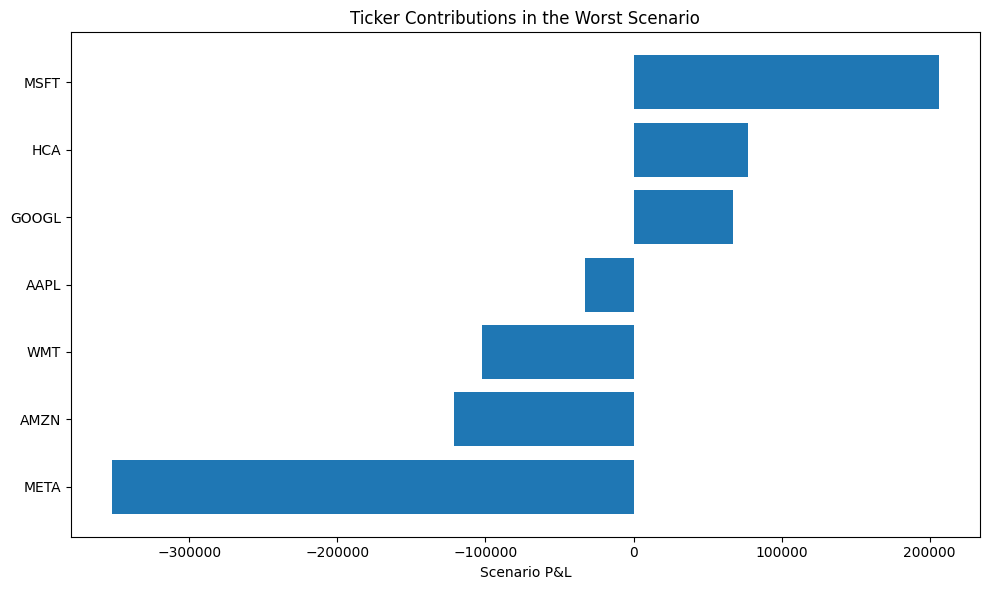

In [27]:
from options_risk_engine.reporting.plots import plot_worst_ticker_contributions

worst_ticker_contributions = scenario_analysis["worst_ticker_contributions"]
display(worst_ticker_contributions)
plot_worst_ticker_contributions(
    worst_ticker_contributions,
    FIGURE_DIR / "06_worst_scenario_tickers.png",
)
plt.show()

META was the largest loss contributor in the worst scenario, losing
approximately £351,975. AMZN and WMT added losses of roughly £121,419 and
£102,651 respectively, while AAPL lost approximately £33,002.

These losses were partly offset by gains of around £206,307 from MSFT,
£77,257 from HCA and £66,924 from GOOGL.

The result demonstrates both concentration and netting. The final portfolio
loss was materially smaller than the sum of the losing ticker books because
several positions benefited from the same shock. However, relying on those
offsets can be unstable because they depend on the assumed common movement and
the specific option exposures held at the valuation date.

## 15. Greek P&L attribution

Full revaluation measures the scenario result accurately under the pricing
model, but it does not by itself explain why the value changed.

The position-level components are aggregated to ticker and portfolio level.
The residual is defined as full-revaluation P&L minus the sum of the Greek
components.

A small residual indicates that the local Greek approximation represented the
scenario well. A large residual can result from large shocks, changing Greeks,
higher-order terms, cross-Greek effects or movement near expiry.

In [28]:
from options_risk_engine.risk.attribution import (
    calculate_greek_profit_loss,
    analyse_greek_attribution,
)

# Keep Ticker from the scenario-results table. Selecting Ticker from both
# tables would create Ticker_x and Ticker_y, while the attribution function
# expects a single column named Ticker.
attribution_position_inputs = position_options[
    [
        "contractSymbol",
        "Current Stock Price",
        "Position Delta",
        "Position Gamma",
        "Position Vega",
        "Position Theta",
        "Position Rho",
    ]
].copy()

expanded_results = results.merge(
    attribution_position_inputs,
    left_on="Contract Symbol",
    right_on="contractSymbol",
    how="left",
    validate="many_to_one",
)

if "Ticker" not in expanded_results.columns:
    raise KeyError(
        "Attribution merge did not retain the Ticker column."
    )

attribution_results, scenario_attribution = (
    calculate_greek_profit_loss(
        expanded_results
    )
)

attribution_analysis = analyse_greek_attribution(
    scenario_attribution=scenario_attribution,
    attribution_results=attribution_results,
    scenarios=scenario_shocks,
    base_scenario_id=BASE_SCENARIO_ID,
    number_to_show=10,
)

scenario_attribution = (
    attribution_analysis[
        "scenario_attribution"
    ]
)

display(attribution_results.head())
display(scenario_attribution.head())


2026-08-02 13:38:50,312 - options_risk_engine.risk.attribution - INFO - Starting Greek P&L attribution
2026-08-02 13:38:50,768 - options_risk_engine.risk.attribution - INFO - Greek attribution accounting check passed
2026-08-02 13:38:50,769 - options_risk_engine.risk.attribution - INFO - Greek attribution completed for 966966 position-scenario rows and 1001 scenarios
2026-08-02 13:38:50,769 - options_risk_engine.risk.attribution - INFO - Starting Greek attribution analysis
2026-08-02 13:38:50,968 - options_risk_engine.risk.attribution - INFO - Scenario shocks attached to 1001 attribution rows
2026-08-02 13:38:50,970 - options_risk_engine.risk.attribution - INFO - Greek attribution accounting check passed
2026-08-02 13:38:51,117 - options_risk_engine.risk.attribution - INFO - BASE Greek attribution validation passed
2026-08-02 13:38:51,907 - options_risk_engine.risk.attribution - INFO - Greek attribution analysis completed for 1000 scenarios


,Scenario ID,Contract Symbol,Ticker,Option Type,Current Stock Price,Shocked Spot,Scenario PnL,Position Delta,Position Gamma,Position Vega,Position Theta,Position Rho,Spot Shock,Volatility Shock,Rate Shock,Days Forward,Spot Change,Delta PnL,Gamma PnL,Vega PnL,Theta PnL,Rho PnL,Approximate PnL,Residual PnL,Residual %
0,BASE,AAPL260918C00050000,AAPL,Calls,308.910004,308.910004,0.0,278.395924,3.522339e-02,2.117070e+01,-28.550027,10.657783,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,NaN
1,BASE,AAPL260918C00055000,AAPL,Calls,308.910004,308.910004,-0.0,-92.491086,-1.357752e-02,-7.693992e+00,10.673844,-4.057995,0.0,0.0,0.0,0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,NaN
2,BASE,AAPL260918C00060000,AAPL,Calls,308.910004,308.910004,-0.0,-276.579626,-4.658640e-02,-2.488981e+01,34.300485,-13.759684,0.0,0.0,0.0,0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,NaN
3,BASE,AAPL260918C00065000,AAPL,Calls,308.910004,308.910004,0.0,477.966002,9.178241e-57,2.957876e-55,138.257777,41.647722,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,BASE,AAPL260918C00070000,AAPL,Calls,308.910004,308.910004,0.0,183.195209,3.930311e-02,1.892590e+01,-25.534618,11.248881,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,NaN


,Scenario ID,Full_Revaluation_PnL,Delta_PnL,Gamma_PnL,Vega_PnL,Theta_PnL,Rho_PnL,Approximate_PnL,Residual_PnL,Net Residual %,Attribution Check,Spot Shock,Volatility Shock,Days Forward,Rate Shock,Gross_Full_PnL,Gross_Residual,Gross Residual %
0,BASE,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000e+00,0.000000,0.000000,0,0.000000,0.000000e+00,0.000000,NaN
1,R0001,7831.894656,-1528.348142,-2517.213009,798.271711,19835.422622,-1.129441,16587.003741,-8755.109085,1.117879,7.275958e-12,0.024377,-0.002964,22,-0.000011,1.806780e+06,186465.671540,0.103203
2,R0002,-11142.751852,5216.175536,-29321.067422,9820.228508,901.610119,409.222818,-12973.830440,1831.078588,0.164329,1.159606e-11,-0.083199,-0.036464,1,0.004077,4.216510e+06,65238.090274,0.015472
3,R0003,-10400.133826,-3763.985570,-15267.617822,5581.095744,9917.711311,-352.230328,-3885.026665,-6515.107161,0.626445,7.275958e-12,0.060036,-0.020724,11,-0.003509,3.162085e+06,166650.053141,0.052703
4,R0004,-22980.244444,-4717.524657,-23983.012738,-8535.933461,11720.931549,384.447774,-25131.091532,2150.847088,0.093595,-1.273293e-11,0.075245,0.031696,13,0.003830,4.068295e+06,129175.734011,0.031752


### Attribution construction checks

The attribution was calculated for all 966,966 position-scenario rows and
aggregated into 1,001 scenario results.

The BASE scenario has zero Delta, Gamma, Vega, Theta, Rho, approximate P&L and
residual P&L.

These checks validate the attribution arithmetic before its accuracy is
interpreted.

### Attribution accuracy summary

In [29]:
display(attribution_analysis["attribution_summary"])
display(attribution_analysis["small_scenario_summary"])
display(attribution_analysis["worst_attribution_scenarios"])
display(attribution_analysis["base_attribution"])

,Number of Scenarios,Mean Absolute Residual,Median Absolute Residual,95th Percentile Absolute Residual,Mean Gross Residual %,Median Gross Residual %,95th Percentile Gross Residual %
0,1000,9529.008343,5550.492032,30341.798895,0.084878,0.074413,0.181814


,Number of Small Scenarios,Mean Absolute Residual,Median Absolute Residual,Mean Gross Residual %,Median Gross Residual %
0,5,221.011172,127.777137,0.01573,0.015333


,Scenario ID,Spot Shock,Volatility Shock,Days Forward,Rate Shock,Full_Revaluation_PnL,Delta_PnL,Gamma_PnL,Vega_PnL,Theta_PnL,Rho_PnL,Approximate_PnL,Residual_PnL,Gross Residual %
0,R0316,-0.023726,0.091811,27,-0.004278,8949.144822,1487.490187,-2384.424630,-24725.737482,24343.473218,-429.405182,-1708.603889,10657.748711,0.325116
1,R0259,-0.010706,0.086982,23,-0.002349,5271.964855,671.206482,-485.498246,-23425.267124,20737.032741,-235.834406,-2738.360552,8010.325407,0.312584
2,R0664,-0.027387,0.089914,27,0.002092,9457.636915,1717.055500,-3177.196288,-24214.880680,24343.473218,210.052735,-1121.495515,10579.132430,0.310343
3,R0509,-0.044766,0.099876,29,0.011655,9051.191539,2806.607574,-8488.652717,-26897.568975,26146.693456,1169.986118,-5262.934544,14314.126083,0.288361
4,R0199,-0.000410,0.074246,23,-0.001199,5949.518170,25.689389,-0.711186,-19995.205006,20737.032741,-120.345683,646.460255,5303.057915,0.253800
5,R0448,-0.026519,0.075822,22,-0.008835,5922.587352,1662.622038,-2978.944733,-20419.655918,19835.422622,-886.872162,-2787.428153,8710.015505,0.249584
6,R0863,-0.004673,0.070626,24,0.002102,8062.268819,292.969190,-92.495218,-19020.224311,21638.642861,210.968113,3029.860634,5032.408185,0.245294
7,R0240,-0.042355,0.077594,27,0.009206,10263.117523,2655.472302,-7599.043532,-20896.874243,24343.473218,924.161608,-572.810647,10835.928170,0.240420
8,R0134,-0.017778,0.069085,16,0.007687,1573.625777,1114.586838,-1338.761458,-18605.412522,14425.761907,771.629325,-3632.195910,5205.821687,0.237316
9,R0215,-0.026214,-0.132585,20,0.005931,33992.120695,1643.487019,-2910.770314,35706.634091,18032.202384,595.347736,53066.900916,-19074.780221,0.234001


,Scenario ID,Full_Revaluation_PnL,Delta_PnL,Gamma_PnL,Vega_PnL,Theta_PnL,Rho_PnL,Approximate_PnL,Residual_PnL,Net Residual %,Attribution Check,Spot Shock,Volatility Shock,Days Forward,Rate Shock,Gross_Full_PnL,Gross_Residual,Gross Residual %,Attribution Validation Passed
0,BASE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0,0.0,0.0,0.0,NaN,True


Across all 1,000 non-base scenarios, the mean absolute residual was
approximately £9,498 and the median was approximately £5,525. Mean gross
residual percentage was approximately 8.5%, with a median of 7.4% and a
95th-percentile value of about 18.1%.

For the small-scenario subset, mean gross residual percentage fell to around
1.6%, and the median absolute residual was only about £130. This is consistent
with Greeks being local derivatives that perform best near the original
market state.

Only five generated scenarios satisfied the small-shock definition, so this
subset is too small for a strong statistical conclusion. It is supporting
evidence rather than a definitive estimate of small-move accuracy.

### Visual attribution diagnostics

The first graph compares full-revaluation P&L with approximate Greek P&L. A
perfect approximation would place every scenario on the diagonal line.

The second graph compares gross residual percentage with absolute spot shock.
This helps investigate whether the approximation deteriorates as scenarios
become more severe.

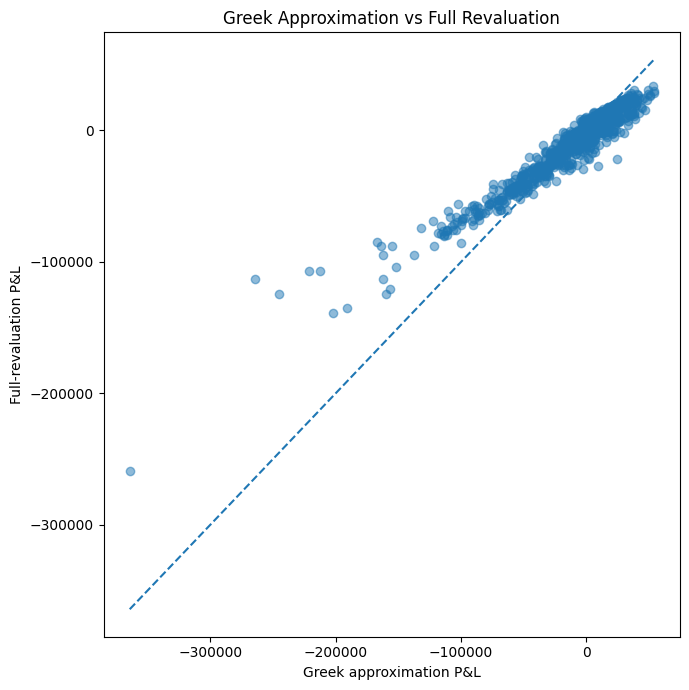

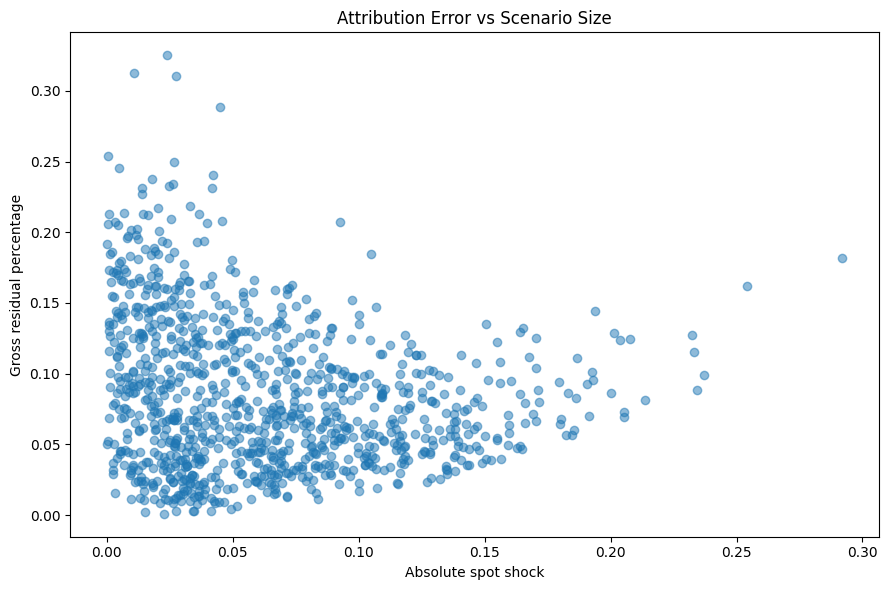

In [30]:
from options_risk_engine.reporting.plots import (
    plot_attribution_components,
    plot_full_vs_approximate_pnl,
    plot_residual_vs_spot_shock,
)

plot_full_vs_approximate_pnl(
    scenario_attribution,
    FIGURE_DIR / "07_full_vs_approximate_pnl.png",
)
plt.show()

plot_residual_vs_spot_shock(
    scenario_attribution,
    FIGURE_DIR / "08_residual_vs_spot_shock.png",
)
plt.show()

Most central scenarios lie reasonably close to the equality line, indicating
that the Greeks capture the main direction of ordinary P&L changes. The
largest deviations occur in the tails, where the portfolio is moved far from
the state at which its Greeks were calculated.

The residual-versus-spot plot does not show a perfectly monotonic
relationship. Spot shock is only one part of scenario size; volatility shock,
elapsed time, strike location and offsetting position P&L also affect the
residual percentage. Small net P&L can additionally make percentage measures
appear large.

The appropriate conclusion is therefore that attribution is most reliable for
small combined shocks and becomes less dependable under some large nonlinear
moves, not that spot movement alone determines approximation error.

### Explaining the worst portfolio loss

The Greek components of R0950 are examined separately to identify the risk
factor that dominated the portfolio's largest full-revaluation loss.

,Value
Scenario ID,R0950
Full_Revaluation_PnL,-258974.501469
Delta_PnL,18299.089006
Gamma_PnL,-360856.323175
Vega_PnL,-26944.01053
Theta_PnL,5409.660715
Rho_PnL,-142.594755
Approximate_PnL,-364234.178739
Residual_PnL,105259.67727
Net Residual %,0.406448


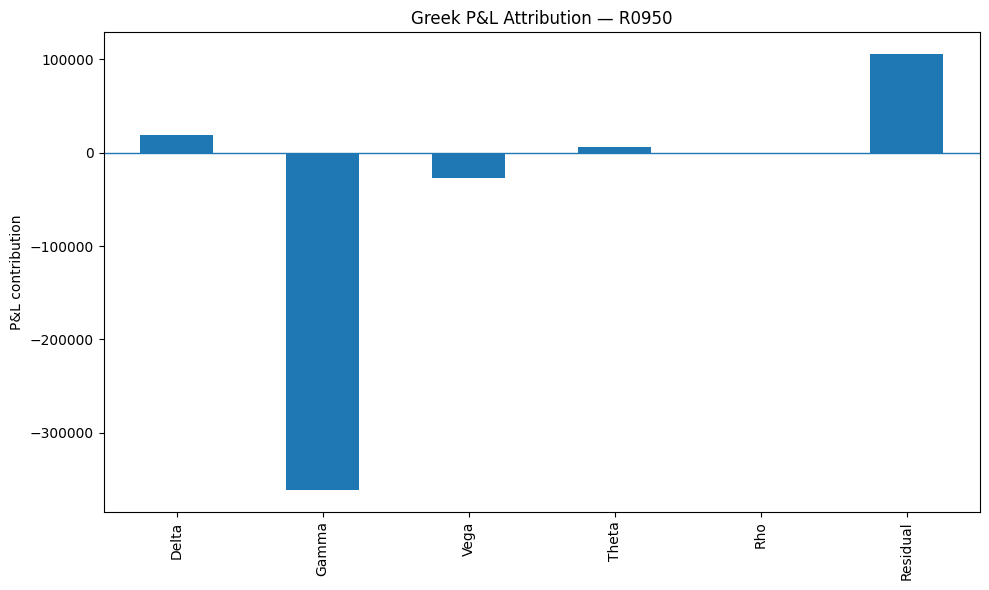

In [31]:
worst_scenario_id = scenario_analysis["worst_scenario_id"]
worst_attribution_row = scenario_attribution.loc[
    scenario_attribution["Scenario ID"].eq(worst_scenario_id)
].iloc[0]

display(worst_attribution_row.to_frame("Value"))
plot_attribution_components(
    worst_attribution_row,
    FIGURE_DIR / "09_worst_scenario_attribution.png",
)
plt.show()

Gamma was the dominant risk factor in the worst scenario, contributing an
estimated loss of approximately £359,726. Vega added a further loss of around
£26,969.

Delta contributed a positive £18,898 and Theta contributed a positive £5,397,
partly offsetting the nonlinear loss. Rho was comparatively immaterial.

The total Greek approximation was approximately -£362,542, compared with a
full-revaluation loss of approximately -£258,560. The residual was therefore
positive £103,982, equivalent to about 40.2% of net full-revaluation P&L and
18.2% on a gross-position basis.

This is economically consistent with the scenario. A 29% spot fall and a
10-point volatility increase are far from the local state at which the Greeks
were calculated. Gamma correctly identifies negative convexity as the
principal vulnerability, but the fixed-Greek approximation overstates the
final loss because the portfolio's Greeks change substantially through the
shock.

## 16. End-to-end risk-engine validation

The final validation checks relationships that span several earlier stages.
This is intended to detect integration errors that would not necessarily be
found by testing an individual pricing function.

The checks verify that:

- BASE portfolio P&L is zero;
- position P&L aggregates exactly to portfolio P&L;
- full revaluation equals approximation plus residual;
- all scenario prices are present;
- shocked option volatility remains positive;
- shocked option time is nonnegative;
- share prices equal shocked spot values; and
- every position type is recognised.

In [32]:
from options_risk_engine.validation import validate_risk_engine

validation_checks = validate_risk_engine(
    results=results,
    scenario_portfolio=scenario_portfolio,
    scenario_attribution=scenario_attribution,
)
display(pd.Series(validation_checks, name="Passed").to_frame())

2026-08-02 13:38:53,150 - options_risk_engine.validation - INFO - All risk-engine validation checks passed


,Passed
base_pnl_zero,True
position_totals_match_portfolio,True
attribution_identity,True
no_missing_scenario_prices,True
option_shocked_volatility_positive,True
option_shocked_time_nonnegative,True
share_prices_match_shocked_spot,True
known_position_types,True


All cross-stage checks passed.

This confirms that the pricing, scenario aggregation, share handling and
attribution accounting are internally consistent for this run. It does not
prove that the Black–Scholes assumptions or scenario distributions are an
accurate representation of future markets, but it provides evidence that the
engine implements its stated methodology correctly.

## 17. Persist final scenario and attribution outputs

The final position-, ticker- and portfolio-level outputs are written to both
SQLite and CSV.

Storing multiple aggregation levels allows later analysis to begin with the
compact portfolio table while retaining the ability to trace a result back to
the individual contracts that produced it.

In [33]:
outputs_to_store = {
    "scenario_definitions": scenario_shocks,
    "scenario_position_results": results,
    "scenario_ticker_results": scenario_ticker,
    "scenario_portfolio_results": scenario_portfolio,
    "attribution_position_results": attribution_results,
    "scenario_attribution": scenario_attribution,
}
for table_name, frame in outputs_to_store.items():
    store.write_frame(frame, table_name, run_id=run_id)
    frame.to_csv(TABLE_DIR / f"{table_name}.csv", index=False)

print("Stored final tables:")
display(store.list_tables())

2026-08-02 13:38:53,179 - options_risk_engine.database - INFO - Stored 1001 rows in scenario_definitions
2026-08-02 13:38:56,881 - options_risk_engine.database - INFO - Stored 966966 rows in scenario_position_results
2026-08-02 13:39:10,650 - options_risk_engine.database - INFO - Stored 7007 rows in scenario_ticker_results
2026-08-02 13:39:10,676 - options_risk_engine.database - INFO - Stored 1001 rows in scenario_portfolio_results
2026-08-02 13:39:15,360 - options_risk_engine.database - INFO - Stored 966966 rows in attribution_position_results
2026-08-02 13:39:36,608 - options_risk_engine.database - INFO - Stored 1001 rows in scenario_attribution


Stored final tables:


,name
0,attribution_position_results
1,equity_prices
2,model_evaluations
3,option_chain_snapshots
4,option_chain_snapshots_full
5,option_pricing_results
6,portfolio_positions
7,portfolio_risk
8,project_runs
9,scenario_attribution


The final run stores 1,001 scenario definitions, 966,966 position-scenario
results, 7,007 ticker-scenario results, 1,001 portfolio-scenario results,
966,966 position-attribution rows and 1,001 scenario-attribution rows.

The row counts provide a final completeness check and demonstrate that all
positions and scenarios are represented at each required aggregation level.

For a larger production system, the two 966,966-row tables would be natural
candidates for partitioned Parquet storage rather than repeated CSV exports.

# 18. Standardised one-contract scenario analysis

The existing portfolio was designed to test aggregation and portfolio risk.
Its directions, quantities and entry prices were assigned using a fixed random
seed, so its position-level results cannot fairly compare the quality of
individual option recommendations.

This section creates a separate contract-analysis universe in which every
eligible option is evaluated on identical terms:

- one long contract;
- quantity one;
- a standard multiplier of 100;
- entry at the current ask; and
- a position scale of +100.

`Buy`, `Positive Edge` and `Do Not Buy` contracts are retained. Including all
three classifications provides comparison groups for testing whether the
initial valuation labels correspond to better scenario outcomes.

Three valuation concepts remain separate:

1. **Forecast edge** — forecast-volatility Black–Scholes value minus the ask.
2. **Base mark-to-ask P&L** — market-implied risk-model value minus the ask.
3. **Purchase scenario P&L** — shocked full-revaluation value minus the ask.

This prevents a forecast-based theoretical edge from being presented as an
immediately realisable profit.

In [34]:
from options_risk_engine.recommendations.contracts import (
    attach_standardised_purchase_pnl,
    prepare_standardised_contract_positions,
    validate_standardised_contract_positions,
)

standardised_contracts = (
    prepare_standardised_contract_positions(
        option_universe=large_table,
        risk_free_rates=risk_free_rates,
        dividend_yields=dividend_yields,
        included_actions=(
            CONTRACT_ANALYSIS_ACTIONS
        ),
    )
)

standardised_position_summary = (
    standardised_contracts
    .groupby(
        [
            "Initial Recommended Action",
            "Option_Type",
        ],
        observed=True,
    )
    .agg(
        Contracts=(
            "contractSymbol",
            "count",
        ),
        Median_Ask=(
            "ask",
            "median",
        ),
        Median_Forecast_Edge=(
            "BS_ForeV AskEdge",
            "median",
        ),
        Median_Spread=(
            "SpreadPct",
            "median",
        ),
        Median_Volume=(
            "volume",
            "median",
        ),
        Median_Open_Interest=(
            "openInterest",
            "median",
        ),
    )
    .reset_index()
)

print(
    "Standardised contracts:",
    len(standardised_contracts),
)

display(
    standardised_position_summary.round(4)
)

display(
    standardised_contracts[
        [
            "contractSymbol",
            "Ticker",
            "Option_Type",
            "strike",
            "Expiry",
            "Initial Recommended Action",
            "bid",
            "ask",
            "BS_ForeV",
            "BS_ForeV AskEdge",
            "Forecast Edge Per Contract",
            "Greek Volatility",
            "Greek Volatility Source",
            "Premium Paid",
        ]
    ]
    .head(20)
    .round(4)
)

2026-08-02 13:39:36,665 - options_risk_engine.recommendations.contracts - INFO - Preparing standardised contract analysis from 1211 option rows
2026-08-02 13:39:36,689 - options_risk_engine.recommendations.contracts - INFO - Prepared 794 standardised long-one-contract positions


Standardised contracts: 794


,Initial Recommended Action,Option_Type,Contracts,Median_Ask,Median_Forecast_Edge,Median_Spread,Median_Volume,Median_Open_Interest
0,Buy,Calls,14,2.635,0.1373,0.1161,2050.5,6629.5
1,Buy,Puts,77,5.300,0.6359,0.0842,244.0,2088.0
2,Do Not Buy,Calls,545,21.350,-0.5284,0.0725,12.0,409.0
3,Do Not Buy,Puts,142,0.420,-0.9567,0.6043,72.0,2122.0
4,Positive Edge,Calls,5,16.950,0.0249,0.0361,2577.0,12455.0
5,Positive Edge,Puts,11,7.350,0.0307,0.0635,1409.0,2107.0


,contractSymbol,Ticker,Option_Type,strike,Expiry,Initial Recommended Action,bid,ask,BS_ForeV,BS_ForeV AskEdge,Forecast Edge Per Contract,Greek Volatility,Greek Volatility Source,Premium Paid
0,AAPL260918C00050000,AAPL,Calls,50.0,2026-09-18,Do Not Buy,257.15,261.00,245.5378,-0.0592,-1546.2185,4.8914,Calculated Mid IV,26100.0
1,AAPL260918C00055000,AAPL,Calls,55.0,2026-09-18,Do Not Buy,252.30,256.10,240.5619,-0.0607,-1553.8099,4.6117,Calculated Mid IV,25610.0
2,AAPL260918C00060000,AAPL,Calls,60.0,2026-09-18,Do Not Buy,247.35,251.00,235.5860,-0.0614,-1541.4013,4.3480,Calculated Mid IV,25100.0
3,AAPL260918C00070000,AAPL,Calls,70.0,2026-09-18,Do Not Buy,237.40,241.15,225.6342,-0.0643,-1551.5842,3.9189,Calculated Mid IV,24115.0
4,AAPL260918C00075000,AAPL,Calls,75.0,2026-09-18,Do Not Buy,222.20,225.90,220.6582,-0.0232,-524.1756,2.5048,Calculated Mid IV,22590.0
5,AAPL260918C00090000,AAPL,Calls,90.0,2026-09-18,Do Not Buy,217.50,221.05,205.7305,-0.0693,-1531.9499,3.2474,Calculated Mid IV,22105.0
6,AAPL260918C00100000,AAPL,Calls,100.0,2026-09-18,Do Not Buy,207.55,211.15,195.7787,-0.0728,-1537.1328,2.9856,Calculated Mid IV,21115.0
7,AAPL260918C00105000,AAPL,Calls,105.0,2026-09-18,Do Not Buy,202.45,206.25,190.8028,-0.0749,-1544.7243,2.8637,Calculated Mid IV,20625.0
8,AAPL260918C00110000,AAPL,Calls,110.0,2026-09-18,Do Not Buy,197.50,201.10,185.8268,-0.0759,-1527.3157,2.7450,Calculated Mid IV,20110.0
9,AAPL260918C00115000,AAPL,Calls,115.0,2026-09-18,Do Not Buy,192.50,196.15,180.8509,-0.0780,-1529.9071,2.6380,Calculated Mid IV,19615.0


### Observed standardised contract universe

The standardisation process retained 794 of the 1,211 priced option rows.

The retained universe contains:

- 91 contracts initially classified as `Buy`;
- 16 contracts classified as `Positive Edge`; and
- 687 contracts classified as `Do Not Buy`.

The initial `Buy` group is strongly concentrated in puts, with 77 puts and
14 calls. The `Do Not Buy` group is instead dominated by calls, with 545
calls and 142 puts. The forecast-volatility valuation difference was therefore
not distributed evenly across option type in this market snapshot.

Every retained row now represents the same hypothetical transaction: one long
contract purchased at the current ask with a multiplier of 100. Subsequent
differences arise from the contract's strike, option type, volatility, Greeks
and quote rather than randomly assigned quantities or directions.

The initial classifications remain valuation labels only. They have not yet
been tested against the complete scenario distribution.

In [35]:
standardised_contract_checks = (
    validate_standardised_contract_positions(
        standardised_contracts
    )
)

display(
    pd.Series(
        standardised_contract_checks,
        name="Passed",
    )
    .to_frame()
)

2026-08-02 13:39:36,731 - options_risk_engine.recommendations.contracts - INFO - All standardised contract validation checks passed


,Passed
contracts_available,True
unique_contract_symbols,True
all_positions_long,True
one_contract_each,True
standard_multiplier,True
entry_equals_ask,True
positive_premium,True
complete_pricing_inputs,True
recognised_option_types,True
forecast_edge_matches_existing_column,True


### Standardisation validation

All construction checks passed.

The 794 contracts have unique contract symbols, complete pricing and Greek
inputs, positive premiums, recognised option types and identical
long-one-contract position mechanics.

The independently calculated forecast-edge return also agrees with the existing
`BS_ForeV AskEdge` field. The recommendation analysis therefore uses the same
definition of initial model edge as the original pricing stage.

In [36]:
from options_risk_engine.risk.scenarios import (
    run_scenario_engine,
)

(
    raw_contract_scenario_results,
    _,
    _,
) = run_scenario_engine(
    position_options=standardised_contracts,
    scenarios=scenario_shocks,
    dividend_yields=dividend_yields,
)

print(
    "Contract-scenario rows:",
    len(raw_contract_scenario_results),
)

print(
    "Contracts:",
    raw_contract_scenario_results[
        "Contract Symbol"
    ].nunique(),
)

print(
    "Scenarios:",
    raw_contract_scenario_results[
        "Scenario ID"
    ].nunique(),
)

2026-08-02 13:39:36,743 - options_risk_engine.risk.scenarios - INFO - Starting scenario engine: 794 positions across 1001 scenarios
2026-08-02 13:39:36,745 - options_risk_engine.risk.scenarios - INFO - Scenario positions classified: 564 calls, 230 puts and 0 shares
2026-08-02 13:39:36,752 - options_risk_engine.risk.scenarios - INFO - Base model prices calculated for 794 positions
2026-08-02 13:39:36,753 - options_risk_engine.risk.scenarios - INFO - Revaluing scenario 1/1001: BASE
2026-08-02 13:39:37,121 - options_risk_engine.risk.scenarios - INFO - Revaluing scenario 100/1001: R0099
2026-08-02 13:39:37,481 - options_risk_engine.risk.scenarios - INFO - Revaluing scenario 200/1001: R0199
2026-08-02 13:39:37,844 - options_risk_engine.risk.scenarios - INFO - Revaluing scenario 300/1001: R0299
2026-08-02 13:39:38,204 - options_risk_engine.risk.scenarios - INFO - Revaluing scenario 400/1001: R0399
2026-08-02 13:39:38,555 - options_risk_engine.risk.scenarios - INFO - Revaluing scenario 500/10

Contract-scenario rows: 794794
Contracts: 794
Scenarios: 1001


### Full-revaluation coverage

The scenario engine repriced 794 contracts under 1,001 scenarios, producing
794,794 contract-scenario observations.

The scenario set contains the unchanged `BASE` state and 1,000 generated stress
states. Every contract was therefore exposed to exactly the same spot,
volatility, time and interest-rate assumptions.

The ticker and portfolio aggregates returned by the engine are not used here.
These contracts are alternative purchase opportunities rather than positions
assumed to be held simultaneously in one portfolio.

In [37]:
contract_scenario_results = (
    attach_standardised_purchase_pnl(
        scenario_results=(
            raw_contract_scenario_results
        ),
        positions=standardised_contracts,
        base_scenario_id=BASE_SCENARIO_ID,
    )
)

base_contract_results = (
    contract_scenario_results.loc[
        contract_scenario_results[
            "Scenario ID"
        ].eq(BASE_SCENARIO_ID)
    ]
    [
        [
            "Contract Symbol",
            "Ticker",
            "Option Type",
            "Initial Recommended Action",
            "Entry Price",
            "Base Model Price",
            "BS_ForeV",
            "Forecast Edge Per Contract",
            "Base Mark-to-Ask PnL",
            "Scenario Movement PnL",
            "Purchase Scenario PnL",
            "Purchase Scenario Return",
        ]
    ]
    .sort_values(
        "Forecast Edge Per Contract",
        ascending=False,
    )
)

display(
    base_contract_results
    .head(20)
    .round(4)
)

2026-08-02 13:39:41,153 - options_risk_engine.recommendations.contracts - INFO - Attached purchase-at-ask P&L to 794794 scenario rows


,Contract Symbol,Ticker,Option Type,Initial Recommended Action,Entry Price,Base Model Price,BS_ForeV,Forecast Edge Per Contract,Base Mark-to-Ask PnL,Scenario Movement PnL,Purchase Scenario PnL,Purchase Scenario Return
633,META260918P00565000,META,Puts,Buy,34.55,33.650,50.8551,1630.5056,-90.0000,0.0,-90.0000,-0.0260
632,META260918P00560000,META,Puts,Buy,32.10,31.100,47.5186,1541.8601,-100.0001,0.0,-100.0001,-0.0312
631,META260918P00555000,META,Puts,Buy,29.20,28.550,44.2920,1509.1994,-65.0011,0.0,-65.0011,-0.0223
630,META260918P00550000,META,Puts,Buy,26.75,26.175,41.1788,1442.8808,-57.5005,0.0,-57.5005,-0.0215
629,META260918P00545000,META,Puts,Buy,24.10,23.675,38.1823,1408.2330,-42.5000,0.0,-42.5000,-0.0176
628,META260918P00540000,META,Puts,Buy,21.85,21.525,35.3055,1345.5524,-32.5000,0.0,-32.5000,-0.0149
627,META260918P00535000,META,Puts,Buy,19.70,19.250,32.5510,1285.0985,-45.0001,0.0,-45.0001,-0.0228
626,META260918P00530000,META,Puts,Buy,17.70,17.250,29.9209,1222.0900,-45.0003,0.0,-45.0003,-0.0254
625,META260918P00525000,META,Puts,Buy,16.00,15.525,27.4170,1141.7012,-47.5000,0.0,-47.5000,-0.0297
624,META260918P00520000,META,Puts,Buy,14.35,14.000,25.0406,1069.0586,-35.0022,0.0,-35.0022,-0.0244


### Interpreting the BASE results

The `BASE` scenario contains no spot, volatility, time or rate shock, so
`Scenario Movement PnL` is zero for every contract.

`Purchase Scenario PnL` can still be negative because the hypothetical buyer
pays the ask before the contract is marked using the market-IV risk model. This
initial result reflects the ask-to-model difference, including the economic
cost of crossing the spread.

Forecast edge remains separate. It compares the forecast-volatility
Black–Scholes value with the ask and explains why an initial `Buy` or
`Positive Edge` label was generated. It is a theoretical model difference,
not an immediately realisable trading profit.

In [38]:
example_scenario_id = (
    scenario_shocks.loc[
        ~scenario_shocks[
            "Scenario ID"
        ].eq(BASE_SCENARIO_ID),
        "Scenario ID",
    ]
    .iloc[0]
)

example_contract_scenario = (
    contract_scenario_results.loc[
        contract_scenario_results[
            "Scenario ID"
        ].eq(example_scenario_id)
    ]
    [
        [
            "Scenario ID",
            "Contract Symbol",
            "Ticker",
            "Option Type",
            "Initial Recommended Action",
            "Entry Price",
            "Shocked Spot",
            "Shocked Volatility",
            "Days Forward",
            "Scenario Price",
            "Forecast Edge Per Contract",
            "Base Mark-to-Ask PnL",
            "Scenario Movement PnL",
            "Purchase Scenario PnL",
            "Purchase Scenario Return",
            "Purchase PnL Identity Error",
        ]
    ]
    .sort_values(
        "Purchase Scenario PnL",
        ascending=False,
    )
)

display(
    example_contract_scenario
    .head(10)
    .round(4)
)

display(
    example_contract_scenario
    .tail(10)
    .round(4)
)

print(
    "Maximum absolute purchase-P&L identity error:",
    contract_scenario_results[
        "Purchase PnL Identity Error"
    ]
    .abs()
    .max(),
)

,Scenario ID,Contract Symbol,Ticker,Option Type,Initial Recommended Action,Entry Price,Shocked Spot,Shocked Volatility,Days Forward,Scenario Price,Forecast Edge Per Contract,Base Mark-to-Ask PnL,Scenario Movement PnL,Purchase Scenario PnL,Purchase Scenario Return,Purchase PnL Identity Error
1430,R0001,MSFT260918C00225000,MSFT,Calls,Do Not Buy,200.35,476.0487,1.0487,22,227.0112,-395.4387,-170.0003,2836.1197,2666.1194,0.1331,0.0
1160,R0001,HCA260918C00300000,HCA,Calls,Do Not Buy,85.00,412.4041,0.8985,22,97.0632,-1868.4567,-160.0007,1366.3243,1206.3236,0.1419,-0.0
1168,R0001,HCA260918C00340000,HCA,Calls,Do Not Buy,51.00,412.4041,0.6934,22,60.1942,-2013.6562,-140.0000,1059.4225,919.4225,0.1803,0.0
798,R0001,AAPL260918C00075000,AAPL,Calls,Do Not Buy,225.90,316.4404,2.5018,22,234.6500,-524.1756,-185.0002,1060.0009,875.0007,0.0387,0.0
1235,R0001,META260918C00440000,META,Calls,Do Not Buy,121.70,570.2811,0.9214,22,127.0501,-2613.7876,-165.0001,700.0119,535.0118,0.0440,0.0
919,R0001,AMZN260918C00200000,AMZN,Calls,Do Not Buy,73.50,278.2004,0.3426,22,78.7138,-90.5837,-90.0000,611.3803,521.3803,0.0709,0.0
923,R0001,AMZN260918C00220000,AMZN,Calls,Do Not Buy,54.05,278.2004,0.3747,22,58.8266,-93.8580,-62.5002,540.1606,477.6604,0.0884,0.0
921,R0001,AMZN260918C00210000,AMZN,Calls,Do Not Buy,64.00,278.2004,0.3711,22,68.7507,-123.9235,-110.0000,585.0690,475.0690,0.0742,0.0
922,R0001,AMZN260918C00215000,AMZN,Calls,Do Not Buy,59.10,278.2004,0.3593,22,63.7712,-119.5946,-107.5000,574.6173,467.1173,0.0790,0.0
901,R0001,AMZN260918C00105000,AMZN,Calls,Do Not Buy,169.00,278.2004,0.8581,22,173.4697,-191.4215,-190.0000,636.9711,446.9711,0.0264,0.0


,Scenario ID,Contract Symbol,Ticker,Option Type,Initial Recommended Action,Entry Price,Shocked Spot,Shocked Volatility,Days Forward,Scenario Price,Forecast Edge Per Contract,Base Mark-to-Ask PnL,Scenario Movement PnL,Purchase Scenario PnL,Purchase Scenario Return,Purchase PnL Identity Error
999,R0001,AMZN260918P00370000,AMZN,Puts,Do Not Buy,130.25,278.2004,1.5628,22,109.6428,-3353.1225,-137.5000,-1923.2186,-2060.7186,-0.1582,0.0
1426,R0001,META260918P00560000,META,Puts,Buy,32.10,570.2811,0.1684,22,11.3285,1541.8601,-100.0001,-1977.1480,-2077.1481,-0.6471,0.0
1427,R0001,META260918P00565000,META,Puts,Buy,34.55,570.2811,0.1336,22,12.3983,1630.5056,-90.0000,-2125.1658,-2215.1658,-0.6411,0.0
1150,R0001,GOOGL260918P00470000,GOOGL,Puts,Do Not Buy,154.25,364.8115,1.3152,22,127.6467,-3132.0891,-202.5007,-2457.8292,-2660.3299,-0.1725,0.0
900,R0001,AAPL260918P00420000,AAPL,Puts,Do Not Buy,158.95,316.4404,1.6403,22,131.4153,-3626.9266,-152.5000,-2600.9671,-2753.4671,-0.1732,0.0
1151,R0001,GOOGL260918P00490000,GOOGL,Puts,Do Not Buy,178.15,364.8115,1.4978,22,149.9861,-3534.7027,-135.0003,-2681.3934,-2816.3938,-0.1581,0.0
1212,R0001,HCA260918P00505000,HCA,Puts,Do Not Buy,146.30,412.4041,0.7351,22,116.2522,-831.2960,-215.0000,-2789.7845,-3004.7845,-0.2054,0.0
1149,R0001,GOOGL260918P00455000,GOOGL,Puts,Do Not Buy,154.65,364.8115,1.5815,22,124.4977,-4658.7209,-170.0003,-2845.2290,-3015.2293,-0.1950,0.0
1554,R0001,MSFT260918P00800000,MSFT,Puts,Do Not Buy,378.90,476.0487,0.8542,22,346.8943,-306.5461,-185.0000,-3015.5676,-3200.5676,-0.0845,-0.0
1223,R0001,META260918C00330000,META,Calls,Do Not Buy,358.15,570.2811,4.3921,22,322.5226,-15642.5055,-392.5000,-3170.2433,-3562.7433,-0.0995,0.0


Maximum absolute purchase-P&L identity error: 1.8189894035458565e-12


### Purchase-P&L reconciliation

The maximum purchase-P&L identity error was approximately
(1.82 * 10^{-12}), which is effectively floating-point zero.


The displayed best and worst rows for the example scenario should not be
treated as a final ranking. A contract may perform strongly in that state and
poorly throughout the remainder of the distribution.

### Section 18 result

Section 18 created a fair contract-comparison experiment using identical
purchase mechanics and a common scenario set. No recommendation has been
changed yet; the output is the raw evidence needed to test whether the initial
valuation labels survive broader risk analysis.

# 19. Aggregate contract-level scenario statistics

Section 18 produced one observation for every contract under every market
scenario. This section converts those observations into one risk summary per
contract.

The unchanged `BASE` state is excluded from the outcome distribution because it
contains no market shock. Its market-IV model value relative to the purchase
ask remains stored separately as the initial mark-to-ask result.

For each contract, the analysis calculates:

- average and median purchase P&L;
- purchase-P&L volatility;
- scenario gain and loss frequencies;
- fifth-percentile P&L;
- expected shortfall across the worst 5% of scenarios;
- best and worst outcomes; and
- the average effect of market shocks independently of the initial
  mark-to-ask difference.

Returns are measured relative to the premium paid for one contract. The
reported frequencies describe the generated stress distribution; they are not
calibrated real-world probabilities.

In [39]:
from options_risk_engine.recommendations.contracts import (
    create_contract_scenario_summary,
    create_initial_action_comparison,
    validate_contract_scenario_summary,
)

contract_scenario_summary = (
    create_contract_scenario_summary(
        scenario_results=contract_scenario_results,
        positions=standardised_contracts,
        base_scenario_id=BASE_SCENARIO_ID,
        tail_probability=(
            CONTRACT_TAIL_PROBABILITY
        ),
    )
)

print(
    "Contracts summarised:",
    len(contract_scenario_summary),
)

print(
    "Scenarios per contract:",
    contract_scenario_summary[
        "Scenario_Count"
    ].unique(),
)

contract_summary_display_columns = [
    "Contract Symbol",
    "Ticker",
    "Option Type",
    "strike",
    "Expiry",
    "Initial Recommended Action",
    "ask",
    "Premium Paid",
    "BS_ForeV AskEdge",
    "Forecast Edge Per Contract",
    "Base_Mark_to_Ask_PnL",
    "Mean_Purchase_PnL",
    "Median_Purchase_PnL",
    "Scenario_Profit_Frequency",
    "Fifth_Percentile_Purchase_PnL",
    "Expected_Shortfall_5pct_PnL",
    "Worst_Purchase_PnL",
    "Best_Purchase_PnL",
]

available_contract_summary_columns = [
    column
    for column in contract_summary_display_columns
    if column in contract_scenario_summary.columns
]

display(
    contract_scenario_summary[
        available_contract_summary_columns
    ]
    .head(10)
    .round(4)
)

display(
    contract_scenario_summary[
        available_contract_summary_columns
    ]
    .tail(10)
    .round(4)
)

2026-08-02 13:39:41,292 - options_risk_engine.recommendations.contracts - INFO - Aggregating 794794 contract-scenario rows
2026-08-02 13:39:44,078 - options_risk_engine.recommendations.contracts - INFO - Created scenario summaries for 794 contracts


Contracts summarised: 794
Scenarios per contract: [1000]


,Contract Symbol,Ticker,Option Type,strike,Expiry,Initial Recommended Action,ask,Premium Paid,BS_ForeV AskEdge,Forecast Edge Per Contract,Base_Mark_to_Ask_PnL,Mean_Purchase_PnL,Median_Purchase_PnL,Scenario_Profit_Frequency,Fifth_Percentile_Purchase_PnL,Expected_Shortfall_5pct_PnL,Worst_Purchase_PnL,Best_Purchase_PnL
0,WMT260918P00092500,WMT,Puts,92.5,2026-09-18,Buy,0.34,34.0,0.7239,24.6140,-4.5002,36.3143,-31.1192,0.272,-34.000,-34.0000,-34.0,2053.7997
1,WMT260918P00095000,WMT,Puts,95.0,2026-09-18,Buy,0.51,51.0,1.2096,61.6895,-7.4998,53.0258,-46.3855,0.287,-51.000,-51.0000,-51.0,2285.3875
2,WMT260918P00097500,WMT,Puts,97.5,2026-09-18,Buy,0.77,77.0,1.5436,118.8607,-2.0000,78.2921,-69.0078,0.329,-77.000,-77.0000,-77.0,2508.3450
3,WMT260918P00100000,WMT,Puts,100.0,2026-09-18,Buy,1.14,114.0,1.7364,197.9450,-3.0000,106.9080,-107.4980,0.350,-114.000,-114.0000,-114.0,2720.3330
4,MSFT260918P00415000,MSFT,Puts,415.0,2026-09-18,Buy,4.95,495.0,1.4597,722.5455,-20.0000,289.3965,-394.1454,0.341,-495.000,-495.0000,-495.0,10689.6752
5,MSFT260918P00410000,MSFT,Puts,410.0,2026-09-18,Buy,4.25,425.0,1.3745,584.1667,-15.0001,246.5629,-335.6751,0.330,-425.000,-425.0000,-425.0,10261.7925
6,MSFT260918P00425000,MSFT,Puts,425.0,2026-09-18,Buy,6.75,675.0,1.5334,1035.0185,-27.5001,385.2793,-563.3273,0.356,-675.000,-675.0000,-675.0,11505.6155
7,AAPL260918P00275000,AAPL,Puts,275.0,2026-09-18,Buy,2.31,231.0,0.3720,85.9235,-13.0000,131.1816,-148.0399,0.353,-230.971,-230.9957,-231.0,6133.2550
8,MSFT260918P00420000,MSFT,Puts,420.0,2026-09-18,Buy,5.90,590.0,1.4596,861.1806,-32.4996,324.8686,-475.0743,0.344,-590.000,-590.0000,-590.0,11092.6387
9,AAPL260918P00270000,AAPL,Puts,270.0,2026-09-18,Buy,1.85,185.0,0.1865,34.4951,-14.0000,100.0423,-123.5305,0.333,-184.983,-184.9964,-185.0,5689.7971


,Contract Symbol,Ticker,Option Type,strike,Expiry,Initial Recommended Action,ask,Premium Paid,BS_ForeV AskEdge,Forecast Edge Per Contract,Base_Mark_to_Ask_PnL,Mean_Purchase_PnL,Median_Purchase_PnL,Scenario_Profit_Frequency,Fifth_Percentile_Purchase_PnL,Expected_Shortfall_5pct_PnL,Worst_Purchase_PnL,Best_Purchase_PnL
784,AMZN260918P00260000,AMZN,Puts,260.0,2026-09-18,Positive Edge,7.35,735.0,0.0244,17.9433,-30.0001,83.9738,-207.4902,0.394,-709.1504,-724.6567,-734.9969,5950.6073
785,AMZN260918P00270000,AMZN,Puts,270.0,2026-09-18,Positive Edge,11.45,1145.0,0.0307,35.1574,-30.0001,102.0120,-232.5872,0.419,-1066.9722,-1111.7008,-1144.9412,6524.4837
786,AMZN260918P00275000,AMZN,Puts,275.0,2026-09-18,Positive Edge,13.95,1395.0,0.0313,43.7296,-27.5001,111.1780,-219.1493,0.432,-1273.2986,-1338.6108,-1394.7790,6769.0981
787,AMZN260918P00280000,AMZN,Puts,280.0,2026-09-18,Positive Edge,16.70,1670.0,0.0338,56.4946,-32.5003,116.3469,-205.6430,0.442,-1486.3968,-1582.0442,-1669.3799,6989.4636
788,AMZN260918P00285000,AMZN,Puts,285.0,2026-09-18,Positive Edge,20.25,2025.0,0.0085,17.1169,-52.5000,91.7970,-216.5379,0.442,-1740.3346,-1877.6028,-2022.5052,7131.4027
789,AMZN260918P00290000,AMZN,Puts,290.0,2026-09-18,Positive Edge,23.80,2380.0,0.0016,3.7912,-57.5000,85.7632,-199.6422,0.448,-1981.7821,-2152.9553,-2372.6299,7273.4553
790,AMZN260918C00270000,AMZN,Calls,270.0,2026-09-18,Positive Edge,14.10,1410.0,0.0413,58.2185,-25.0001,10.8159,-288.9977,0.410,-1347.1093,-1390.8993,-1409.9859,5702.8128
791,AMZN260918C00265000,AMZN,Calls,265.0,2026-09-18,Positive Edge,16.95,1695.0,0.0249,42.1846,-35.0012,-6.0459,-285.3196,0.425,-1592.1879,-1660.4099,-1694.9389,5916.7385
792,AMZN260918C00260000,AMZN,Calls,260.0,2026-09-18,Positive Edge,20.00,2000.0,0.0181,36.1873,-35.0002,-13.8885,-247.2768,0.440,-1839.2008,-1940.5922,-1999.7652,6110.7769
793,AMZN260918C00255000,AMZN,Calls,255.0,2026-09-18,Positive Edge,23.55,2355.0,0.0041,9.6076,-40.0003,-33.4752,-240.4874,0.448,-2096.7415,-2253.4499,-2353.9990,6254.8658


### Contract-level outcome distributions

Each row now represents the complete non-BASE scenario distribution for one
long contract purchased at the ask.

`Scenario_Profit_Frequency` is the proportion of generated scenarios in which
the shocked model value exceeds the purchase price. It is more informative
than inspecting one favourable scenario but remains dependent on the shocks
selected by the generator.

The downside measures serve different purposes:

- the fifth percentile is the boundary around the worst 5% of outcomes;
- expected shortfall is the average result within that lower tail; and
- worst P&L is the most severe single generated outcome.

Expected shortfall is generally more stable than relying only on one extreme
scenario.

In [40]:
contract_summary_checks = (
    validate_contract_scenario_summary(
        summary=contract_scenario_summary,
        scenario_results=contract_scenario_results,
        base_scenario_id=BASE_SCENARIO_ID,
    )
)

display(
    pd.Series(
        contract_summary_checks,
        name="Passed",
    )
    .to_frame()
)

2026-08-02 13:39:44,247 - options_risk_engine.recommendations.contracts - INFO - All contract scenario summary checks passed


,Passed
contracts_available,True
unique_contract_symbols,True
all_scenario_counts_match,True
positive_premiums,True
frequencies_between_zero_and_one,True
frequencies_sum_to_one,True
long_option_loss_bounded_by_premium,True
long_option_return_not_below_minus_one,True
tail_metrics_correctly_ordered,True
mean_return_matches_mean_pnl,True


### Contract-summary validation

Every contract was evaluated under the same 1,000 non-BASE scenarios. All
frequency identities, premium bounds, return bounds and tail-metric ordering
checks passed.

The aggregation therefore preserves the underlying contract-scenario results
correctly.

In [41]:
initial_action_comparison = (
    create_initial_action_comparison(
        contract_scenario_summary
    )
)

display(
    initial_action_comparison.round(4)
)

,Initial Recommended Action,Contracts,Median_Premium_Paid,Median_Forecast_Edge_Return,Median_Base_Mark_to_Ask_Return,Median_Mean_Purchase_Return,Median_Contract_Median_Return,Median_Profit_Frequency,Median_Fifth_Percentile_Return,Median_Expected_Shortfall_Return,Median_Worst_Return,Contracts_With_Positive_Mean,Contracts_With_Profit_Frequency_Above_50pct
0,Buy,91,490.0,0.5394,-0.0409,0.0945,-0.5970,0.3390,-0.9993,-0.9999,-1.0,0.9011,0.0000
1,Positive Edge,16,1270.0,0.0301,-0.0261,0.0844,-0.2040,0.4145,-0.9474,-0.9828,-1.0,0.8125,0.0000
2,Do Not Buy,687,570.0,-0.6349,-0.0524,-0.0445,-0.3755,0.3210,-0.9763,-0.9923,-1.0,0.1514,0.0058


### Observed differences between the initial groups

The initial classification successfully separates contracts by forecast
valuation.

The 91 initial `Buy` contracts have a median forecast edge of approximately
53.9% relative to the ask. The 16 `Positive Edge` contracts have a much smaller
median edge of approximately 3.0%, while the 687 `Do Not Buy` contracts have a
median forecast edge of approximately -63.5%.

Median premium paid also differs between the groups:

- `Buy`: approximately 490 per contract;
- `Positive Edge`: approximately 1,270 per contract; and
- `Do Not Buy`: approximately 570 per contract.

These results establish economically different valuation groups, but they do
not yet show that `Buy` contracts dominate on outcome consistency or downside
risk.

In [42]:
highest_mean_return = (
    contract_scenario_summary
    .nlargest(
        15,
        "Mean_Purchase_Return",
    )
)

display(
    highest_mean_return[
        [
            "Contract Symbol",
            "Ticker",
            "Option Type",
            "strike",
            "Initial Recommended Action",
            "Forecast Edge Return",
            "Mean_Purchase_Return",
            "Scenario_Profit_Frequency",
            "Fifth_Percentile_Purchase_Return",
            "Expected_Shortfall_5pct_Return",
            "Worst_Purchase_Return",
        ]
    ]
    .round(4)
)

,Contract Symbol,Ticker,Option Type,strike,Initial Recommended Action,Forecast Edge Return,Mean_Purchase_Return,Scenario_Profit_Frequency,Fifth_Percentile_Purchase_Return,Expected_Shortfall_5pct_Return,Worst_Purchase_Return
0,WMT260918P00092500,WMT,Puts,92.5,Buy,0.7239,1.0681,0.272,-1.0000,-1.0,-1.0
1,WMT260918P00095000,WMT,Puts,95.0,Buy,1.2096,1.0397,0.287,-1.0000,-1.0,-1.0
2,WMT260918P00097500,WMT,Puts,97.5,Buy,1.5436,1.0168,0.329,-1.0000,-1.0,-1.0
3,WMT260918P00100000,WMT,Puts,100.0,Buy,1.7364,0.9378,0.350,-1.0000,-1.0,-1.0
91,WMT260918P00087500,WMT,Puts,87.5,Do Not Buy,-0.2632,0.8625,0.218,-1.0000,-1.0,-1.0
4,MSFT260918P00415000,MSFT,Puts,415.0,Buy,1.4597,0.5846,0.341,-1.0000,-1.0,-1.0
5,MSFT260918P00410000,MSFT,Puts,410.0,Buy,1.3745,0.5801,0.330,-1.0000,-1.0,-1.0
6,MSFT260918P00425000,MSFT,Puts,425.0,Buy,1.5334,0.5708,0.356,-1.0000,-1.0,-1.0
7,AAPL260918P00275000,AAPL,Puts,275.0,Buy,0.3720,0.5679,0.353,-0.9999,-1.0,-1.0
778,AAPL260918P00265000,AAPL,Puts,265.0,Positive Edge,0.0336,0.5518,0.318,-0.9999,-1.0,-1.0


### Contracts with the highest average scenario returns

The strongest average purchase returns are concentrated in puts.

The leading contracts include WMT puts with strikes from 92.5 to 100, MSFT puts
around strikes 405 to 425 and several AAPL puts around strikes 270 to 280. Most
were initially classified as `Buy`.

This supports the initial screen when average scenario return is the criterion,
but it also reveals concentration in a small number of downside-oriented trades
rather than broad support across calls, puts and all seven underlyings.

In [43]:
highest_profit_frequency = (
    contract_scenario_summary
    .sort_values(
        [
            "Scenario_Profit_Frequency",
            "Mean_Purchase_Return",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(15)
)

display(
    highest_profit_frequency[
        [
            "Contract Symbol",
            "Ticker",
            "Option Type",
            "strike",
            "Initial Recommended Action",
            "Scenario_Profit_Frequency",
            "Mean_Purchase_Return",
            "Median_Purchase_Return",
            "Fifth_Percentile_Purchase_Return",
            "Worst_Purchase_Return",
        ]
    ]
    .round(4)
)

,Contract Symbol,Ticker,Option Type,strike,Initial Recommended Action,Scenario_Profit_Frequency,Mean_Purchase_Return,Median_Purchase_Return,Fifth_Percentile_Purchase_Return,Worst_Purchase_Return
165,MSFT260918C00225000,MSFT,Calls,225.0,Do Not Buy,0.619,0.0461,0.0482,-0.2311,-0.5508
174,HCA260918C00300000,HCA,Calls,300.0,Do Not Buy,0.528,0.0275,0.0238,-0.4344,-0.7464
171,HCA260918C00340000,HCA,Calls,340.0,Do Not Buy,0.516,0.0387,0.0133,-0.5881,-0.8743
195,AAPL260918C00075000,AAPL,Calls,75.0,Do Not Buy,0.510,-0.0014,0.0018,-0.1766,-0.3734
269,AMZN260918C00200000,AMZN,Calls,200.0,Do Not Buy,0.477,-0.0237,-0.0167,-0.5019,-0.8839
285,AMZN260918C00220000,AMZN,Calls,220.0,Do Not Buy,0.474,-0.0254,-0.0302,-0.6272,-0.9328
192,AMZN260918P00320000,AMZN,Puts,320.0,Do Not Buy,0.472,0.0043,-0.0301,-0.5880,-0.9314
336,AMZN260918C00225000,AMZN,Calls,225.0,Do Not Buy,0.470,-0.0292,-0.0372,-0.6739,-0.9522
294,AMZN260918C00230000,AMZN,Calls,230.0,Do Not Buy,0.469,-0.0258,-0.0380,-0.7085,-0.9686
340,AMZN260918C00210000,AMZN,Calls,210.0,Do Not Buy,0.469,-0.0297,-0.0261,-0.5581,-0.9059


### Scenario gain frequency does not reproduce the initial ranking

The contracts with the highest scenario gain frequencies are not the same
contracts that have the strongest forecast edges.

The frequency table is led mainly by contracts initially classified as
`Do Not Buy`, including several deep-in-the-money calls. Such contracts may
retain value in a large share of generated scenarios while still being
unattractive relative to the premium required to purchase them.

Gain frequency therefore cannot be used alone. A contract may gain frequently
but offer little model edge, limited upside or an unfavourable purchase price.

In [44]:
strongest_tail_results = (
    contract_scenario_summary
    .sort_values(
        [
            "Expected_Shortfall_5pct_Return",
            "Mean_Purchase_Return",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(15)
)

weakest_tail_results = (
    contract_scenario_summary
    .nsmallest(
        15,
        "Expected_Shortfall_5pct_Return",
    )
)

tail_columns = [
    "Contract Symbol",
    "Ticker",
    "Option Type",
    "strike",
    "Initial Recommended Action",
    "Forecast Edge Return",
    "Mean_Purchase_Return",
    "Scenario_Profit_Frequency",
    "Fifth_Percentile_Purchase_Return",
    "Expected_Shortfall_5pct_Return",
    "Worst_Purchase_Return",
]

display(
    strongest_tail_results[
        tail_columns
    ]
    .round(4)
)

display(
    weakest_tail_results[
        tail_columns
    ]
    .round(4)
)

,Contract Symbol,Ticker,Option Type,strike,Initial Recommended Action,Forecast Edge Return,Mean_Purchase_Return,Scenario_Profit_Frequency,Fifth_Percentile_Purchase_Return,Expected_Shortfall_5pct_Return,Worst_Purchase_Return
208,GOOGL260918C00050000,GOOGL,Calls,50.0,Do Not Buy,-0.0430,-0.0143,0.446,-0.1585,-0.1985,-0.3250
212,AAPL260918C00050000,AAPL,Calls,50.0,Do Not Buy,-0.0592,-0.0160,0.442,-0.1618,-0.2021,-0.3276
209,GOOGL260918C00060000,GOOGL,Calls,60.0,Do Not Buy,-0.0444,-0.0149,0.446,-0.1633,-0.2047,-0.3335
213,AAPL260918C00055000,AAPL,Calls,55.0,Do Not Buy,-0.0607,-0.0166,0.442,-0.1645,-0.2059,-0.3324
221,META260918C00100000,META,Calls,100.0,Do Not Buy,-0.0671,-0.0176,0.438,-0.1645,-0.2062,-0.3315
215,AAPL260918C00060000,AAPL,Calls,60.0,Do Not Buy,-0.0614,-0.0168,0.443,-0.1672,-0.2095,-0.3374
211,GOOGL260918C00070000,GOOGL,Calls,70.0,Do Not Buy,-0.0460,-0.0159,0.446,-0.1689,-0.2117,-0.3432
268,GOOGL260918C00065000,GOOGL,Calls,65.0,Do Not Buy,-0.0706,-0.0237,0.398,-0.1692,-0.2118,-0.3310
360,GOOGL260918C00040000,GOOGL,Calls,40.0,Do Not Buy,-0.0417,-0.0331,0.334,-0.1782,-0.2139,-0.3532
229,META260918C00120000,META,Calls,120.0,Do Not Buy,-0.0702,-0.0190,0.438,-0.1716,-0.2151,-0.3430


,Contract Symbol,Ticker,Option Type,strike,Initial Recommended Action,Forecast Edge Return,Mean_Purchase_Return,Scenario_Profit_Frequency,Fifth_Percentile_Purchase_Return,Expected_Shortfall_5pct_Return,Worst_Purchase_Return
1,WMT260918P00095000,WMT,Puts,95.0,Buy,1.2096,1.0397,0.287,-1.0,-1.0,-1.0
2,WMT260918P00097500,WMT,Puts,97.5,Buy,1.5436,1.0168,0.329,-1.0,-1.0,-1.0
3,WMT260918P00100000,WMT,Puts,100.0,Buy,1.7364,0.9378,0.350,-1.0,-1.0,-1.0
6,MSFT260918P00425000,MSFT,Puts,425.0,Buy,1.5334,0.5708,0.356,-1.0,-1.0,-1.0
8,MSFT260918P00420000,MSFT,Puts,420.0,Buy,1.4596,0.5506,0.344,-1.0,-1.0,-1.0
23,HCA260918P00370000,HCA,Puts,370.0,Buy,1.2008,0.3046,0.348,-1.0,-1.0,-1.0
4,MSFT260918P00415000,MSFT,Puts,415.0,Buy,1.4597,0.5846,0.341,-1.0,-1.0,-1.0
0,WMT260918P00092500,WMT,Puts,92.5,Buy,0.7239,1.0681,0.272,-1.0,-1.0,-1.0
21,AAPL260918P00305000,AAPL,Puts,305.0,Buy,0.6236,0.3210,0.430,-1.0,-1.0,-1.0
91,WMT260918P00087500,WMT,Puts,87.5,Do Not Buy,-0.2632,0.8625,0.218,-1.0,-1.0,-1.0


### Observed lower-tail trade-off

The strongest lower-tail results are dominated by deep-in-the-money calls
initially labelled `Do Not Buy`. Because their premiums contain substantial
intrinsic value, their percentage returns are less likely to approach a
complete loss under the generated stresses.

The weakest expected-shortfall results are concentrated in puts initially
labelled `Buy`, particularly WMT, MSFT and HCA contracts. Several combine large
forecast edges and strong mean returns with lower-tail outcomes close to
losing the entire premium.

A large theoretical edge and strong upside therefore do not imply controlled
downside. The final ranking must balance average return against frequency,
expected shortfall and liquidity.

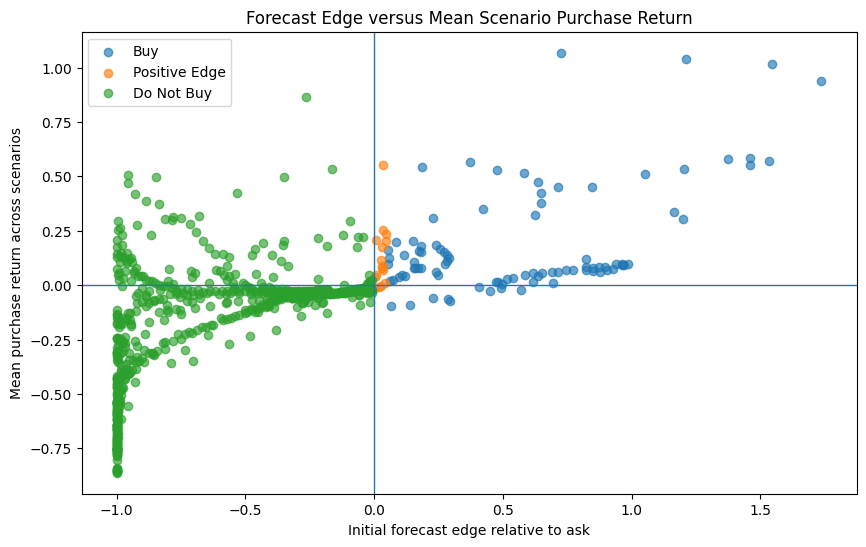

In [45]:
action_order = [
    "Buy",
    "Positive Edge",
    "Do Not Buy",
]

plt.figure(figsize=(10, 6))

for action in action_order:
    action_rows = (
        contract_scenario_summary.loc[
            contract_scenario_summary[
                "Initial Recommended Action"
            ].eq(action)
        ]
    )

    if action_rows.empty:
        continue

    plt.scatter(
        action_rows[
            "Forecast Edge Return"
        ],
        action_rows[
            "Mean_Purchase_Return"
        ],
        alpha=0.65,
        label=action,
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel(
    "Initial forecast edge relative to ask"
)
plt.ylabel(
    "Mean purchase return across scenarios"
)
plt.title(
    "Forecast Edge versus Mean Scenario Purchase Return"
)
plt.legend()
plt.show()

### Forecast edge versus average scenario return

The plot shows a positive but highly dispersed relationship between forecast
edge and average scenario purchase return.

Many initial `Buy` contracts appear in the upper-right region. However, several
positive-edge contracts still produce weak or negative mean outcomes, while
some `Do Not Buy` contracts generate positive average returns.

The forecast signal contains useful cross-sectional information, but strike,
option type, purchase premium and exposure to the generated shocks materially
change the result after the initial valuation comparison.

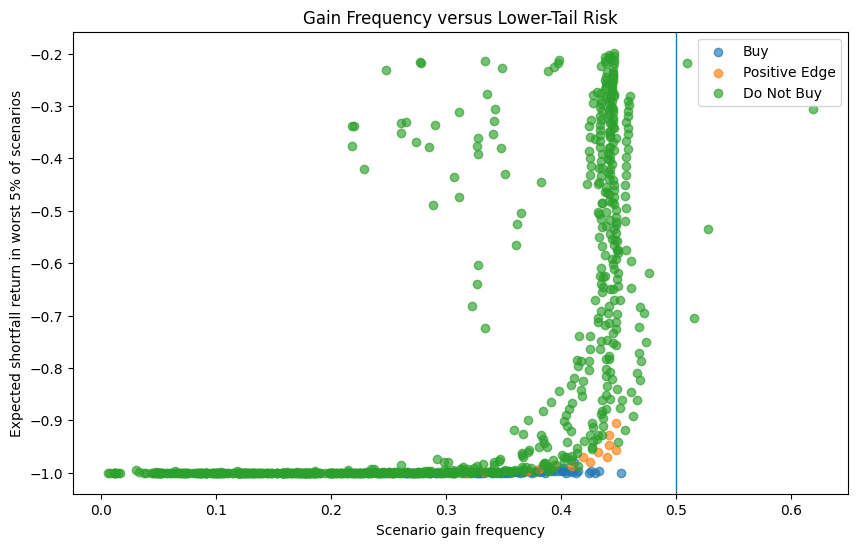

In [46]:
plt.figure(figsize=(10, 6))

for action in action_order:
    action_rows = (
        contract_scenario_summary.loc[
            contract_scenario_summary[
                "Initial Recommended Action"
            ].eq(action)
        ]
    )

    if action_rows.empty:
        continue

    plt.scatter(
        action_rows[
            "Scenario_Profit_Frequency"
        ],
        action_rows[
            "Expected_Shortfall_5pct_Return"
        ],
        alpha=0.65,
        label=action,
    )

plt.axvline(
    CANDIDATE_PROFIT_FREQUENCY,
    linewidth=1,
)

plt.xlabel(
    "Scenario gain frequency"
)

plt.ylabel(
    "Expected shortfall return in worst 5% of scenarios"
)

plt.title(
    "Gain Frequency versus Lower-Tail Risk"
)

plt.legend()
plt.show()

### Outcome consistency remained the main weakness

The initial `Buy` observations remain below the 50% scenario gain-frequency
line later required by the Candidate rule. At the same time, many expected-
shortfall returns are close to -100%, showing that the lower tail can contain
near-total premium losses.

This does not invalidate the positive mean returns of several contracts. It
shows that those returns arise from asymmetric distributions: large gains in
favourable states offset losses in a greater number of generated states.

The final classification must therefore distinguish contracts with interesting
upside from contracts with enough consistency to justify the stronger
Candidate label.

In [47]:
store.write_frame(
    contract_scenario_summary,
    "contract_scenario_summary",
    run_id=run_id,
)

store.write_frame(
    initial_action_comparison,
    "initial_action_comparison",
    run_id=run_id,
)

contract_scenario_summary.to_csv(
    TABLE_DIR
    / "contract_scenario_summary.csv",
    index=False,
)

initial_action_comparison.to_csv(
    TABLE_DIR
    / "initial_action_comparison.csv",
    index=False,
)

print(
    "Stored contract summaries:",
    len(contract_scenario_summary),
)

print(
    "Stored recommendation groups:",
    len(initial_action_comparison),
)

2026-08-02 13:39:44,660 - options_risk_engine.database - INFO - Stored 794 rows in contract_scenario_summary
2026-08-02 13:39:44,665 - options_risk_engine.database - INFO - Stored 3 rows in initial_action_comparison


Stored contract summaries: 794
Stored recommendation groups: 3


### Section 19 result

Section 19 reduced 794,794 scenario rows to one complete outcome profile for
each of the 794 contracts.

The initial screen was informative for average return, particularly among
selected puts, but did not provide uniform dominance across gain frequency and
lower-tail risk.

The main findings are:

- `Buy` contracts have substantially stronger forecast valuation;
- several `Buy` puts have the highest average scenario returns;
- some `Do Not Buy` contracts have high gain frequencies or controlled
  percentage downside;
- many strong forecast-edge contracts retain near-total premium loss in the
  lower tail; and
- no initial `Buy` contract reaches the later 50% Candidate gain-frequency
  requirement.

The next section explains which Greek exposures generated these patterns.

# 20. Contract-level Greek attribution and risk explanation

Section 19 measured the outcome distribution of each standardised contract.
This section explains which market-risk factors generated those outcomes.

The existing Greek attribution engine decomposes the movement from the base
market-IV model value to the shocked scenario value into:

- Delta P&L from changes in the underlying share price;
- Gamma P&L from nonlinear spot exposure;
- Vega P&L from volatility changes;
- Theta P&L from the passage of time; and
- Rho P&L from interest-rate changes.

The initial difference between the ask and the base model value is not included
in this decomposition. Any difference between full repricing and the fixed-
Greek approximation remains as residual P&L. Large residuals indicate that
initial Greeks do not adequately describe the contract under larger shocks.

In [48]:
from options_risk_engine.recommendations.attribution import (
    create_contract_attribution_results,
    create_contract_attribution_summary,
    create_contract_driver_comparison,
    validate_contract_attribution_summary,
)

contract_attribution_results = (
    create_contract_attribution_results(
        scenario_results=(
            raw_contract_scenario_results
        ),
        positions=standardised_contracts,
    )
)

print(
    "Contract-attribution rows:",
    len(contract_attribution_results),
)

print(
    "Contracts:",
    contract_attribution_results[
        "Contract Symbol"
    ].nunique(),
)

print(
    "Scenarios:",
    contract_attribution_results[
        "Scenario ID"
    ].nunique(),
)

2026-08-02 13:39:44,911 - options_risk_engine.risk.attribution - INFO - Starting Greek P&L attribution
2026-08-02 13:39:45,339 - options_risk_engine.risk.attribution - INFO - Greek attribution accounting check passed
2026-08-02 13:39:45,339 - options_risk_engine.risk.attribution - INFO - Greek attribution completed for 794794 position-scenario rows and 1001 scenarios
2026-08-02 13:39:45,340 - options_risk_engine.recommendations.attribution - INFO - Calculated Greek attribution for 794794 contract-scenario rows


Contract-attribution rows: 794794
Contracts: 794
Scenarios: 1001


`Scenario PnL` is the full-revaluation movement from the base model value.
`Approximate PnL` is the sum of the five Greek components.

Residual percentage can be unstable when scenario movement is close to zero,
so the contract summary also uses gross residual ratios based on absolute P&L.

In [49]:
contract_attribution_summary = (
    create_contract_attribution_summary(
        attribution_results=(
            contract_attribution_results
        ),
        contract_scenario_summary=(
            contract_scenario_summary
        ),
        base_scenario_id=BASE_SCENARIO_ID,
        local_spot_limit=LOCAL_SPOT_LIMIT,
        local_volatility_limit=(
            LOCAL_VOLATILITY_LIMIT
        ),
        local_days_limit=LOCAL_DAYS_LIMIT,
        local_rate_limit=LOCAL_RATE_LIMIT,
        minimum_local_scenarios=(
            MINIMUM_LOCAL_SCENARIOS
        ),
    )
)

print(
    "Contracts attributed:",
    len(contract_attribution_summary),
)

attribution_display_columns = [
    "Contract Symbol",
    "Ticker",
    "Option Type",
    "strike",
    "Initial Recommended Action",
    "Forecast Edge Return",
    "Mean_Purchase_Return",
    "Scenario_Profit_Frequency",
    "Expected_Shortfall_5pct_Return",
    "Risk Driver",
    "Dominant Greek",
    "Dominant Driver Share",
    "Mean_Delta_Return",
    "Mean_Gamma_Return",
    "Mean_Vega_Return",
    "Mean_Theta_Return",
    "Mean_Rho_Return",
    "Gross_Residual_Ratio",
    "Local_Scenario_Count",
    "Local_Gross_Residual_Ratio",
    "Attribution Reliability",
]

available_attribution_columns = [
    column
    for column in attribution_display_columns
    if column in contract_attribution_summary.columns
]

display(
    contract_attribution_summary[
        available_attribution_columns
    ]
    .head(10)
    .round(4)
)

display(
    contract_attribution_summary[
        available_attribution_columns
    ]
    .tail(10)
    .round(4)
)

2026-08-02 13:39:47,192 - options_risk_engine.recommendations.attribution - INFO - Created Greek attribution summaries for 794 contracts


Contracts attributed: 794


,Contract Symbol,Ticker,Option Type,strike,Initial Recommended Action,Forecast Edge Return,Mean_Purchase_Return,Scenario_Profit_Frequency,Expected_Shortfall_5pct_Return,Risk Driver,Dominant Greek,Dominant Driver Share,Mean_Delta_Return,Mean_Gamma_Return,Mean_Vega_Return,Mean_Theta_Return,Mean_Rho_Return,Gross_Residual_Ratio,Local_Scenario_Count,Local_Gross_Residual_Ratio,Attribution Reliability
0,WMT260918P00092500,WMT,Puts,92.5,Buy,0.7239,1.0681,0.272,-1.0,Mixed,Gamma,0.3958,0.0687,2.7114,-0.0758,-1.5131,-0.0009,0.7534,66,0.4409,Low
1,WMT260918P00095000,WMT,Puts,95.0,Buy,1.2096,1.0397,0.287,-1.0,Convexity,Gamma,0.4199,0.0732,3.0101,-0.0699,-1.4668,-0.0009,0.7164,66,0.4120,Low
2,WMT260918P00097500,WMT,Puts,97.5,Buy,1.5436,1.0168,0.329,-1.0,Convexity,Gamma,0.4261,0.0863,3.3895,-0.0644,-1.5698,-0.0011,0.8544,66,0.3548,Low
3,WMT260918P00100000,WMT,Puts,100.0,Buy,1.7364,0.9378,0.350,-1.0,Convexity,Gamma,0.4641,0.1120,4.6347,-0.0501,-1.7971,-0.0014,1.4895,66,0.3910,Low
4,MSFT260918P00415000,MSFT,Puts,415.0,Buy,1.4597,0.5846,0.341,-1.0,Mixed,Gamma,0.3767,0.0680,2.0721,-0.0458,-1.1170,-0.0009,0.6347,66,0.2388,Moderate
5,MSFT260918P00410000,MSFT,Puts,410.0,Buy,1.3745,0.5801,0.330,-1.0,Mixed,Gamma,0.3650,0.0645,1.9358,-0.0488,-1.1222,-0.0008,0.5678,66,0.2468,Moderate
6,MSFT260918P00425000,MSFT,Puts,425.0,Buy,1.5334,0.5708,0.356,-1.0,Mixed,Gamma,0.4003,0.0830,2.5448,-0.0356,-1.1934,-0.0010,0.9373,66,0.2441,Moderate
7,AAPL260918P00275000,AAPL,Puts,275.0,Buy,0.3720,0.5679,0.353,-1.0,Mixed,Delta,0.3582,0.0487,1.2197,-0.0463,-0.6708,-0.0006,0.3547,66,0.1656,Moderate
8,MSFT260918P00420000,MSFT,Puts,420.0,Buy,1.4596,0.5506,0.344,-1.0,Mixed,Gamma,0.3874,0.0719,2.1999,-0.0410,-1.1100,-0.0009,0.7406,66,0.2341,Moderate
9,AAPL260918P00270000,AAPL,Puts,270.0,Buy,0.1865,0.5408,0.333,-1.0,Mixed,Delta,0.3465,0.0475,1.2115,-0.0490,-0.7154,-0.0006,0.4097,66,0.1901,Moderate


,Contract Symbol,Ticker,Option Type,strike,Initial Recommended Action,Forecast Edge Return,Mean_Purchase_Return,Scenario_Profit_Frequency,Expected_Shortfall_5pct_Return,Risk Driver,Dominant Greek,Dominant Driver Share,Mean_Delta_Return,Mean_Gamma_Return,Mean_Vega_Return,Mean_Theta_Return,Mean_Rho_Return,Gross_Residual_Ratio,Local_Scenario_Count,Local_Gross_Residual_Ratio,Attribution Reliability
784,AMZN260918P00260000,AMZN,Puts,260.0,Positive Edge,0.0244,0.1143,0.394,-0.9859,Directional,Delta,0.4880,0.0272,0.3514,-0.0193,-0.2245,-0.0004,0.1253,66,0.0312,High
785,AMZN260918P00270000,AMZN,Puts,270.0,Positive Edge,0.0307,0.0891,0.419,-0.9709,Directional,Delta,0.5444,0.0241,0.2517,-0.0137,-0.1539,-0.0003,0.0902,66,0.0164,High
786,AMZN260918P00275000,AMZN,Puts,275.0,Positive Edge,0.0313,0.0797,0.432,-0.9596,Directional,Delta,0.5750,0.0226,0.2098,-0.0113,-0.1252,-0.0003,0.0805,66,0.0152,High
787,AMZN260918P00280000,AMZN,Puts,280.0,Positive Edge,0.0338,0.0697,0.442,-0.9473,Directional,Delta,0.6074,0.0213,0.1754,-0.0093,-0.0993,-0.0003,0.0737,66,0.0185,High
788,AMZN260918P00285000,AMZN,Puts,285.0,Positive Edge,0.0085,0.0453,0.442,-0.9272,Directional,Delta,0.6401,0.0194,0.1376,-0.0074,-0.0784,-0.0003,0.0690,66,0.0215,High
789,AMZN260918P00290000,AMZN,Puts,290.0,Positive Edge,0.0016,0.0360,0.448,-0.9046,Directional,Delta,0.6733,0.0179,0.1101,-0.0060,-0.0614,-0.0002,0.0661,66,0.0234,High
790,AMZN260918C00270000,AMZN,Calls,270.0,Positive Edge,0.0413,0.0077,0.410,-0.9865,Directional,Delta,0.5871,-0.0249,0.2074,-0.0111,-0.1519,0.0003,0.0811,66,0.0150,High
791,AMZN260918C00265000,AMZN,Calls,265.0,Positive Edge,0.0249,-0.0036,0.425,-0.9796,Directional,Delta,0.6202,-0.0231,0.1657,-0.0089,-0.1237,0.0003,0.0741,66,0.0145,High
792,AMZN260918C00260000,AMZN,Calls,260.0,Positive Edge,0.0181,-0.0069,0.440,-0.9703,Directional,Delta,0.6551,-0.0215,0.1314,-0.0071,-0.1001,0.0002,0.0693,66,0.0160,High
793,AMZN260918C00255000,AMZN,Calls,255.0,Positive Edge,0.0041,-0.0142,0.448,-0.9569,Directional,Delta,0.6902,-0.0197,0.1005,-0.0055,-0.0804,0.0002,0.0656,66,0.0180,High


### Interpreting the risk driver

The driver label identifies the largest source of average absolute
Greek-attributed movement:

- `Directional` means Delta dominates;
- `Convexity` means Gamma dominates;
- `Volatility` means Vega dominates;
- `Time Decay` means Theta dominates;
- `Interest Rate` means Rho dominates; and
- `Mixed` means no single component clearly dominates.

The label does not determine whether a contract is attractive. It explains
what market behaviour the trade depends upon.

In [50]:
contract_attribution_checks = (
    validate_contract_attribution_summary(
        summary=contract_attribution_summary,
        original_contract_summary=(
            contract_scenario_summary
        ),
    )
)

display(
    pd.Series(
        contract_attribution_checks,
        name="Passed",
    )
    .to_frame()
)

2026-08-02 13:39:47,245 - options_risk_engine.recommendations.attribution - INFO - All contract attribution checks passed


,Passed
same_number_of_contracts,True
unique_contract_symbols,True
movement_matches_section_19,True
greek_attribution_identity,True
purchase_pnl_identity,True
driver_shares_sum_to_one,True
driver_shares_valid,True
recognised_risk_drivers,True
recognised_reliability_labels,True


### Attribution reconciliation

All contract-attribution checks passed.

For every contract, the initial purchase-price difference, subsequent market
movement and Greek explanation remain distinct but reconcile correctly.

The reliability label must still be respected. A low residual under smaller
local shocks supports the Greek explanation, while full repricing remains the
authoritative result for the larger stresses.

In [51]:
contract_driver_comparison = (
    create_contract_driver_comparison(
        contract_attribution_summary
    )
)

display(
    contract_driver_comparison.round(4)
)

,Initial Recommended Action,Risk Driver,Contracts,Median_Mean_Purchase_Return,Median_Profit_Frequency,Median_Expected_Shortfall,Median_All_Scenario_Residual,Median_Local_Residual
0,Buy,Convexity,3,1.0168,0.3290,-1.0000,0.8544,0.3910
1,Buy,Directional,36,0.0711,0.3880,-0.9976,0.1524,0.0396
2,Buy,Mixed,52,0.0979,0.2930,-1.0000,0.5367,0.2225
3,Do Not Buy,Directional,371,-0.0293,0.4350,-0.5841,0.0719,0.0185
4,Do Not Buy,Mixed,251,-0.2553,0.1840,-1.0000,0.7644,0.2603
5,Do Not Buy,Time Decay,65,-0.7343,0.0620,-1.0000,1.0979,0.3587
6,Positive Edge,Directional,12,0.0575,0.4285,-0.9706,0.0773,0.0183
7,Positive Edge,Mixed,4,0.2460,0.2855,-1.0000,0.5708,0.2535


### Observed drivers within the initial recommendations

The initial `Buy` group is not dominated by a single volatility label.

Of the 91 initial `Buy` contracts:

- 52 are classified as `Mixed`;
- 36 are `Directional`; and
- 3 are `Convexity`.

The `Positive Edge` group contains 12 Directional and 4 Mixed contracts. The
`Do Not Buy` group contains 371 Directional, 251 Mixed and 65 Time Decay
contracts.

The original valuation signal is based on forecast volatility, yet the broad
scenario outcomes are mainly explained by combinations of Delta, Gamma and
Theta or by directional Delta exposure. Vega remains economically relevant,
but it is not the largest average absolute component under this run's common
shocks.

In [52]:
initial_buy_attribution = (
    contract_attribution_summary.loc[
        contract_attribution_summary[
            "Initial Recommended Action"
        ].eq("Buy")
    ]
    .sort_values(
        [
            "Mean_Purchase_Return",
            "Scenario_Profit_Frequency",
        ],
        ascending=[
            False,
            False,
        ],
    )
)

display(
    initial_buy_attribution[
        [
            "Contract Symbol",
            "Ticker",
            "Option Type",
            "strike",
            "Forecast Edge Return",
            "Mean_Purchase_Return",
            "Scenario_Profit_Frequency",
            "Expected_Shortfall_5pct_Return",
            "Risk Driver",
            "Dominant Driver Share",
            "Mean_Delta_Return",
            "Mean_Gamma_Return",
            "Mean_Vega_Return",
            "Mean_Theta_Return",
            "Gross_Residual_Ratio",
            "Local_Gross_Residual_Ratio",
            "Attribution Reliability",
        ]
    ]
    .head(25)
    .round(4)
)

,Contract Symbol,Ticker,Option Type,strike,Forecast Edge Return,Mean_Purchase_Return,Scenario_Profit_Frequency,Expected_Shortfall_5pct_Return,Risk Driver,Dominant Driver Share,Mean_Delta_Return,Mean_Gamma_Return,Mean_Vega_Return,Mean_Theta_Return,Gross_Residual_Ratio,Local_Gross_Residual_Ratio,Attribution Reliability
0,WMT260918P00092500,WMT,Puts,92.5,0.7239,1.0681,0.272,-1.000,Mixed,0.3958,0.0687,2.7114,-0.0758,-1.5131,0.7534,0.4409,Low
1,WMT260918P00095000,WMT,Puts,95.0,1.2096,1.0397,0.287,-1.000,Convexity,0.4199,0.0732,3.0101,-0.0699,-1.4668,0.7164,0.4120,Low
2,WMT260918P00097500,WMT,Puts,97.5,1.5436,1.0168,0.329,-1.000,Convexity,0.4261,0.0863,3.3895,-0.0644,-1.5698,0.8544,0.3548,Low
3,WMT260918P00100000,WMT,Puts,100.0,1.7364,0.9378,0.350,-1.000,Convexity,0.4641,0.1120,4.6347,-0.0501,-1.7971,1.4895,0.3910,Low
4,MSFT260918P00415000,MSFT,Puts,415.0,1.4597,0.5846,0.341,-1.000,Mixed,0.3767,0.0680,2.0721,-0.0458,-1.1170,0.6347,0.2388,Moderate
5,MSFT260918P00410000,MSFT,Puts,410.0,1.3745,0.5801,0.330,-1.000,Mixed,0.3650,0.0645,1.9358,-0.0488,-1.1222,0.5678,0.2468,Moderate
6,MSFT260918P00425000,MSFT,Puts,425.0,1.5334,0.5708,0.356,-1.000,Mixed,0.4003,0.0830,2.5448,-0.0356,-1.1934,0.9373,0.2441,Moderate
7,AAPL260918P00275000,AAPL,Puts,275.0,0.3720,0.5679,0.353,-1.000,Mixed,0.3582,0.0487,1.2197,-0.0463,-0.6708,0.3547,0.1656,Moderate
8,MSFT260918P00420000,MSFT,Puts,420.0,1.4596,0.5506,0.344,-1.000,Mixed,0.3874,0.0719,2.1999,-0.0410,-1.1100,0.7406,0.2341,Moderate
9,AAPL260918P00270000,AAPL,Puts,270.0,0.1865,0.5408,0.333,-1.000,Mixed,0.3465,0.0475,1.2115,-0.0490,-0.7154,0.4097,0.1901,Moderate


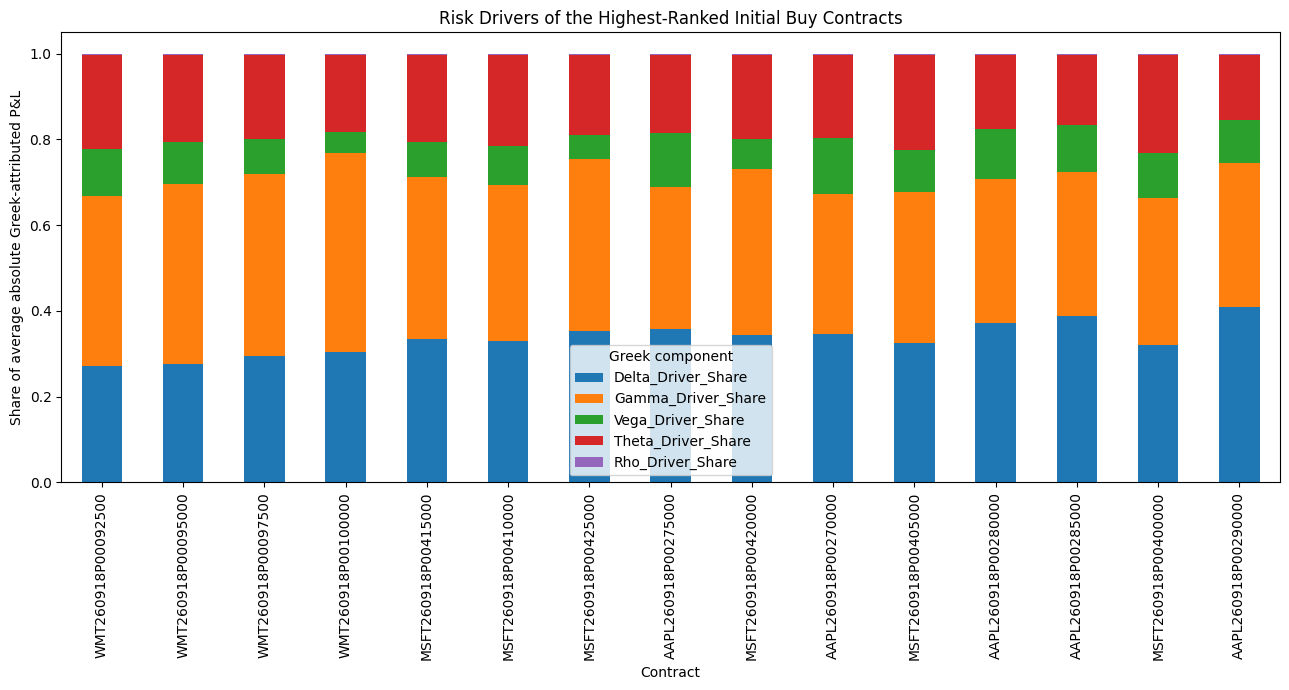

In [53]:
driver_plot_data = (
    initial_buy_attribution
    .head(15)
    .set_index(
        "Contract Symbol"
    )
    [
        [
            "Delta_Driver_Share",
            "Gamma_Driver_Share",
            "Vega_Driver_Share",
            "Theta_Driver_Share",
            "Rho_Driver_Share",
        ]
    ]
)

driver_plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7),
)

plt.ylabel(
    "Share of average absolute Greek-attributed P&L"
)

plt.xlabel(
    "Contract"
)

plt.title(
    "Risk Drivers of the Highest-Ranked Initial Buy Contracts"
)

plt.legend(
    title="Greek component"
)

plt.tight_layout()
plt.show()

### Risk composition of the strongest initial Buy contracts

The highest-ranked initial `Buy` contracts display material exposure to several
Greek components rather than one isolated driver.

Delta and Gamma account for the largest portions of most bars, confirming
dependence on both the direction and size of the underlying move. Theta also
forms a meaningful part of the risk profile, while Vega contributes a smaller
but visible share. Rho is negligible under the tested rate shocks.

A volatility view implemented through an option therefore still creates
directional, convexity and timing exposure.

In [54]:
store.write_frame(
    contract_attribution_summary,
    "contract_attribution_summary",
    run_id=run_id,
)

store.write_frame(
    contract_driver_comparison,
    "contract_driver_comparison",
    run_id=run_id,
)

contract_attribution_summary.to_csv(
    TABLE_DIR
    / "contract_attribution_summary.csv",
    index=False,
)

contract_driver_comparison.to_csv(
    TABLE_DIR
    / "contract_driver_comparison.csv",
    index=False,
)

print(
    "Stored contract attribution summaries:",
    len(contract_attribution_summary),
)

print(
    "Stored driver comparison rows:",
    len(contract_driver_comparison),
)

2026-08-02 13:39:47,688 - options_risk_engine.database - INFO - Stored 794 rows in contract_attribution_summary
2026-08-02 13:39:47,694 - options_risk_engine.database - INFO - Stored 8 rows in contract_driver_comparison


Stored contract attribution summaries: 794
Stored driver comparison rows: 8


### Section 20 result

Every contract now has both an outcome profile and an explanation of the risks
that generated it.

The initial `Buy` contracts were mainly Mixed or Directional rather than purely
volatility-driven. Their outcomes depend on the interaction between Delta,
Gamma, Vega, Theta and the initial cost of paying the ask.

The three Convexity-driven `Buy` contracts produced the strongest grouped
median mean return, while the much larger Mixed and Directional groups produced
more moderate outcomes.

Greek attribution provides economic explanation but does not replace full
repricing. The final ranking therefore uses the scenario distribution for
scoring and the Greek analysis for interpretation.

# 21. Final risk-aware contract ranking

The initial recommendation classified contracts using forecast-volatility
valuation, quote validity and eligibility. Sections 18–20 then evaluated every
contract on identical purchase terms, summarised its scenario distribution and
identified the risks responsible for its outcomes.

This section combines:

- forecast valuation edge;
- average and median scenario purchase return;
- scenario gain frequency;
- lower-tail risk; and
- liquidity.

Hard rejection rules are applied before selection. Contracts with insufficient
market quality become `Liquidity Rejection`. Contracts combining unusually
weak lower-tail outcomes with low gain frequency become `Risk Rejection`.

The remaining contracts may become `Candidate`, `Watchlist` or `No Trade`.
The score ranks contracts relative to the current universe; it is not a
calibrated probability of profit or a substitute for a historical
out-of-sample backtest.

In [55]:
from options_risk_engine.recommendations.ranking import (
    create_final_contract_ranking,
    create_final_recommendation_summary,
    validate_final_contract_ranking,
)

final_contract_ranking = (
    create_final_contract_ranking(
        contract_summary=(
            contract_attribution_summary
        ),
        max_spread_pct=(
            FINAL_MAX_SPREAD_PCT
        ),
        min_volume=FINAL_MIN_VOLUME,
        min_open_interest=(
            FINAL_MIN_OPEN_INTEREST
        ),
        candidate_score=CANDIDATE_SCORE,
        watchlist_score=WATCHLIST_SCORE,
        candidate_profit_frequency=(
            CANDIDATE_PROFIT_FREQUENCY
        ),
        minimum_mean_return=(
            MINIMUM_MEAN_RETURN
        ),
        risk_tail_quantile=(
            RISK_TAIL_QUANTILE
        ),
        risk_profit_frequency=(
            RISK_PROFIT_FREQUENCY
        ),
        score_weights=FINAL_SCORE_WEIGHTS,
    )
)

print(
    "Contracts ranked:",
    len(final_contract_ranking),
)

display(
    final_contract_ranking[
        "Final Recommended Action"
    ]
    .value_counts()
    .rename("Contracts")
    .to_frame()
)

2026-08-02 13:39:47,867 - options_risk_engine.recommendations.ranking - INFO - Created final rankings for 794 contracts


Contracts ranked: 794


,Contracts
Final Recommended Action,
Liquidity Rejection,462
No Trade,252
Watchlist,57
Risk Rejection,23


### Observed final classifications

The final engine ranked 794 contracts but did not assign the `Candidate`
classification to any contract.

The output contains:

- 57 `Watchlist` contracts;
- 252 `No Trade` contracts;
- 23 `Risk Rejection` contracts; and
- 462 `Liquidity Rejection` contracts.

Liquidity is the largest source of exclusion, removing approximately 58.2% of
the universe. An attractive theoretical value is therefore not sufficient when
spread, volume or open interest does not support a sufficiently tradeable
quote.

The absence of Candidates is not a validation failure. It means no initial
`Buy` contract simultaneously satisfied the score, liquidity, risk,
positive-mean-return and 50% scenario gain-frequency requirements.

In [56]:
final_ranking_checks = (
    validate_final_contract_ranking(
        ranking=final_contract_ranking,
        max_spread_pct=(
            FINAL_MAX_SPREAD_PCT
        ),
        min_volume=FINAL_MIN_VOLUME,
        min_open_interest=(
            FINAL_MIN_OPEN_INTEREST
        ),
        candidate_score=CANDIDATE_SCORE,
        watchlist_score=WATCHLIST_SCORE,
        candidate_profit_frequency=(
            CANDIDATE_PROFIT_FREQUENCY
        ),
        minimum_mean_return=(
            MINIMUM_MEAN_RETURN
        ),
        risk_tail_quantile=(
            RISK_TAIL_QUANTILE
        ),
        risk_profit_frequency=(
            RISK_PROFIT_FREQUENCY
        ),
        score_weights=FINAL_SCORE_WEIGHTS,
    )
)

display(
    pd.Series(
        final_ranking_checks,
        name="Passed",
    )
    .to_frame()
)

2026-08-02 13:39:47,889 - options_risk_engine.recommendations.ranking - INFO - All final ranking checks passed


,Passed
contracts_available,True
unique_contract_symbols,True
scores_between_zero_and_one_hundred,True
weighted_score_matches,True
recognised_final_actions,True
liquidity_gate_matches,True
risk_gate_matches,True
candidate_rules_hold,True
watchlist_rules_hold,True
do_not_buy_not_promoted,True


All final-ranking checks passed. The score matches the declared weights, the
hard gates are applied consistently and no `Do Not Buy` contract can be
promoted to the final shortlist.

In [57]:
final_recommendation_summary = (
    create_final_recommendation_summary(
        final_contract_ranking
    )
)

display(
    final_recommendation_summary.round(4)
)

initial_to_final_comparison = pd.crosstab(
    final_contract_ranking[
        "Initial Recommended Action"
    ],
    final_contract_ranking[
        "Final Recommended Action"
    ],
    margins=True,
)

display(
    initial_to_final_comparison
)

,Final Recommended Action,Contracts,Median_Final_Score,Median_Forecast_Edge,Median_Mean_Return,Median_Profit_Frequency,Median_Expected_Shortfall,Median_Spread,Most_Common_Risk_Driver
0,Watchlist,57,68.3505,0.2903,0.0945,0.381,-0.9979,0.0635,Directional
1,No Trade,252,59.5572,-0.3495,-0.0286,0.435,-0.7947,0.0461,Directional
2,Risk Rejection,23,59.2412,0.8493,0.1508,0.285,-0.9999,0.1166,Mixed
3,Liquidity Rejection,462,34.2989,-0.9021,-0.1268,0.216,-0.9999,0.3834,Mixed


Final Recommended Action,Liquidity Rejection,No Trade,Risk Rejection,Watchlist,All
Initial Recommended Action,,,,,
Buy,26,0,17,48,91
Do Not Buy,432,249,6,0,687
Positive Edge,4,3,0,9,16
All,462,252,23,57,794


### How the initial labels changed

Of the 91 initial `Buy` contracts:

- 48, approximately 52.7%, became `Watchlist`;
- 17, approximately 18.7%, became `Risk Rejection`; and
- 26, approximately 28.6%, became `Liquidity Rejection`.

None became `Candidate`.

Of the 16 `Positive Edge` contracts, 9 reached the Watchlist, 3 became
`No Trade` and 4 failed the liquidity gate.

The 687 `Do Not Buy` contracts remained outside the shortlist. The second-stage
process therefore did not promote contracts lacking the required initial
forecast valuation.

In [58]:
final_contract_shortlist = (
    final_contract_ranking.loc[
        final_contract_ranking[
            "Final Recommended Action"
        ].isin(
            [
                "Candidate",
                "Watchlist",
            ]
        )
    ]
    .sort_values(
        "Final Shortlist Rank"
    )
    .copy()
)

final_display_columns = [
    "Final Shortlist Rank",
    "Ticker Shortlist Rank",
    "Contract Symbol",
    "Ticker",
    "Option Type",
    "strike",
    "Expiry",
    "Initial Recommended Action",
    "Final Recommended Action",
    "Final Score",
    "ask",
    "Premium Paid",
    "Forecast Edge Return",
    "Mean_Purchase_Return",
    "Median_Purchase_Return",
    "Scenario_Profit_Frequency",
    "Fifth_Percentile_Purchase_Return",
    "Expected_Shortfall_5pct_Return",
    "SpreadPct",
    "volume",
    "openInterest",
    "Risk Driver",
    "Dominant Driver Share",
    "Attribution Reliability",
    "Final Recommendation Reason",
]

available_final_columns = [
    column
    for column in final_display_columns
    if column in final_contract_shortlist.columns
]

display(
    final_contract_shortlist[
        available_final_columns
    ]
    .head(30)
    .round(4)
)

,Final Shortlist Rank,Ticker Shortlist Rank,Contract Symbol,Ticker,Option Type,strike,Expiry,Initial Recommended Action,Final Recommended Action,Final Score,ask,Premium Paid,Forecast Edge Return,Mean_Purchase_Return,Median_Purchase_Return,Scenario_Profit_Frequency,Fifth_Percentile_Purchase_Return,Expected_Shortfall_5pct_Return,SpreadPct,volume,openInterest,Risk Driver,Dominant Driver Share,Attribution Reliability,Final Recommendation Reason
0,1,1,AMZN260918P00280000,AMZN,Puts,280.0,2026-09-18,Positive Edge,Watchlist,71.0192,16.70,1670.0,0.0338,0.0697,-0.1231,0.442,-0.8901,-0.9473,0.0397,175.0,1868.0,Directional,0.6074,High,"Positive valuation and scenario evidence, but ..."
1,2,1,GOOGL260918P00350000,GOOGL,Puts,350.0,2026-09-18,Buy,Watchlist,70.6243,13.30,1330.0,0.2903,0.1267,-0.2861,0.407,-0.9887,-0.9969,0.0620,1175.0,3929.0,Directional,0.5176,High,"Positive valuation and scenario evidence, but ..."
2,3,2,AMZN260918P00265000,AMZN,Puts,265.0,2026-09-18,Buy,Watchlist,70.6213,9.00,900.0,0.0573,0.1229,-0.2355,0.411,-0.9520,-0.9803,0.0397,2167.0,684.0,Directional,0.5146,High,"Positive valuation and scenario evidence, but ..."
3,4,3,AMZN260918P00270000,AMZN,Puts,270.0,2026-09-18,Positive Edge,Watchlist,70.5293,11.45,1145.0,0.0307,0.0891,-0.2031,0.419,-0.9319,-0.9709,0.0538,1409.0,1783.0,Directional,0.5444,High,"Positive valuation and scenario evidence, but ..."
4,5,4,AMZN260918P00275000,AMZN,Puts,275.0,2026-09-18,Positive Edge,Watchlist,70.4242,13.95,1395.0,0.0313,0.0797,-0.1571,0.432,-0.9128,-0.9596,0.0402,541.0,641.0,Directional,0.5750,High,"Positive valuation and scenario evidence, but ..."
5,6,2,GOOGL260918P00355000,GOOGL,Puts,355.0,2026-09-18,Buy,Watchlist,70.3392,15.65,1565.0,0.2819,0.1105,-0.2448,0.415,-0.9875,-0.9965,0.0558,909.0,1677.0,Directional,0.5480,High,"Positive valuation and scenario evidence, but ..."
6,7,5,AMZN260918P00255000,AMZN,Puts,255.0,2026-09-18,Buy,Watchlist,70.1573,5.55,555.0,0.0518,0.1596,-0.3257,0.390,-0.9756,-0.9909,0.0651,2165.0,2681.0,Directional,0.4614,High,"Positive valuation and scenario evidence, but ..."
7,8,6,AMZN260918C00270000,AMZN,Calls,270.0,2026-09-18,Positive Edge,Watchlist,69.9934,14.10,1410.0,0.0413,0.0077,-0.2050,0.410,-0.9554,-0.9865,0.0361,11317.0,23076.0,Directional,0.5871,High,"Positive valuation and scenario evidence, but ..."
8,9,7,AMZN260918P00250000,AMZN,Puts,250.0,2026-09-18,Positive Edge,Watchlist,69.7935,4.30,430.0,0.0295,0.1772,-0.3818,0.381,-0.9833,-0.9938,0.0723,4331.0,4895.0,Directional,0.4385,High,"Positive valuation and scenario evidence, but ..."
9,10,3,GOOGL260918P00360000,GOOGL,Puts,360.0,2026-09-18,Buy,Watchlist,69.7758,18.20,1820.0,0.2749,0.0949,-0.2181,0.426,-0.9890,-0.9970,0.0565,190.0,2088.0,Directional,0.5854,High,"Positive valuation and scenario evidence, but ..."


### Composition of the final Watchlist

The 57-contract Watchlist is strongly concentrated by ticker and option type:

- 19 META puts;
- 13 GOOGL puts;
- 9 AMZN puts;
- 7 AMZN calls;
- 7 AAPL puts;
- 1 MSFT put; and
- 1 WMT put.

No HCA contract reached the final shortlist.

The highest ranks are led by the AMZN 280 put, GOOGL 350 put and AMZN puts at
strikes 265, 270 and 275. The concentration indicates clusters of adjacent
strikes with similar exposures rather than 57 independent trading ideas.

Ticker and strike concentration must therefore be considered before treating
the Watchlist as a portfolio.

In [59]:
final_candidates = (
    final_contract_ranking.loc[
        final_contract_ranking[
            "Final Recommended Action"
        ].eq("Candidate")
    ]
    .sort_values(
        "Final Shortlist Rank"
    )
    .copy()
)

print(
    "Final Candidates:",
    len(final_candidates),
)

display(
    final_candidates[
        available_final_columns
    ]
    .head(20)
    .round(4)
)

Final Candidates: 0


,Final Shortlist Rank,Ticker Shortlist Rank,Contract Symbol,Ticker,Option Type,strike,Expiry,Initial Recommended Action,Final Recommended Action,Final Score,ask,Premium Paid,Forecast Edge Return,Mean_Purchase_Return,Median_Purchase_Return,Scenario_Profit_Frequency,Fifth_Percentile_Purchase_Return,Expected_Shortfall_5pct_Return,SpreadPct,volume,openInterest,Risk Driver,Dominant Driver Share,Attribution Reliability,Final Recommendation Reason


### Why no contract became a Candidate

The empty Candidate table is the correct output under the declared rules.

Several contracts achieved high relative scores, but Candidate status also
requires an initial `Buy` label and a scenario gain frequency of at least 50%.
The Section 19 results show that the initial `Buy` observations remained below
that consistency threshold.

Their positive mean returns are generated by asymmetric upside rather than
gains in a majority of generated states. This is sufficient for 48 initial
`Buy` contracts to remain on the Watchlist, but not enough for the stronger
Candidate classification.

The thresholds should not be relaxed merely to force a positive
recommendation. Alternative values belong in a separately labelled sensitivity
analysis.

In [60]:
initial_buys_downgraded = (
    final_contract_ranking.loc[
        final_contract_ranking[
            "Initial Recommended Action"
        ].eq("Buy")
        & ~final_contract_ranking[
            "Final Recommended Action"
        ].eq("Candidate")
    ]
    .sort_values(
        "Final Score",
        ascending=False,
    )
)

display(
    initial_buys_downgraded[
        [
            "Contract Symbol",
            "Ticker",
            "Option Type",
            "strike",
            "Initial Recommended Action",
            "Final Recommended Action",
            "Final Score",
            "Forecast Edge Return",
            "Mean_Purchase_Return",
            "Scenario_Profit_Frequency",
            "Expected_Shortfall_5pct_Return",
            "SpreadPct",
            "Risk Driver",
            "Final Recommendation Reason",
        ]
    ]
    .head(30)
    .round(4)
)

,Contract Symbol,Ticker,Option Type,strike,Initial Recommended Action,Final Recommended Action,Final Score,Forecast Edge Return,Mean_Purchase_Return,Scenario_Profit_Frequency,Expected_Shortfall_5pct_Return,SpreadPct,Risk Driver,Final Recommendation Reason
1,GOOGL260918P00350000,GOOGL,Puts,350.0,Buy,Watchlist,70.6243,0.2903,0.1267,0.407,-0.9969,0.0620,Directional,"Positive valuation and scenario evidence, but ..."
2,AMZN260918P00265000,AMZN,Puts,265.0,Buy,Watchlist,70.6213,0.0573,0.1229,0.411,-0.9803,0.0397,Directional,"Positive valuation and scenario evidence, but ..."
5,GOOGL260918P00355000,GOOGL,Puts,355.0,Buy,Watchlist,70.3392,0.2819,0.1105,0.415,-0.9965,0.0558,Directional,"Positive valuation and scenario evidence, but ..."
6,AMZN260918P00255000,AMZN,Puts,255.0,Buy,Watchlist,70.1573,0.0518,0.1596,0.390,-0.9909,0.0651,Directional,"Positive valuation and scenario evidence, but ..."
9,GOOGL260918P00360000,GOOGL,Puts,360.0,Buy,Watchlist,69.7758,0.2749,0.0949,0.426,-0.9970,0.0565,Directional,"Positive valuation and scenario evidence, but ..."
10,AMZN260918C00275000,AMZN,Calls,275.0,Buy,Watchlist,69.7454,0.0597,0.0187,0.402,-0.9914,0.0351,Directional,"Positive valuation and scenario evidence, but ..."
11,GOOGL260918P00340000,GOOGL,Puts,340.0,Buy,Watchlist,69.6901,0.2693,0.1509,0.386,-0.9974,0.0649,Directional,"Positive valuation and scenario evidence, but ..."
13,META260918P00550000,META,Puts,550.0,Buy,Watchlist,69.5675,0.5394,0.0348,0.397,-0.9967,0.0439,Directional,"Positive valuation and scenario evidence, but ..."
14,GOOGL260918P00345000,GOOGL,Puts,345.0,Buy,Watchlist,69.4512,0.2843,0.1382,0.401,-0.9971,0.0686,Directional,"Positive valuation and scenario evidence, but ..."
15,META260918P00540000,META,Puts,540.0,Buy,Watchlist,69.4229,0.6158,0.0545,0.391,-0.9966,0.0302,Directional,"Positive valuation and scenario evidence, but ..."


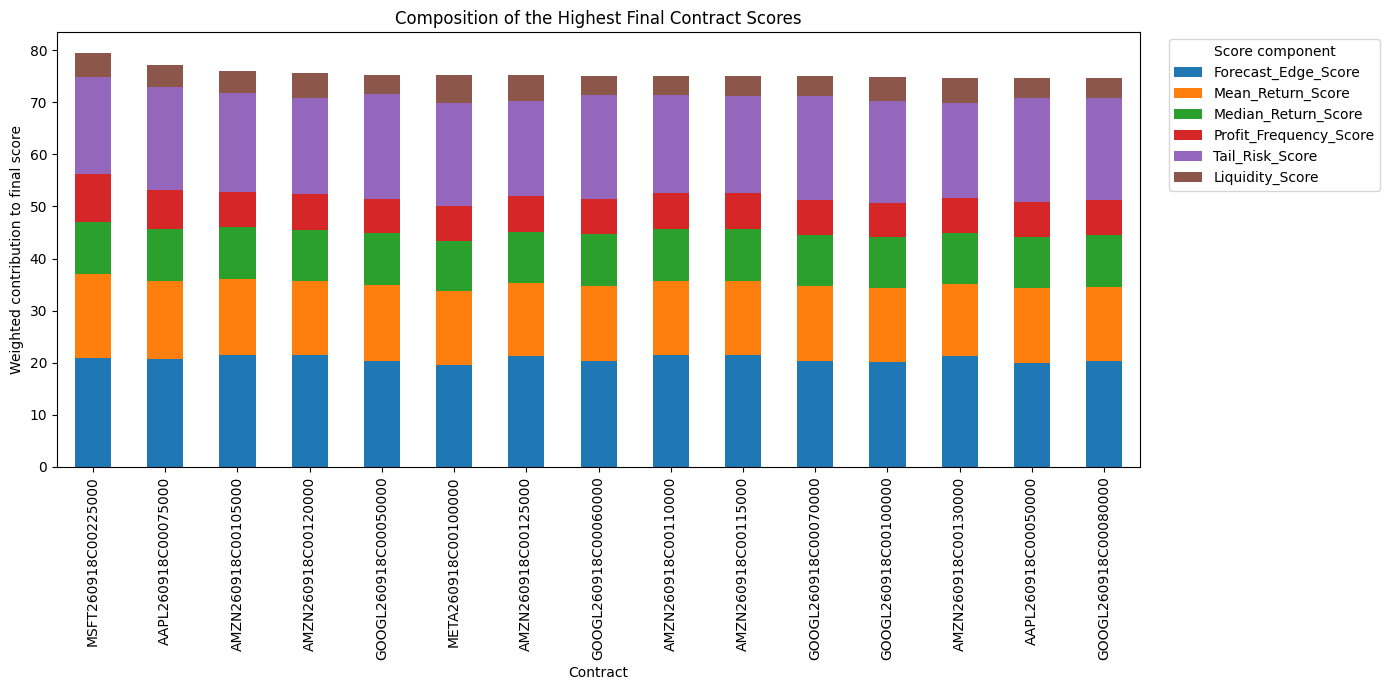

In [61]:
top_score_components = (
    final_contract_ranking
    .nlargest(
        15,
        "Final Score",
    )
    .set_index(
        "Contract Symbol"
    )
    [
        [
            "Forecast_Edge_Score",
            "Mean_Return_Score",
            "Median_Return_Score",
            "Profit_Frequency_Score",
            "Tail_Risk_Score",
            "Liquidity_Score",
        ]
    ]
)

weighted_score_components = (
    top_score_components
    .mul(
        pd.Series(
            FINAL_SCORE_WEIGHTS
        ),
        axis=1,
    )
)

weighted_score_components.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
)

plt.ylabel(
    "Weighted contribution to final score"
)

plt.xlabel(
    "Contract"
)

plt.title(
    "Composition of the Highest Final Contract Scores"
)

plt.legend(
    title="Score component",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

### Interpreting the highest scores

The highest-scoring contracts receive support from several dimensions rather
than forecast edge alone.

A high score does not automatically produce a Candidate. The score measures
relative quality across the current universe, whereas Candidate status also
applies absolute conditions including positive mean return, sufficient
liquidity and at least 50% scenario gain frequency.

The score is therefore a ranking tool; the final classification determines
whether the evidence crosses the selected decision threshold.

In [62]:
store.write_frame(
    final_contract_ranking,
    "final_contract_ranking",
    run_id=run_id,
)

store.write_frame(
    final_recommendation_summary,
    "final_recommendation_summary",
    run_id=run_id,
)

store.write_frame(
    initial_to_final_comparison.reset_index(),
    "initial_to_final_comparison",
    run_id=run_id,
)

final_contract_ranking.to_csv(
    TABLE_DIR
    / "final_contract_ranking.csv",
    index=False,
)

final_recommendation_summary.to_csv(
    TABLE_DIR
    / "final_recommendation_summary.csv",
    index=False,
)

initial_to_final_comparison.to_csv(
    TABLE_DIR
    / "initial_to_final_comparison.csv",
)

final_contract_shortlist.to_csv(
    TABLE_DIR
    / "final_contract_shortlist.csv",
    index=False,
)

print(
    "Stored final contract rankings:",
    len(final_contract_ranking),
)

print(
    "Stored final shortlist:",
    len(final_contract_shortlist),
)

2026-08-02 13:39:48,490 - options_risk_engine.database - INFO - Stored 794 rows in final_contract_ranking
2026-08-02 13:39:48,495 - options_risk_engine.database - INFO - Stored 4 rows in final_recommendation_summary
2026-08-02 13:39:48,500 - options_risk_engine.database - INFO - Stored 4 rows in initial_to_final_comparison


Stored final contract rankings: 794
Stored final shortlist: 57


The completed engine applies two distinct recommendation stages.

The first stage evaluates theoretical valuation. A contract receives an initial
classification according to whether the forecast-volatility Black–Scholes
value exceeds the current ask, after quote-validity and eligibility checks.

The second stage evaluates whether that apparent edge survives purchase at the
ask, common scenario repricing, outcome consistency, lower-tail risk,
liquidity and the Greek factors responsible for the contract's behaviour.

In this market snapshot, no contract satisfied every Candidate requirement.

The engine produced a 57-contract Watchlist containing 48 initial `Buy`
contracts and 9 `Positive Edge` contracts. A further 23 contracts were
risk-rejected, 462 were liquidity-rejected and 252 were classified as
`No Trade`.

The absence of Candidates is itself a useful decision. It shows that the
engine can distinguish an interesting theoretical opportunity from evidence
strong enough to support its most demanding classification.

The Watchlist represents contracts requiring further review or monitoring; it
should not be interpreted as 57 simultaneous trades.

# 22. Conclusions, limitations and next steps

## Overall conclusion

This project developed an end-to-end options-pricing, portfolio-risk and
contract-screening engine.

The completed workflow connects:

- live equity and option-chain data;
- return and realised-volatility feature engineering;
- purged walk-forward volatility forecasting;
- analytical Black–Scholes pricing;
- implied-volatility estimation;
- put-call parity and finite-difference validation;
- Monte Carlo pricing checks;
- synthetic portfolio construction;
- portfolio Greeks;
- full-revaluation stress testing;
- Greek P&L attribution;
- standardised one-contract analysis; and
- final risk-aware contract ranking.

The principal achievement is not the discovery of a universally superior
forecasting model or a guaranteed mispriced option. It is the construction of
a reproducible and auditable framework that separates forecast evidence,
market valuation, executable purchase price, scenario risk and final
classification.

## Volatility-forecasting findings

The forecasting stage tested 34 configurations using purged walk-forward
validation.

The model universe included simple baselines, OLS, Ridge, Lasso, PCA,
tree-based methods, HAR-RV and GARCH. Several more complex models achieved
small RMSE improvements for individual tickers, but the improvements were not
consistent across the seven-underlying universe.

Best-model normalised RMSE generally remained close to or above one, while
out-of-sample \(R^2\) remained negative. The historical mean of the forward
realised-volatility target was therefore retained as the final forecast input.

This was a deliberate model-risk decision. Complexity was not selected merely
because it fitted the historical sample more closely.

## Pricing and numerical validation

The analytical pricing implementation passed the independent numerical checks.

Forecast-volatility call and put values satisfied put-call parity to
floating-point precision. Analytical Greeks agreed with finite-difference
approximations, and Monte Carlo prices remained close to Black–Scholes values
when both methods used the same assumptions.

Comparison with market prices nevertheless showed substantial dispersion,
reflecting differences between forecast and implied volatility, variation
across strikes, volatility skew and inconsistent quote quality.

## Synthetic portfolio-risk findings

The synthetic test portfolio contained 966 option and share positions with
gross market value of approximately £17.75 million.

Its aggregate Delta was positive, but the ticker books contained substantial
offsetting exposures. Several large books had negative Gamma, meaning
first-order Delta understated vulnerability to severe nonlinear movements.

Across 1,000 generated non-BASE stress scenarios:

- approximately 56% produced a portfolio loss;
- fifth-percentile P&L was approximately -£62,581; and
- the worst result was approximately -£258,560.

The worst state combined a common spot fall of approximately 29.2%, an increase
of roughly ten volatility percentage points, six elapsed days and a small rate
reduction. META was the largest negative contributor, while MSFT provided the
largest positive offset.

Greek attribution identified Gamma as the main driver of the worst loss. Fixed
initial Greeks explained smaller local shocks more accurately than the largest
stresses, confirming that full repricing remains necessary when Greeks change
materially.

## Standardised contract-analysis findings

The original synthetic positions were unsuitable for comparing individual
contracts because they used different directions, quantities and entry prices.

A separate universe was therefore created in which every eligible option was
treated as one long contract purchased at the ask with a multiplier of 100.

The standardisation process retained 794 contracts:

- 91 initial `Buy`;
- 16 `Positive Edge`; and
- 687 `Do Not Buy`.

Every contract was repriced under the same 1,000 non-BASE scenarios, creating
794,000 comparable stressed outcomes plus 794 BASE observations.

The initial `Buy` group had a median forecast edge of approximately 53.9%,
compared with approximately 3.0% for `Positive Edge` and -63.5% for
`Do Not Buy`. This confirms that the forecast screen separated contracts by
theoretical valuation.

Several WMT, MSFT and AAPL puts generated the largest mean scenario returns,
but many high-edge contracts retained expected-shortfall outcomes close to
losing the complete premium.

Contracts with the highest gain frequencies or strongest percentage downside
were often deep-in-the-money options initially classified as `Do Not Buy`.
Valuation, consistency and downside protection therefore describe different
properties and cannot be replaced by one metric.

## Greek explanation of contract outcomes

Contract-level attribution was completed for all 794,794 contract-scenario
rows and all reconciliation checks passed.

Among the 91 initial `Buy` contracts:

- 52 had a Mixed dominant risk classification;
- 36 were Directional; and
- 3 were Convexity-driven.

No initial `Buy` contract was classified as purely Volatility-driven under the
dominant-component rule.

Although the initial signal originated from forecast volatility, scenario
outcomes were mainly explained by combinations of Delta, Gamma and Theta.
Purchasing an option on a volatility view still creates directional,
convexity and timing exposure.

## Final contract ranking

The final ranking combined forecast edge, average and median scenario return,
scenario gain frequency, lower-tail risk and liquidity.

It produced:

- 57 `Watchlist` contracts;
- 252 `No Trade` contracts;
- 23 `Risk Rejection` contracts;
- 462 `Liquidity Rejection` contracts; and
- no final `Candidate` contracts.

Of the 91 initial `Buy` contracts, 48 reached the Watchlist, 17 were rejected
for scenario risk and 26 were rejected for liquidity. Nine of the 16
`Positive Edge` contracts also reached the Watchlist.

No contract became a Candidate because none of the initial `Buy` contracts
satisfied every absolute rule, particularly the requirement to gain in at
least 50% of the generated scenarios.

This is not a failure to select a trade. It demonstrates that the final layer
can return no Candidate when the evidence is insufficient.

The Watchlist is concentrated in AMZN, GOOGL and META options, with smaller
groups of AAPL contracts and one contract each from MSFT and WMT. It is a
ranked research list rather than a diversified portfolio recommendation.

## Main limitations

The historical and option-chain inputs represent one live market snapshot.
Stored run IDs improve reproducibility, but later executions may receive
different prices, strikes, expiries, volumes and open interest.

The volatility forecast uses one value per underlying and cannot reproduce a
complete implied-volatility surface, strike skew or term structure.

The generated scenarios are transparent stress distributions rather than
calibrated real-world probabilities. All tickers receive the same common
percentage spot and volatility shock, which does not represent realistic
cross-asset correlations or idiosyncratic company events.

Scenario gain frequency is therefore a frequency within this generated stress
set, not a statistically calibrated probability of profit.

The final score is cross-sectional and threshold-dependent. Counts may change
when the liquidity gates, scenario distribution, weights or thresholds change.
Such changes should be reported as sensitivity tests rather than selected
after observing the result.

Black–Scholes also relies on simplified assumptions, including continuous
trading, lognormal prices and constant volatility over the pricing interval.
The project does not dynamically model early exercise, discrete dividends,
market impact, liquidity deterioration or spread widening during stress.

The synthetic portfolio is intentionally large and randomly constructed. Its
risk results validate the engine but do not represent a proposed allocation.

Finally, the contract ranking has not yet been tested against subsequently
realised option returns.

## Next steps

The highest-priority extension is a historical recommendation backtest.

For each historical evaluation date, the engine should:

1. construct the volatility forecast using only information available then;
2. record available option quotes and liquidity;
3. generate initial and final classifications without future information;
4. track selected contracts using executable bid and ask assumptions;
5. compare predicted scenario characteristics with realised option P&L; and
6. test whether Candidates or Watchlist contracts outperform control groups
   after transaction costs.

Further extensions could include a fitted volatility surface,
ticker-specific shocks, empirically estimated correlations, event scenarios,
American-option pricing and explicit portfolio construction from the ranked
contracts.

## Final assessment

The project does not establish that the historical-mean forecast is
universally optimal, that every positive model edge represents mispricing or
that any current contract should be purchased.

It establishes something more defensible: a validated research and risk
framework that can reject weak forecast evidence, distinguish theoretical
value from purchase P&L, expose nonlinear option risk and return no final
Candidate when the complete evidence does not justify one.

Those distinctions make the project substantially more than a Black–Scholes
calculator. It is an auditable options-research and risk-engine workflow with
a clear path toward historical validation.